In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.ticker as ticker
from matplotlib.cm import ScalarMappable
import pycountry_convert as pc

In [9]:
# Load the data
appearances_df = pd.read_csv('./data_cleaned/appearances.csv')
clubs_df = pd.read_csv('./data_cleaned/clubs.csv')
players_df = pd.read_csv('./data_cleaned/players.csv')
competitions_df = pd.read_csv('./data_cleaned/competitions.csv')
games_df = pd.read_csv('./data_cleaned/games.csv')
game_events_df = pd.read_csv('./data_cleaned/game_events.csv')
game_lineups_df = pd.read_csv('./data_cleaned/game_lineups.csv')
player_valuations_df = pd.read_csv('./data_cleaned/player_valuations.csv')

###### Codice di preparazione e visualizzazione grafica

In [13]:
#Set the display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [14]:
# Load the world map data
world_map = gpd.read_file('./ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
world_map = world_map.rename(columns={'NAME': 'country_of_citizenship'})

# Define the competition codes for the top 5 European leagues and the Champions League
competitions = ['IT1', 'ES1', 'GB1', 'L1', 'FR1', 'CL']
players_in_competitions = players_df[players_df['current_club_domestic_competition_id'].isin(competitions)]

# Calculate the total percentage of players by country
players_country_count = players_df['country_of_citizenship'].value_counts(normalize=True) * 100
players_country_count = players_country_count.reset_index()
players_country_count.columns = ['country_of_citizenship', 'percentage_of_players']

# Calculate the percentage of players playing in the specified competitions by country
players_in_comp_country_count = players_in_competitions['country_of_citizenship'].value_counts(normalize=True) * 100
players_in_comp_country_count = players_in_comp_country_count.reset_index()
players_in_comp_country_count.columns = ['country_of_citizenship', 'percentage_in_top_competitions']

world_map = world_map.merge(players_country_count, on='country_of_citizenship', how='left')
world_map = world_map.merge(players_in_comp_country_count, on='country_of_citizenship', how='left')

In [15]:
# Dict to map country names to match the GeoPandas DataFrame
country_mapping = {
    "England": "United Kingdom",
    "Scotland": "United Kingdom",
    "Wales": "United Kingdom",
    "Northern Ireland": "United Kingdom"
}

players_df['country_of_citizenship'] = players_df['country_of_citizenship'].map(country_mapping).fillna(players_df['country_of_citizenship'])

In [16]:
# Function to get the continent from a country name
def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return None 

world_map['continent'] = world_map['ADMIN'].apply(country_to_continent)

In [17]:
# Filtering to exclude European countries and show only those with more than 1% of players
world_filtered = world_map[(world_map['percentage_of_players'] > 1) & (world_map['continent'] != 'Europe')]
# Filtering to exclude European countries and show only those with more than 1% of players
europe_filtered = world_map[(world_map['percentage_of_players'] > 1) & (world_map['continent'] == 'Europe')]

# Se fossimo degli allenatori, quali scelte faremmo per creare la nostra squadra ideale?

###### Ispirati da "Moneyball", il film in cui Brad Pitt veste i panni di Billy Beane, un general manager che trasforma gli Oakland Athletics attraverso un approccio basato su dati statistici, ci poniamo la domanda: come potremmo noi, nei panni di allenatori di calcio, utilizzare un metodo simile per scegliere i giocatori più adatti e costruire una squadra vincente? Esploriamo questa strategia, valutando l'efficacia di una selezione basata sui numeri per ottenere successo in campo. 

## 1. Quale formazione scegliamo per la nostra squadra? 

### 1.1. Quale è la formazione che, statisticamente, ha realizzato più punti?

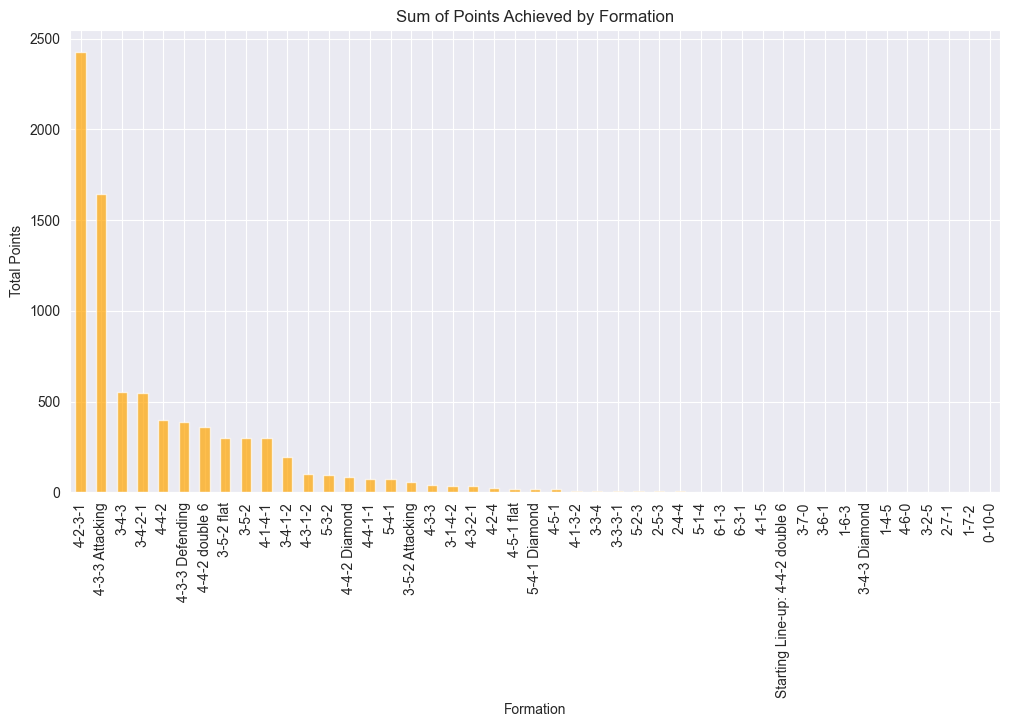

In [8]:
# Filter the data to include only rows where the formations are not null
filtered_data = games_df[(games_df['home_club_formation']!='unknown') | (games_df['away_club_formation']!='unknown')].copy()

# Create a column to record the points awarded to the home and away clubs based on the match result
# Home club points:
# - 3 points if the home team wins
# - 1 point if the match is a draw
# - 0 points if the home team loses
filtered_data['home_points'] = filtered_data.apply(
    lambda row: 3 if row['home_club_goals'] > row['away_club_goals'] else (1 if row['home_club_goals'] == row['away_club_goals'] else 0),
    axis=1
)

# Away club points:
# - 3 points if the away team wins
# - 1 point if the match is a draw
# - 0 points if the away team loses
filtered_data['away_points'] = filtered_data.apply(
    lambda row: 3 if row['away_club_goals'] > row['home_club_goals'] else (1 if row['away_club_goals'] == row['home_club_goals'] else 0),
    axis=1
)

# Calculate the total points for each formation, both for home and away
home_points_by_formation = filtered_data.groupby('home_club_formation')['home_points'].sum()
away_points_by_formation = filtered_data.groupby('away_club_formation')['away_points'].sum()

# Combine the home and away points by formation
total_points_by_formation = home_points_by_formation.add(away_points_by_formation, fill_value=0)
cleaned_total_points_by_formation = total_points_by_formation.drop('unknown', errors='ignore')

# Create a bar plot to show the total points by formation, excluding 'unknown' values
cleaned_total_points_by_formation.sort_values(ascending=False).plot(kind='bar', figsize=(12, 6), color='orange', alpha=0.7)

plt.title("Sum of Points Achieved by Formation")
plt.xlabel("Formation")
plt.ylabel("Total Points")
plt.show() 

### 1.2. Quale formazione che ha giocato almeno 7 partite ha ottenuto più vittorie, pareggi e sconfitte?

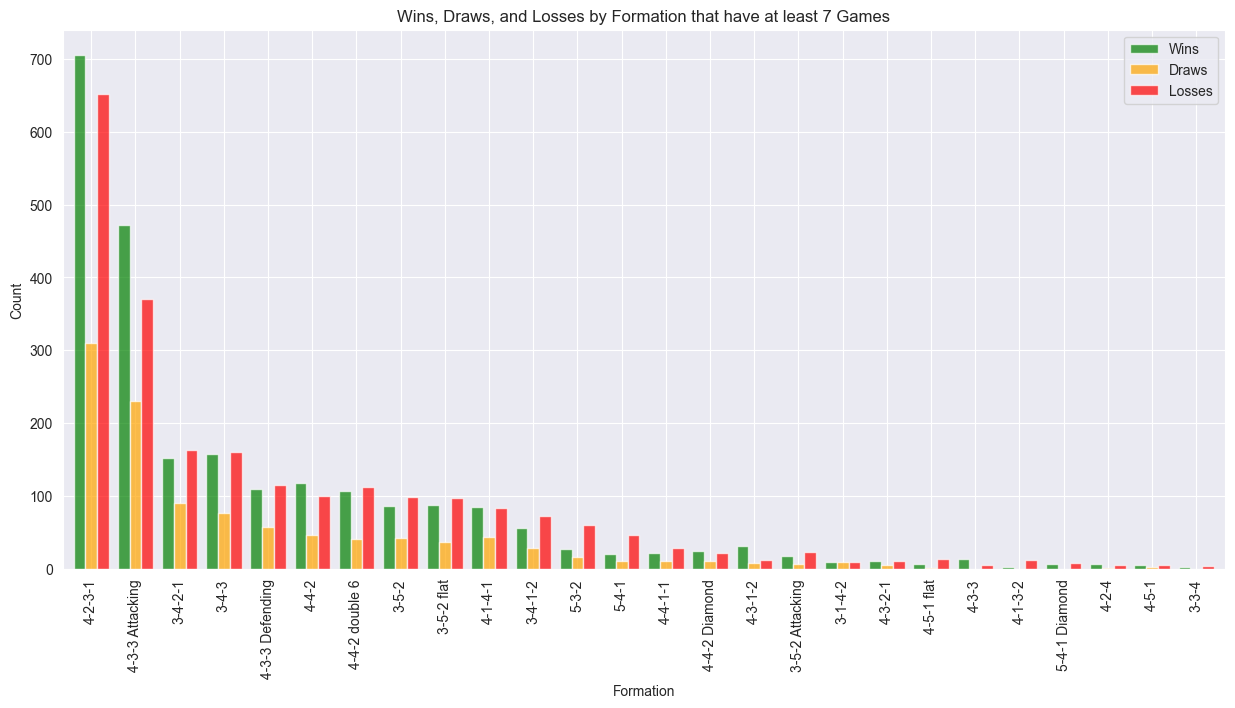

In [9]:
# Calculate the number of wins, draws, and losses for each formation, both for home and away teams
home_wins = filtered_data[filtered_data['home_points'] == 3].groupby('home_club_formation').size()
home_draws = filtered_data[filtered_data['home_points'] == 1].groupby('home_club_formation').size()
home_losses = filtered_data[filtered_data['home_points'] == 0].groupby('home_club_formation').size()

away_wins = filtered_data[filtered_data['away_points'] == 3].groupby('away_club_formation').size()
away_draws = filtered_data[filtered_data['away_points'] == 1].groupby('away_club_formation').size()
away_losses = filtered_data[filtered_data['away_points'] == 0].groupby('away_club_formation').size()

wins = home_wins.add(away_wins, fill_value=0)
draws = home_draws.add(away_draws, fill_value=0)
losses = home_losses.add(away_losses, fill_value=0)

# Calculate wins, draws, and losses for each formation, both for home and away teams
results_by_formation = pd.DataFrame({'Wins': wins, 'Draws': draws, 'Losses': losses})

# Calculate the total number of games played for each formation
home_games_by_formation = filtered_data.groupby('home_club_formation').size()
away_games_by_formation = filtered_data.groupby('away_club_formation').size()
total_games_by_formation = home_games_by_formation.add(away_games_by_formation, fill_value=0)

# Get the formations with at least 7 games
valid_formations = total_games_by_formation[total_games_by_formation >= 7].sort_values(ascending=False).index

# Keep only the valid formations for the chart
results_sorted = results_by_formation.loc[valid_formations]
cleaned_results_sorted = results_sorted.drop('unknown', errors='ignore')

# Create a bar plot with side-by-side columns to show wins, draws, and losses for each formation
cleaned_results_sorted.plot(
    kind='bar', figsize=(15, 7), color=['green', 'orange', 'red'], alpha=0.7, width=0.8, stacked=False
)

plt.title("Wins, Draws, and Losses by Formation that have at least 7 Games")
plt.xlabel("Formation")
plt.ylabel("Count")
plt.show()  

### 1.3. Delle 10 formazioni più utilizzate, quale è l'avversario più difficile da affrontare?

In [10]:
# Filter to get the top 10 most used formations
top_10_formations = total_games_by_formation.sort_values(ascending=False).head(10) 

def complete_performance_analysis(formation):
    # Filter the data for games involving the specified formation
    home_games = games_df[games_df['home_club_formation'] == formation]
    away_games = games_df[games_df['away_club_formation'] == formation]
    
    # Count the games played against each formation
    home_matchups = home_games['away_club_formation'].value_counts()
    away_matchups = away_games['home_club_formation'].value_counts()
    total_matchups = home_matchups.add(away_matchups, fill_value=0)
    
    # Count the losses against each formation
    home_losses = home_games[home_games['home_club_goals'] < home_games['away_club_goals']]['away_club_formation'].value_counts()
    away_losses = away_games[away_games['home_club_goals'] > away_games['away_club_goals']]['home_club_formation'].value_counts()
    total_losses = home_losses.add(away_losses, fill_value=0)

    # Count the draws
    home_draws = home_games[home_games['home_club_goals'] == home_games['away_club_goals']]['away_club_formation'].value_counts()
    away_draws = away_games[away_games['home_club_goals'] == away_games['away_club_goals']]['home_club_formation'].value_counts()
    total_draws = home_draws.add(away_draws, fill_value=0)

    # Count the wins
    home_wins = home_games[home_games['home_club_goals'] > home_games['away_club_goals']]['away_club_formation'].value_counts()
    away_wins = away_games[away_games['home_club_goals'] < away_games['away_club_goals']]['home_club_formation'].value_counts()
    total_wins = home_wins.add(away_wins, fill_value=0)

    # Filter out the matchups with less than 50 games
    valid_matchups = total_matchups[total_matchups >= 50]
    
    # Calculate the loss, draw, and win percentages
    valid_losses = total_losses.reindex(valid_matchups.index).fillna(0)
    valid_draws = total_draws.reindex(valid_matchups.index).fillna(0)
    valid_wins = total_wins.reindex(valid_matchups.index).fillna(0)
    loss_percentages = (valid_losses / valid_matchups * 100)
    draw_percentages = (valid_draws / valid_matchups * 100)
    win_percentages = (valid_wins / valid_matchups * 100)
    
    # Find the most challenging formation
    if not loss_percentages.empty:
        most_challenging_formation = loss_percentages.idxmax()
        highest_loss_percentage = loss_percentages.max()
        draw_percentage = draw_percentages[most_challenging_formation]
        win_percentage = win_percentages[most_challenging_formation]
        total_games = valid_matchups[most_challenging_formation]
    else:
        most_challenging_formation = "None"
        highest_loss_percentage = 0
        draw_percentage = 0
        win_percentage = 0
        total_games = 0
    
    return {
        'Most Challenging Formation': most_challenging_formation,
        'Total Matches': total_games,
        'Wins': valid_wins[most_challenging_formation],
        'Win Percentage': win_percentage,
        'Draws': valid_draws[most_challenging_formation],
        'Draw Percentage': draw_percentage,
        'Losses': valid_losses[most_challenging_formation],
        'Loss Percentage': highest_loss_percentage
    }

# Perform the complete performance analysis for the top 10 formations
complete_performance_results = {formation: complete_performance_analysis(formation) for formation in top_10_formations.index if formation != "unknown"}

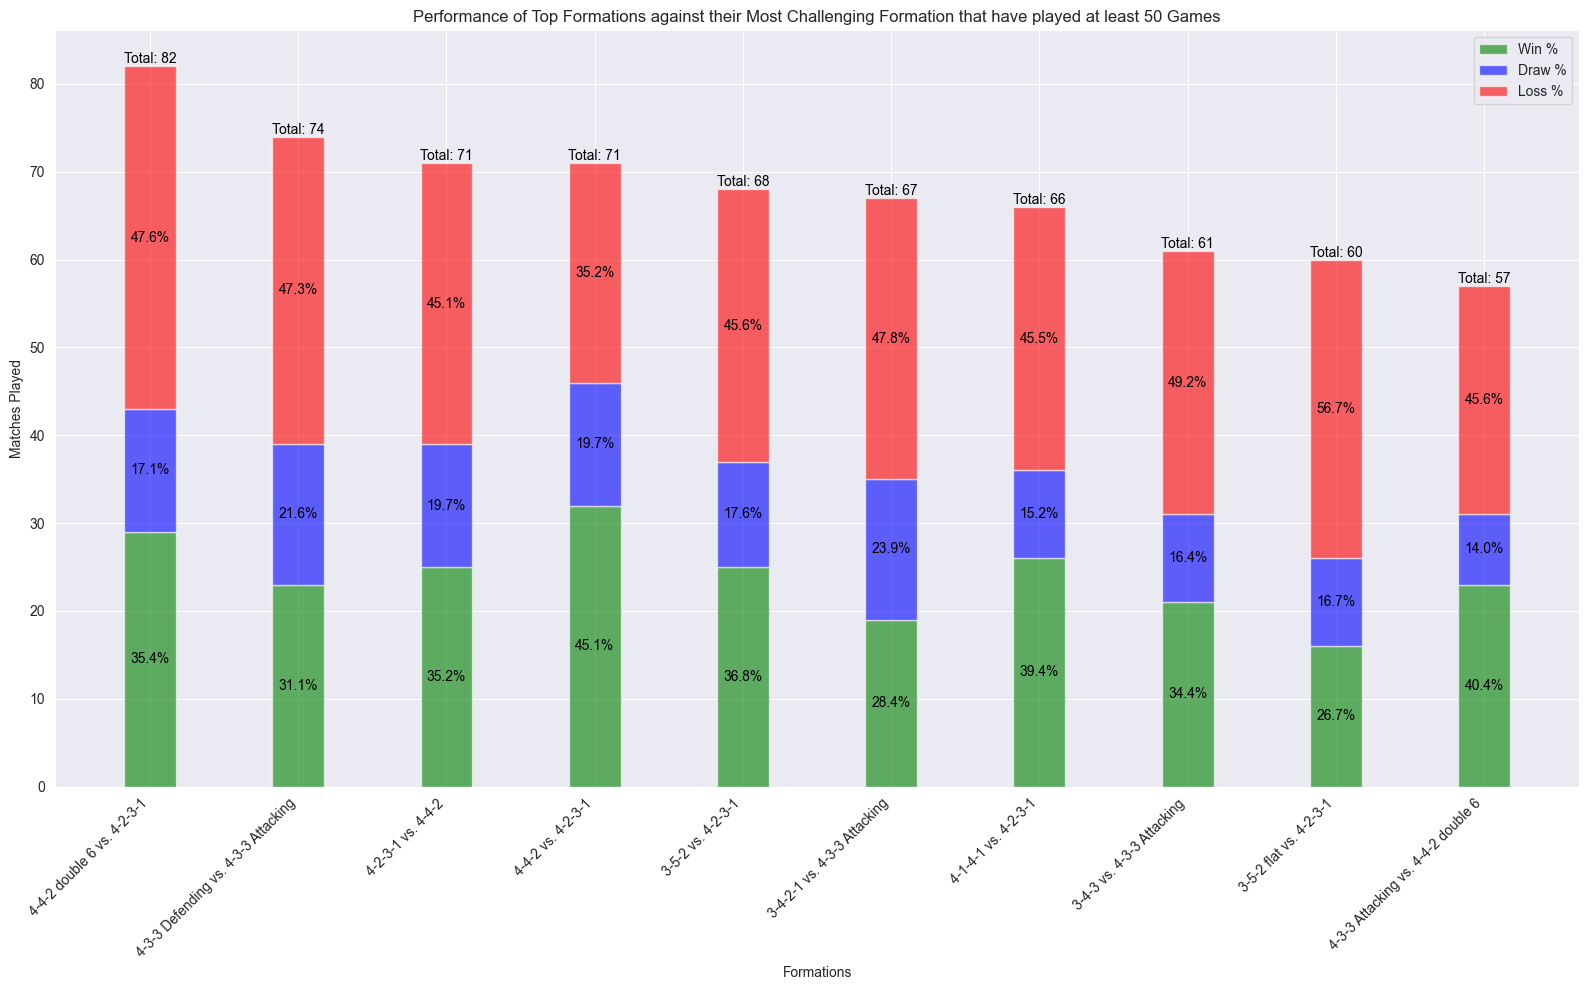

In [11]:
# Extract the relevant information for sorting
sorted_info = sorted(complete_performance_results.items(), key=lambda x: x[1]['Total Matches'], reverse=True)
sorted_labels = [f"{formation} vs. {info['Most Challenging Formation']}" for formation, info in sorted_info]
sorted_total_games = [info['Total Matches'] for _, info in sorted_info]
sorted_win_heights = [info['Win Percentage'] for _, info in sorted_info]
sorted_draw_heights = [info['Draw Percentage'] for _, info in sorted_info]
sorted_loss_heights = [info['Loss Percentage'] for _, info in sorted_info]

# Calculate the actual heights based on the total number of games
sorted_win_heights = [total * (win / 100) for total, win in zip(sorted_total_games, sorted_win_heights)]
sorted_draw_heights = [total * (draw / 100) for total, draw in zip(sorted_total_games, sorted_draw_heights)]
sorted_loss_heights = [total * (loss / 100) for total, loss in zip(sorted_total_games, sorted_loss_heights)]

# Create a stacked bar chart to show the win, draw, and loss percentages for each formation
fig, ax = plt.subplots(figsize=(16, 10))
bar_width = 0.35
for i, total_games in enumerate(sorted_total_games):
    # Winnings
    win = ax.bar(i, sorted_win_heights[i], bar_width, color='green', alpha=0.6)
    ax.annotate(f'{(sorted_win_heights[i]/total_games*100):.1f}%', 
                xy=(i, sorted_win_heights[i]/2), 
                ha='center', va='center', color='black')
    
    # Drawings
    draw = ax.bar(i, sorted_draw_heights[i], bar_width, bottom=sorted_win_heights[i], color='blue', alpha=0.6)
    ax.annotate(f'{(sorted_draw_heights[i]/total_games*100):.1f}%', 
                xy=(i, sorted_win_heights[i] + sorted_draw_heights[i]/2), 
                ha='center', va='center', color='black')
    
    # Losses
    loss = ax.bar(i, sorted_loss_heights[i], bar_width, bottom=sorted_win_heights[i] + sorted_draw_heights[i], color='red', alpha=0.6)
    ax.annotate(f'{(sorted_loss_heights[i]/total_games*100):.1f}%', 
                xy=(i, sorted_win_heights[i] + sorted_draw_heights[i] + sorted_loss_heights[i]/2), 
                ha='center', va='center', color='black')
    
    # Total games
    ax.annotate(f'Total: {int(total_games)}', 
                xy=(i, sorted_win_heights[i] + sorted_draw_heights[i] + sorted_loss_heights[i]), 
                ha='center', va='bottom', color='black')

ax.set_xlabel('Formations')
ax.set_ylabel('Matches Played')
ax.set_title('Performance of Top Formations against their Most Challenging Formation that have played at least 50 Games')
ax.set_xticks(range(len(sorted_info)))
ax.set_xticklabels(sorted_labels, rotation=45, ha="right")
ax.legend(['Win %', 'Draw %', 'Loss %'])
plt.tight_layout()
plt.show()

Dalle analisi effettuate, possiamo concludere che la formazione 4-2-3-1 è la formazione più utilizzata e anche quella che ha ottenuto più punti. Inoltre, per le 10 formazioni più utilizzate, questa formazione è quella più difficile da affrontare. 

## 2. Quale correlazione c'è fra nazione e valore di valutazione medio più alto per posizione? 

_Nota: nei seguenti grafici verrà mostrata una percentuale vicino alla nazione, che rappresenta la percentuale di giocatori di quella nazionalità in quella posizione, rispetto il dataset preso in considerazione._

### 2.1. Quale nazione ha il valore di valutazione medio più alto per posizione, tra i calciatori di tutti i campionati dal 2012 al 2023? 

In [12]:
# Calculate the highest market value for each player
highest_market_value = player_valuations_df.groupby('player_id')['market_value_in_eur'].max().reset_index()

# Merge the player_valuations dataset with players_df to include position and nationality information
merged_valuations = player_valuations_df.merge(players_df[['player_id', 'position', 'country_of_citizenship']], on='player_id')
merged_valuations = merged_valuations.merge(highest_market_value, on=['player_id', 'market_value_in_eur'])

# Aggregate data to compute the average and maximum market value by position and nationality
grouped_valuations = merged_valuations.groupby(['position', 'country_of_citizenship']).agg(average_market_value=('market_value_in_eur', 'mean'), count_players=('player_id', 'count')).reset_index()

# Sort data by average market value in descending order
grouped_valuations = grouped_valuations.sort_values(by=['position', 'average_market_value'], ascending=False)
# Filter out rows where the position is 'Missing'
grouped_valuations = grouped_valuations[grouped_valuations['position'] != 'Missing']
grouped_valuations = grouped_valuations[grouped_valuations['country_of_citizenship'] != 'unknown']

# Filter out countries with less than 1% players in specific position
total_players_by_position = grouped_valuations.groupby('position')['count_players'].sum().reset_index()
grouped_valuations = grouped_valuations.merge(total_players_by_position, on='position', suffixes=('', '_total'))
grouped_valuations['percentage'] = grouped_valuations['count_players'] / grouped_valuations['count_players_total'] * 100
filtered_valuations = grouped_valuations[grouped_valuations['percentage'] >= 1]

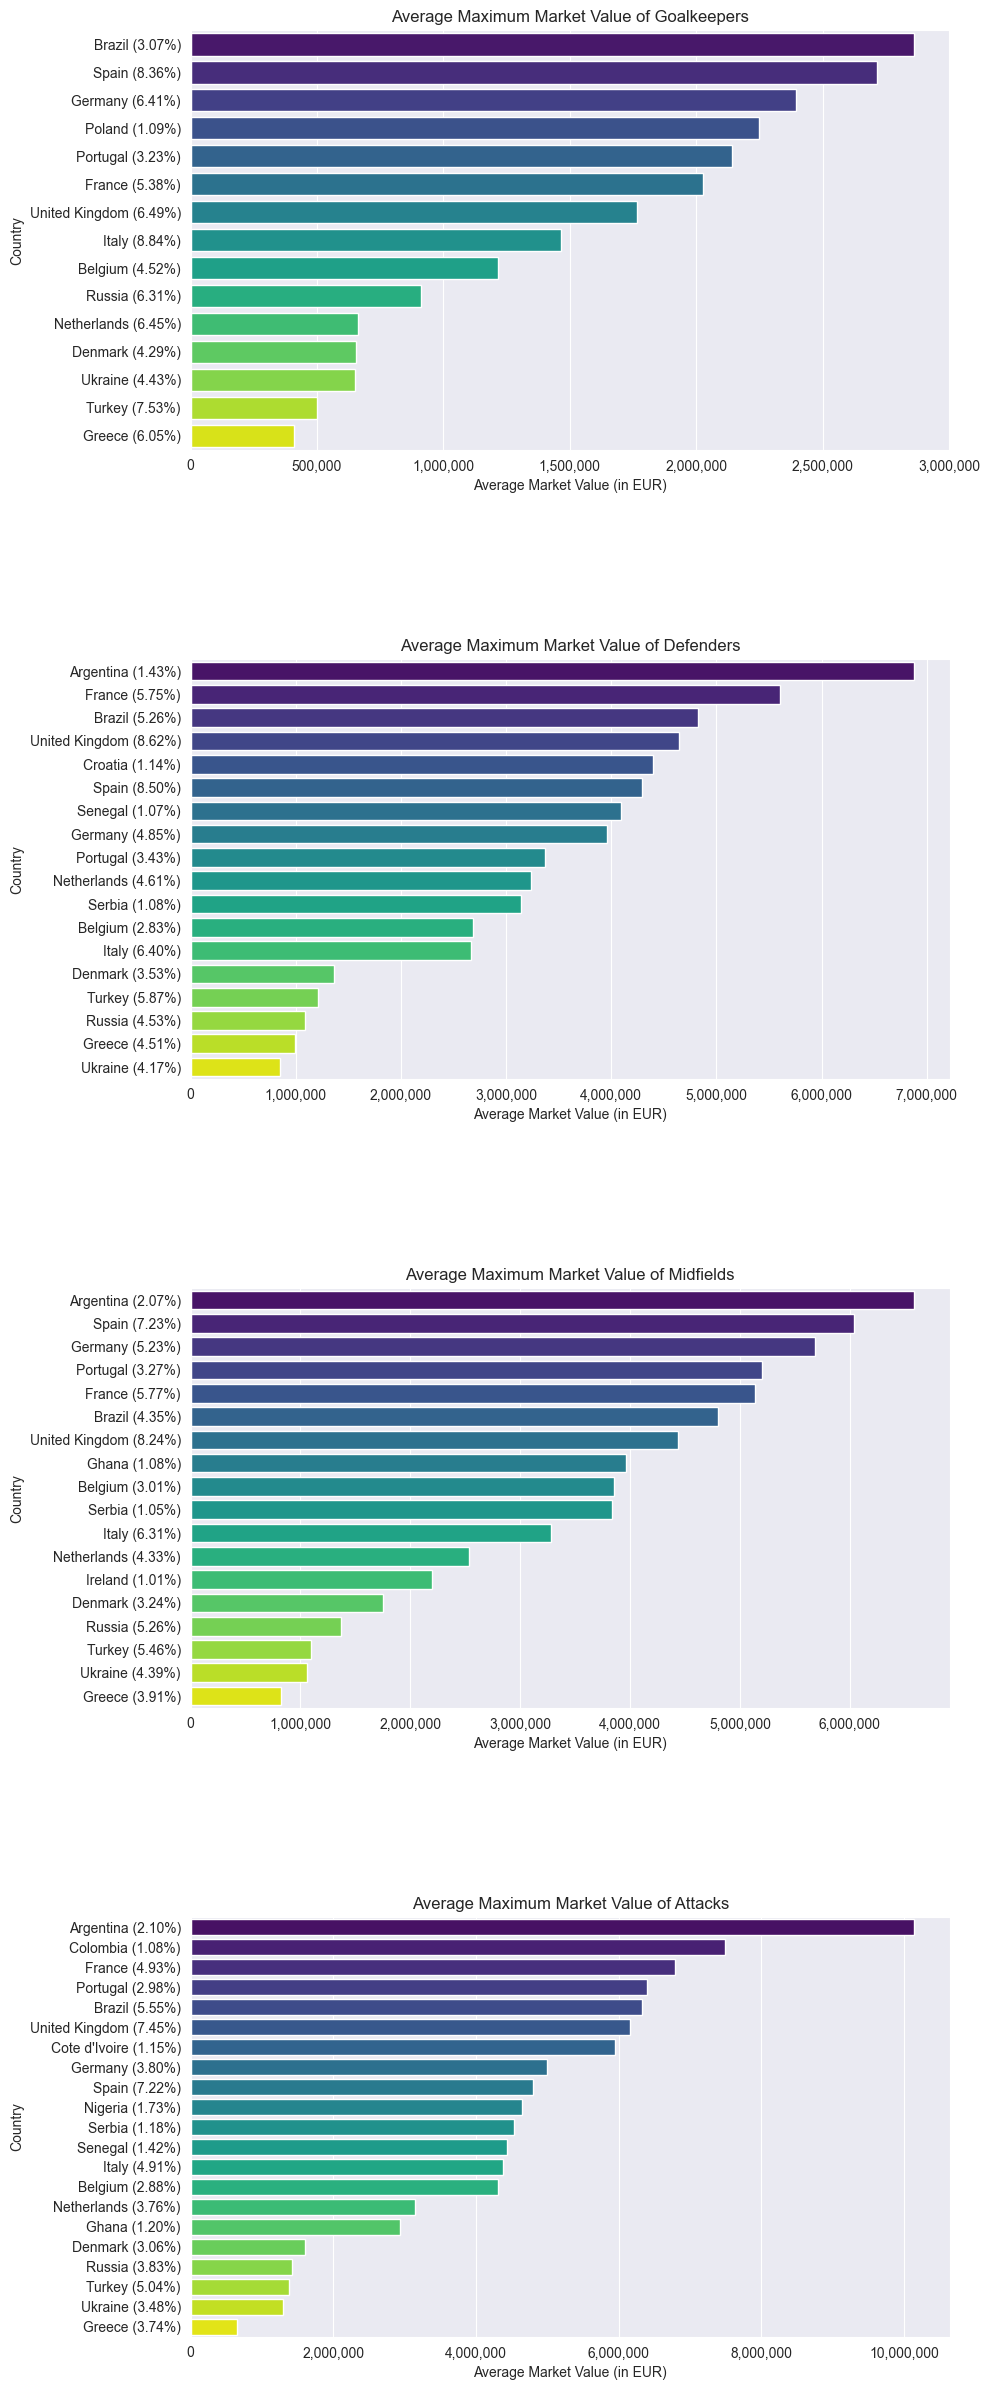

In [13]:
# Define positions in order to create subplots
positions = ['Goalkeeper', 'Defender', 'Midfield', 'Attack']

# Create a figure with subplots for each position
fig, axes = plt.subplots(len(positions), 1, figsize=(10, 24), sharex=False) 

# Loop over each position to create a separate histogram
for i, position in enumerate(positions):
    # Filter the data for the current position
    pos_data = filtered_valuations[filtered_valuations['position'] == position]
    
    # Create the barplot
    bars = sns.barplot(x='average_market_value', y='country_of_citizenship', data=pos_data, ax=axes[i], color='grey', order=pos_data.sort_values('average_market_value', ascending=False)['country_of_citizenship'])
    
    # Generate a color palette
    palette = sns.color_palette("viridis", n_colors=len(pos_data))
    
    # Set the colors of each bar based on the palette
    for bar, color in zip(bars.patches, palette):
        bar.set_facecolor(color)

    axes[i].set_title(f'Average Maximum Market Value of {position}s')
    axes[i].set_xlabel('Average Market Value (in EUR)')
    axes[i].set_ylabel('Country')

    # Set the formatter for the x-axis to display integers
    axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[i].xaxis.set_major_locator(ticker.AutoLocator())  # Automatically determine the best location for ticks

    # Set ticks and labels for the y-axis
    y_ticks = range(len(pos_data))
    y_labels = [f"{row['country_of_citizenship']} ({row['percentage']:.2f}%)" for idx, row in pos_data.iterrows()]
    axes[i].set_yticks(y_ticks)
    axes[i].set_yticklabels(y_labels)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)  # Increase horizontal space between plots
plt.show()

### 2.2. Quale nazione ha il valore di valutazione medio più alto per posizione, tra i calciatori dei top campionati europei nel 2023? 

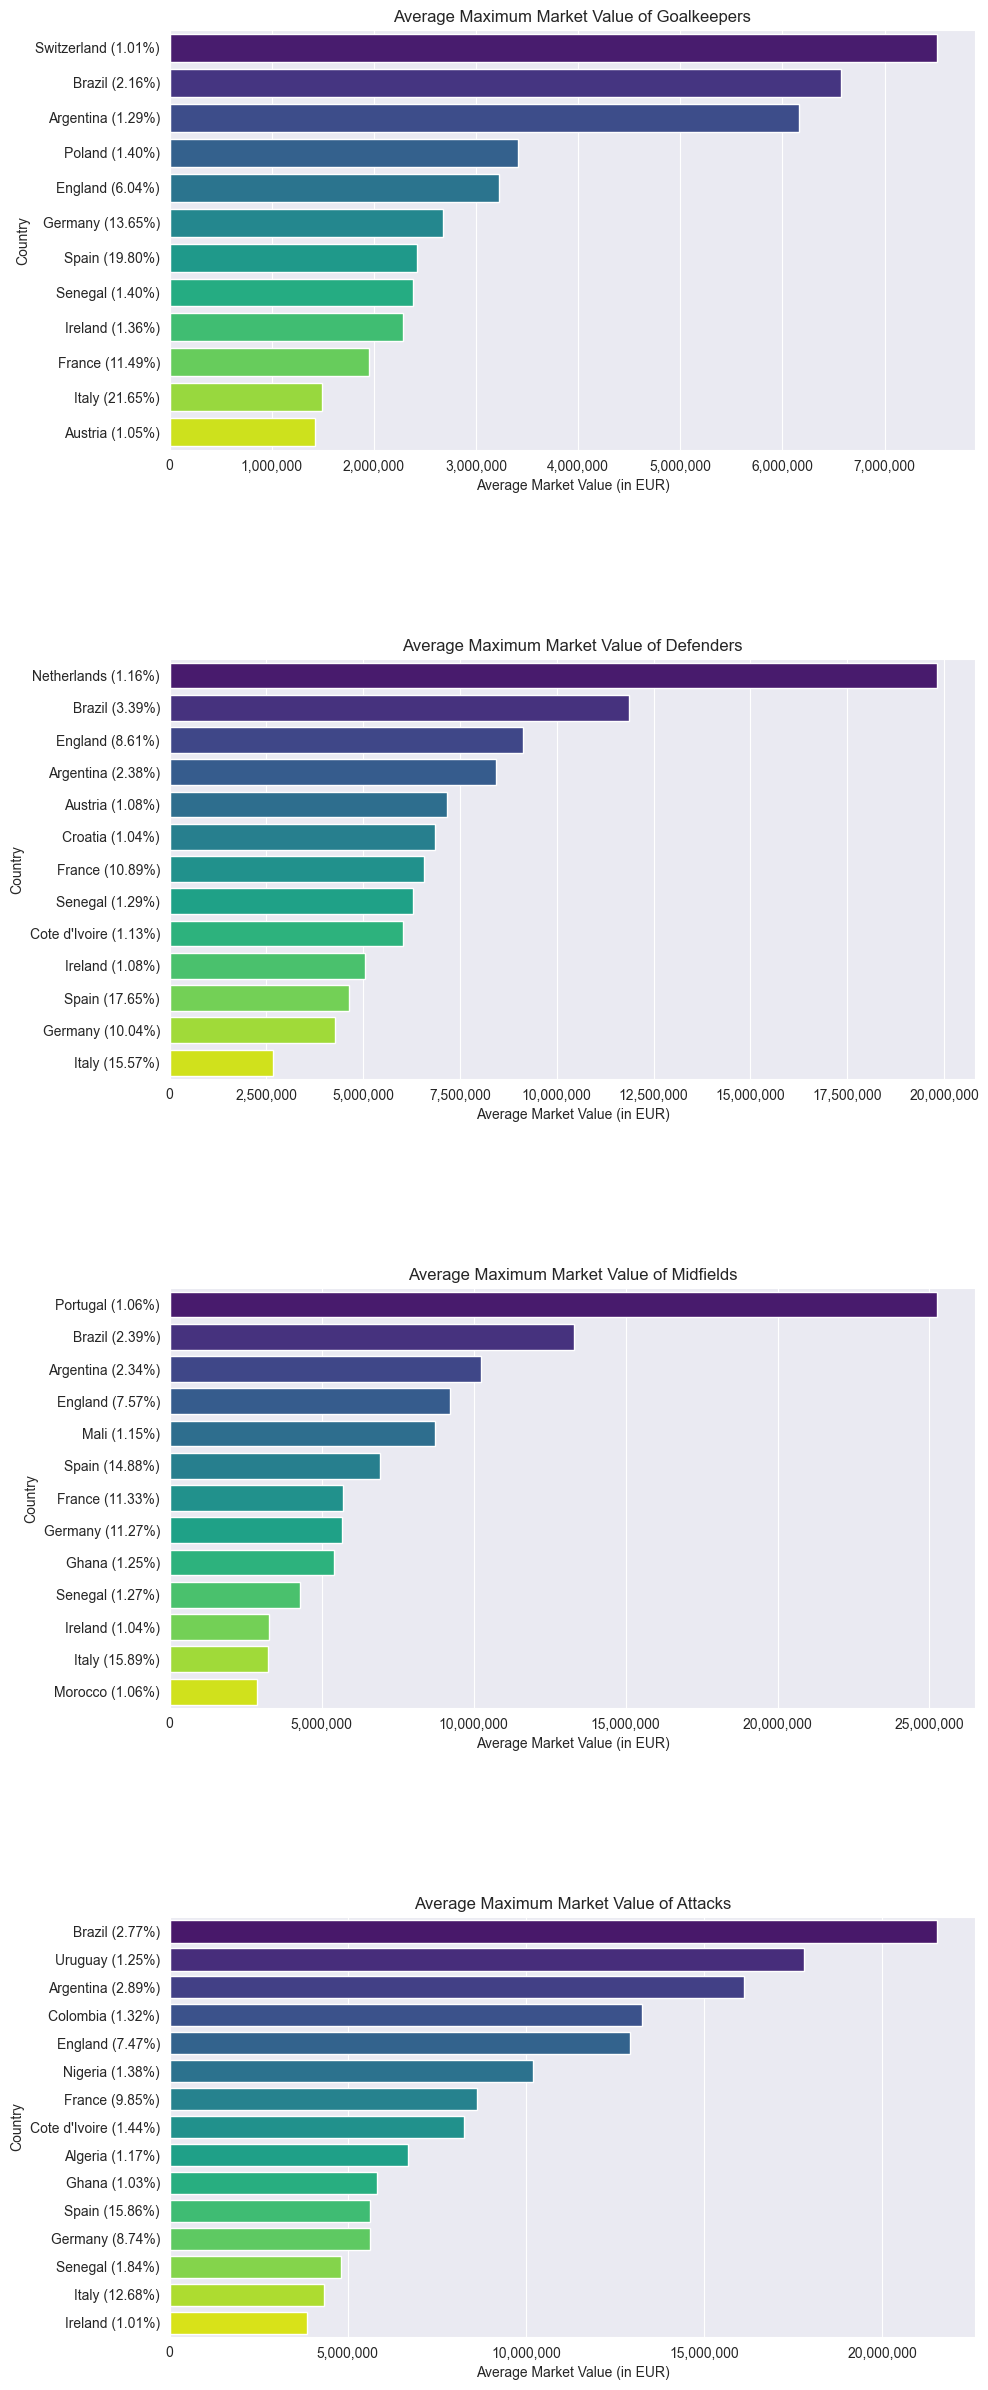

In [14]:
# Calculate the highest market value for each player
highest_market_value = player_valuations_df.groupby('player_id')['market_value_in_eur'].max().reset_index()

# Merge the player_valuations dataset with players_df to include position and nationality information
merged_valuations = player_valuations_df.merge(players_in_competitions[['player_id', 'position', 'country_of_citizenship']], on='player_id')
merged_valuations = merged_valuations.merge(highest_market_value, on=['player_id', 'market_value_in_eur'])

# Aggregate data to compute the average and maximum market value by position and nationality
grouped_valuations = merged_valuations.groupby(['position', 'country_of_citizenship']).agg(average_market_value=('market_value_in_eur', 'mean'), count_players=('player_id', 'count')).reset_index()

# Sort data by average market value in descending order
grouped_valuations = grouped_valuations.sort_values(by=['position', 'average_market_value'], ascending=False)
# Filter out rows where the position is 'Missing'
grouped_valuations = grouped_valuations[grouped_valuations['position'] != 'Missing']
grouped_valuations = grouped_valuations[grouped_valuations['country_of_citizenship'] != 'unknown']

# Filter out countries with less than 1% players in specific position
total_players_by_position = grouped_valuations.groupby('position')['count_players'].sum().reset_index()
grouped_valuations = grouped_valuations.merge(total_players_by_position, on='position', suffixes=('', '_total'))
grouped_valuations['percentage'] = grouped_valuations['count_players'] / grouped_valuations['count_players_total'] * 100
filtered_valuations = grouped_valuations[grouped_valuations['percentage'] >= 1]

# Define positions in order to create subplots
positions = ['Goalkeeper', 'Defender', 'Midfield', 'Attack']

# Create a figure with subplots for each position
fig, axes = plt.subplots(len(positions), 1, figsize=(10, 24), sharex=False)  # sharex=False to not share x-axis settings

# Loop over each position to create a separate histogram
for i, position in enumerate(positions):
    # Filter the data for the current position
    pos_data = filtered_valuations[filtered_valuations['position'] == position]
    
    # Create the barplot
    bars = sns.barplot(x='average_market_value', y='country_of_citizenship', data=pos_data, ax=axes[i], color='grey', order=pos_data.sort_values('average_market_value', ascending=False)['country_of_citizenship'])
    
    # Generate a color palette
    palette = sns.color_palette("viridis", n_colors=len(pos_data))
    
    # Set the colors of each bar based on the palette
    for bar, color in zip(bars.patches, palette):
        bar.set_facecolor(color)

    axes[i].set_title(f'Average Maximum Market Value of {position}s')
    axes[i].set_xlabel('Average Market Value (in EUR)')
    axes[i].set_ylabel('Country')

    # Set the formatter for the x-axis to display integers
    axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[i].xaxis.set_major_locator(ticker.AutoLocator())  # Automatically determine the best location for ticks

    # Set ticks and labels for the y-axis
    y_ticks = range(len(pos_data))
    y_labels = [f"{row['country_of_citizenship']} ({row['percentage']:.2f}%)" for idx, row in pos_data.iterrows()]
    axes[i].set_yticks(y_ticks)
    axes[i].set_yticklabels(y_labels)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)  # Increase horizontal space between plots
plt.show()

Dalle analisi effettuate, confrontando i risultato ottenuti nel passato e quelli sull'ultima stagione, possiamo concludere che le nazioni di riferimento dei portieri sono il Brasile e la Polonia, quelle dei difensori sono il Brasile e il Regno Unito, dei centrocampisti Argentina e Portogallo, mentre le nazioni con la media di valutazione più alta degli attaccanti sono l'Argentina, la Colombia e il Brasile
   
*Perché ci sono tante nazioni sudamericane e poche europee?* Questo perché il dataset di riferimento è quello europeo, di conseguenza è molto più probabile che, ad esempio, nel campionato italiano vi siano dei giocatori italiani. Questo provoca un abbassamento della media di valutazione delle nazioni in cui è presente una domestic league nel nostro dataset. Per questo motivo è giusto valutare anche in base alla percentuale di presenza, appositamente mostrate, dei giocatori

## 3. Come gestire le sostituzioni durante la partita?

### 3.1. A quale statisticamente viene fatta una sostituzione? 

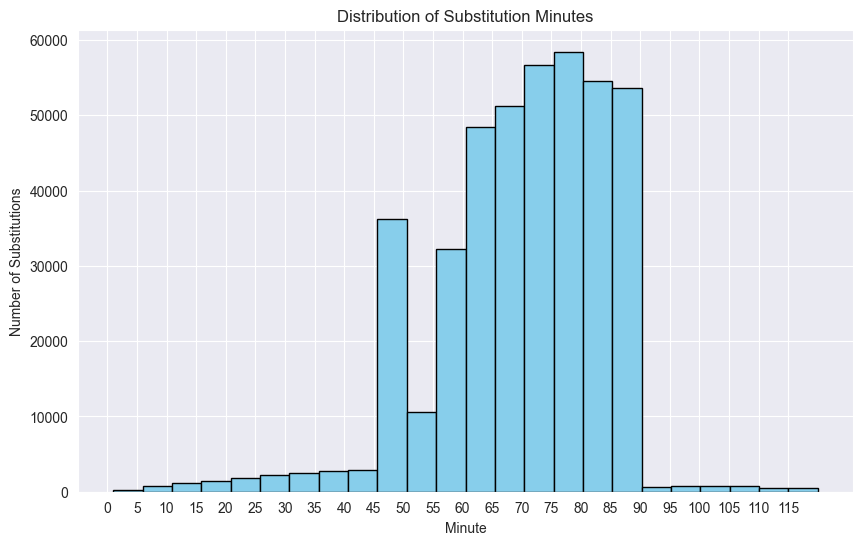

In [15]:
# Filter the substitution events from the game_events
substitutions = game_events_df[game_events_df['type'] == 'Substitutions']

# Merge with the players dataset to get information about the positions of the outgoing players
substitutions = substitutions.merge(players_df[['player_id', 'sub_position']], how='left', on='player_id')
substitutions.rename(columns={'sub_position': 'position_out'}, inplace=True)

# Merge with the players dataset to get information about the positions of the incoming players
substitutions = substitutions.merge(players_df[['player_id', 'sub_position']], how='left', left_on='player_in_id', right_on='player_id', suffixes=('', '_in'))
substitutions.rename(columns={'sub_position': 'position_in'}, inplace=True)

# Filter out substitutions with invalid minutes
substitutions = substitutions[(substitutions['minute'] >= 0) & (substitutions['minute'] <= 120)]

# Clean the dataframe by dropping duplicate columns
substitutions.drop(columns=['player_id_in'], inplace=True)

plt.figure(figsize=(10, 6))
plt.hist(substitutions['minute'], bins=24, color='skyblue', edgecolor='black')
plt.title('Distribution of Substitution Minutes')
plt.xlabel('Minute')
plt.ylabel('Number of Substitutions')
plt.xticks(range(0, 120, 5))
plt.grid(True)
plt.show()

### 3.2. Quale posizione è più frequente per i cambi in entrata e in uscita?

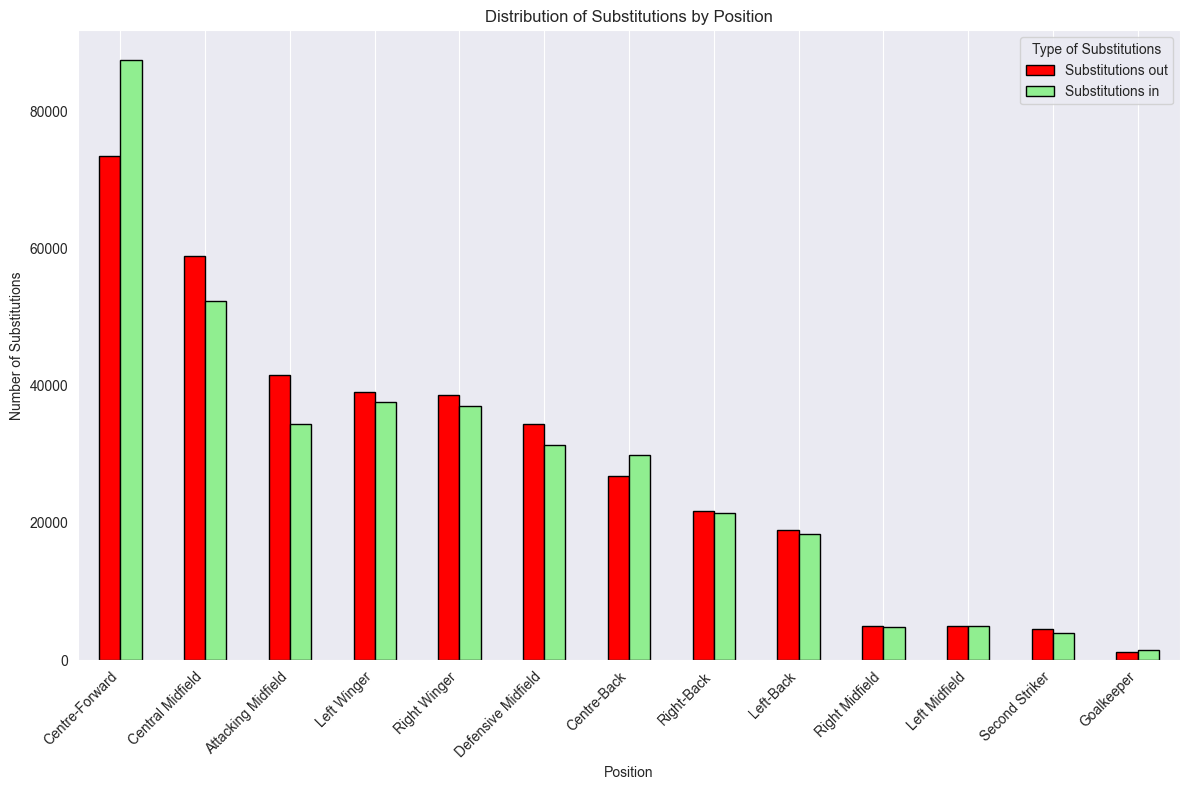

In [16]:
# Calculate the frequency of substitutions, excluding 'Missing' and 'unknown'
out_position_counts = substitutions[substitutions['position_out'] != 'unknown']['position_out'].value_counts()
in_position_counts = substitutions[substitutions['position_in'] != 'unknown']['position_in'].value_counts()

# Merge the substitution counts by position
position_counts = pd.concat([out_position_counts, in_position_counts], axis=1)
position_counts.columns = ['Substitutions out', 'Substitutions in']

fig, ax = plt.subplots(figsize=(12, 8))
position_counts.plot(kind='bar', color=['red', 'lightgreen'], edgecolor='black', ax=ax)
ax.set_title('Distribution of Substitutions by Position')
ax.set_xlabel('Position')
ax.set_ylabel('Number of Substitutions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Type of Substitutions', labels=['Substitutions out', 'Substitutions in'])
ax.grid(axis='y')
plt.tight_layout()
plt.show()

Statisticamente molte sostituzioni avvengono al '45 minuto, presumibilmente durante l'intervallo fra il primo tempo e il secondo tempo. Questa pratica è molto comune nel calcio perché permette di effettuare una sostituzione e risparmiare uno dei tre slots che l'allenatore ha a disposizione nei 90 minuti di gioco. Inoltre, statisticamente, la maggior parte delle sostituzioni avvengono fra il 65' e l'80' minuto, quando i giocatori sono stanchi e l'allenatore vuole dare una scossa alla squadra. 

In generale le zone in cui statisticamente è più consigliato fare un cambio sono: il centrocampo, l'attacco e le fasce. Infatti in queste zone di campo vi sono ruoli che, oltre ad essere molto dispendiosi a livello fisico, se cambiati al momento giusto aumentano indubbiamente la probabilità di mantenere o di ribaltare il risultato; senza sostituire per altro ruoli delicati come potrebbero essere il portiere o i difensori centrali. 

## 4. Quali caratteristiche fisiche devono avere i giocatori per ogni posizione?

### 4.1. Quale è l'altezza media per ciascuna posizione?

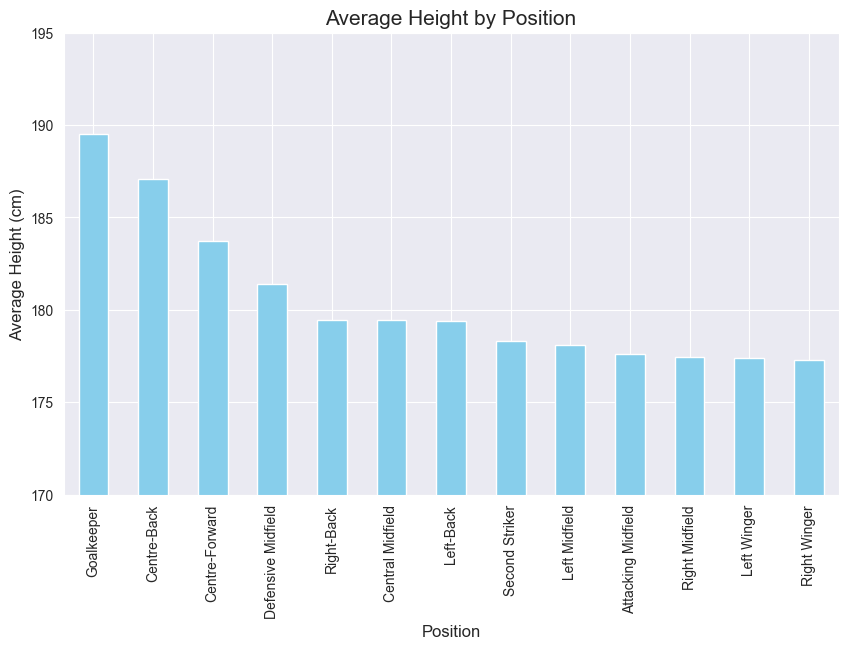

In [17]:
# Calculate the average height for each main position
average_height_by_position = players_df.groupby('sub_position')['height_in_cm'].mean()
filtered_average_height = average_height_by_position.drop('unknown', axis=0)

# Order the average height data by position in descending order
sorted_positions = filtered_average_height.sort_values(ascending=False).index

# Reorganize the DataFrames based on the order of positions sorted by height
filtered_average_height_sorted = filtered_average_height.reindex(sorted_positions)

fig, ax = plt.subplots(figsize=(10, 6))
filtered_average_height_sorted.plot(kind='bar', color='skyblue', ax=ax)
ax.set_title('Average Height by Position', fontsize=15)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Average Height (cm)', fontsize=12)
ax.set_ylim(170, 195)
plt.show()

### 4.2. Quale è il piede preferito per ciascuna posizione?

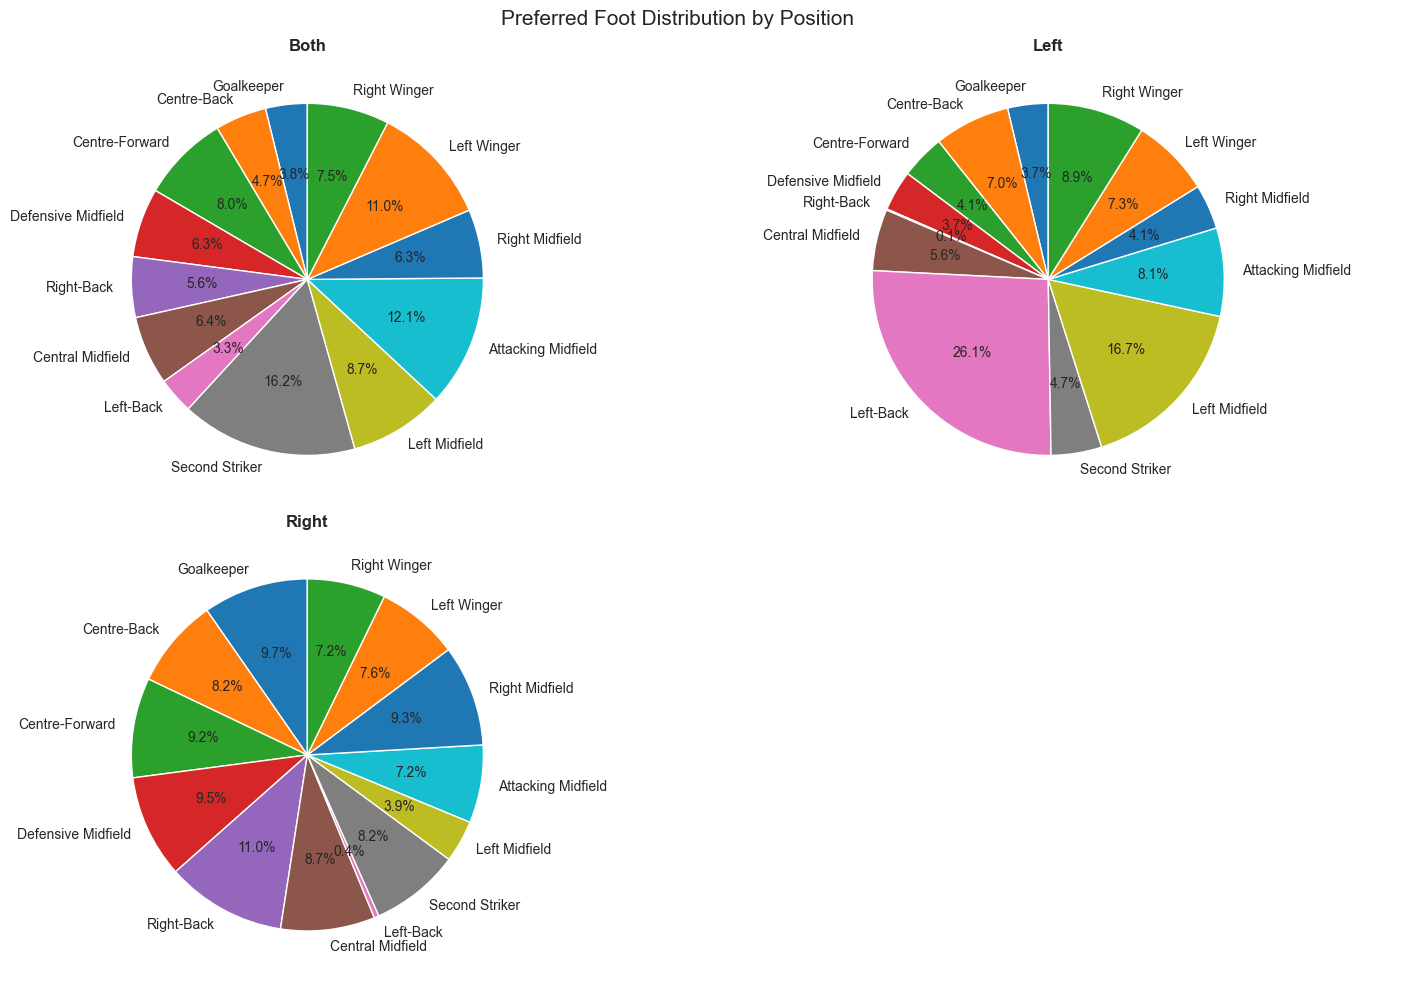

In [18]:
# Calculate the distribution of preferred foot by position
filtered_players = players_df[players_df['foot'] != 'unknown']
foot_distribution_by_position = filtered_players.groupby('sub_position')['foot'].value_counts(normalize=True).unstack(fill_value=0)

# Order the foot distribution data by position in descending order
filtered_foot_distribution_sorted = foot_distribution_by_position.reindex(sorted_positions)

fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 
fig.suptitle('Preferred Foot Distribution by Position', fontsize=15)

# Flatten the axes array when having more than one row of subplots to iterate over it
axes = axes.flatten()

# Plot a pie chart for each sub position
for i, (pos, data) in enumerate(filtered_foot_distribution_sorted.items()):
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(pos.capitalize(), fontweight='bold')

# Hide the extra axes if they exist
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout() 
plt.show()

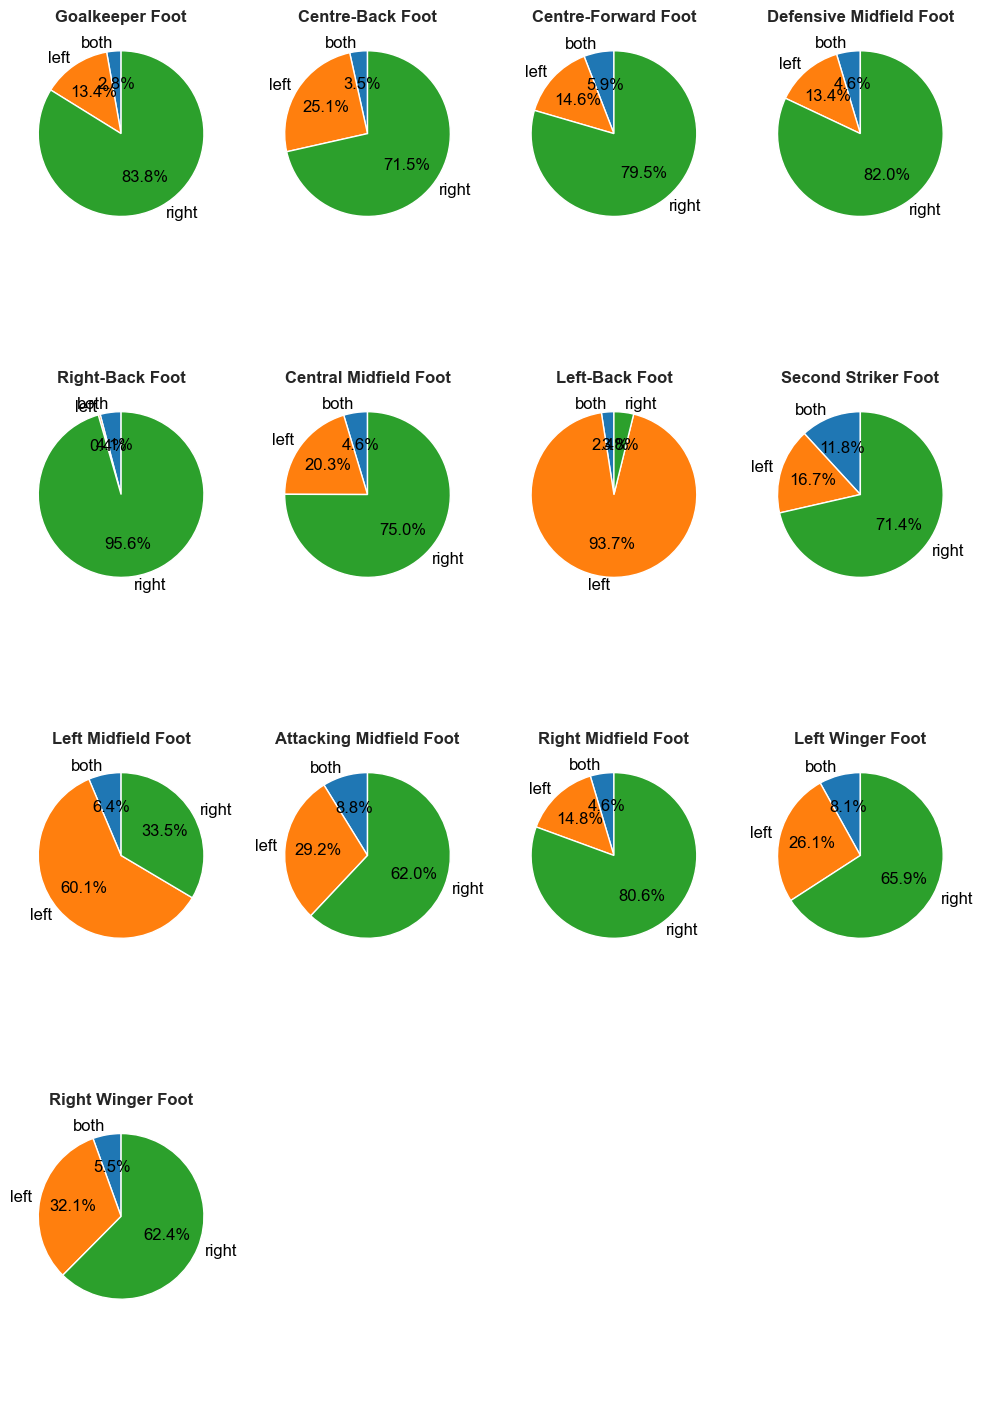

In [21]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 15)) 

# Generate a pie chart for each sub_position
for idx, (pos, data) in enumerate(filtered_foot_distribution_sorted.iterrows()):
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    ax.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'color': "black"})
    ax.set_title(f'{pos} Foot', fontsize=12, fontweight='bold')

# Hide the extra axes if there are fewer subplots than cells
for j in range(idx + 1, 4 * 4):
    row, col = divmod(j, 4)
    axes[row, col].axis('off')
    
plt.tight_layout()
plt.show()

Dalle analisi precedentemente fatte possiamo dedurre come nei ruoli del portiere, difensore centrale e del mediano sia molto importante avere dei giocatori alti, in modo che possano avere più sicurezza nel gioco aereo e possano contrastare meglio gli attaccanti avversari. 

Statisticamente è pratica molto comune mantenere i terzini dal lato del proprio piede dominante, a differenza delle ali d'attacco in cui talvolta si preferisce avere un giocatore che rientri all'interno del campo per poter andare verso la porta con il proprio piede dominante. Inoltre, è molto interessante notare, come i giocatori ambidestri ricoprino ruoli principalmente offensivi, per lasciare loro la possibilità di poter calciare con entrambi i piedi.

## 5. Quali caratteristiche deve avere il rigorista?

### 5.1. Di quale posizione sono statisticamente i rigoristi? 

In [22]:
# Filter the game events to find the penalty goals
penalty_goals = game_events_df[(game_events_df['description'].str.contains('penalty', case=False, na=False)) & (game_events_df['type'] == 'Goals')]

penalty_goals = penalty_goals.groupby('player_id').agg(num_penalty_goals=('player_id', 'size'), event_date=('date', 'first')).reset_index()

# Merge the player data for the penalty goals
penalty_goals_players = pd.merge(penalty_goals, players_df, on='player_id', how='left')

penalty_goals_players['age_at_goal'] = penalty_goals_players['event_date'].apply(lambda x: pd.to_datetime(x).year) - penalty_goals_players['date_of_birth'].apply(lambda x: pd.to_datetime(x).year)

penalty_goals_players = penalty_goals_players[['player_id', 'num_penalty_goals', 'event_date', 'country_of_citizenship', 'sub_position', 'age_at_goal', 'foot']]

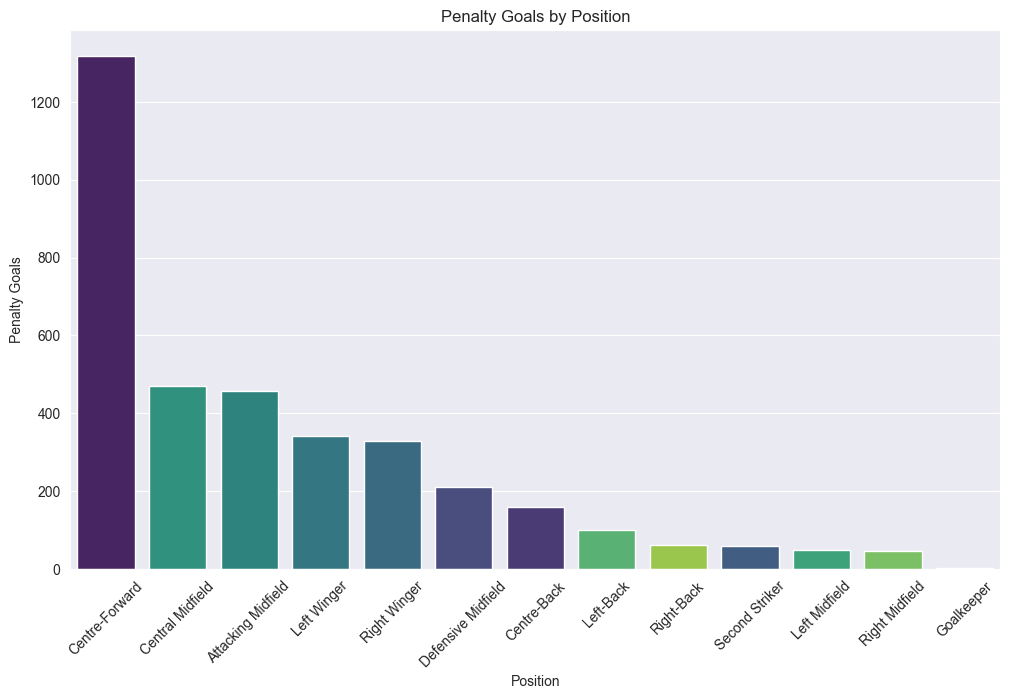

In [23]:
# Filter out the unknown sub_positions
penalty_goals_players = penalty_goals_players[penalty_goals_players['sub_position'] != 'unknown']
ordered_penalty_goals_players = penalty_goals_players['sub_position'].value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(data=penalty_goals_players, x='sub_position', hue='sub_position', order= ordered_penalty_goals_players, palette='viridis', dodge=False)
plt.title('Penalty Goals by Position')
plt.xlabel('Position')
plt.ylabel('Penalty Goals')
plt.xticks(rotation=45)
plt.legend([], frameon=False)  
plt.show()

### 5.2. Di quale nazione sono statisticamente i rigoristi?

_Nota: nei grafici geografici sono mostrate, sopra alcune nazioni, delle percentuali (>1%). Queste annotazioni rappresentano la percentuale totale di presenza dei giocatori per ogni nazione all'interno del dataset. Ad esempio all'interno del dataset, fra tutti i calciatori presenti, il 1,8% è argentino._ 

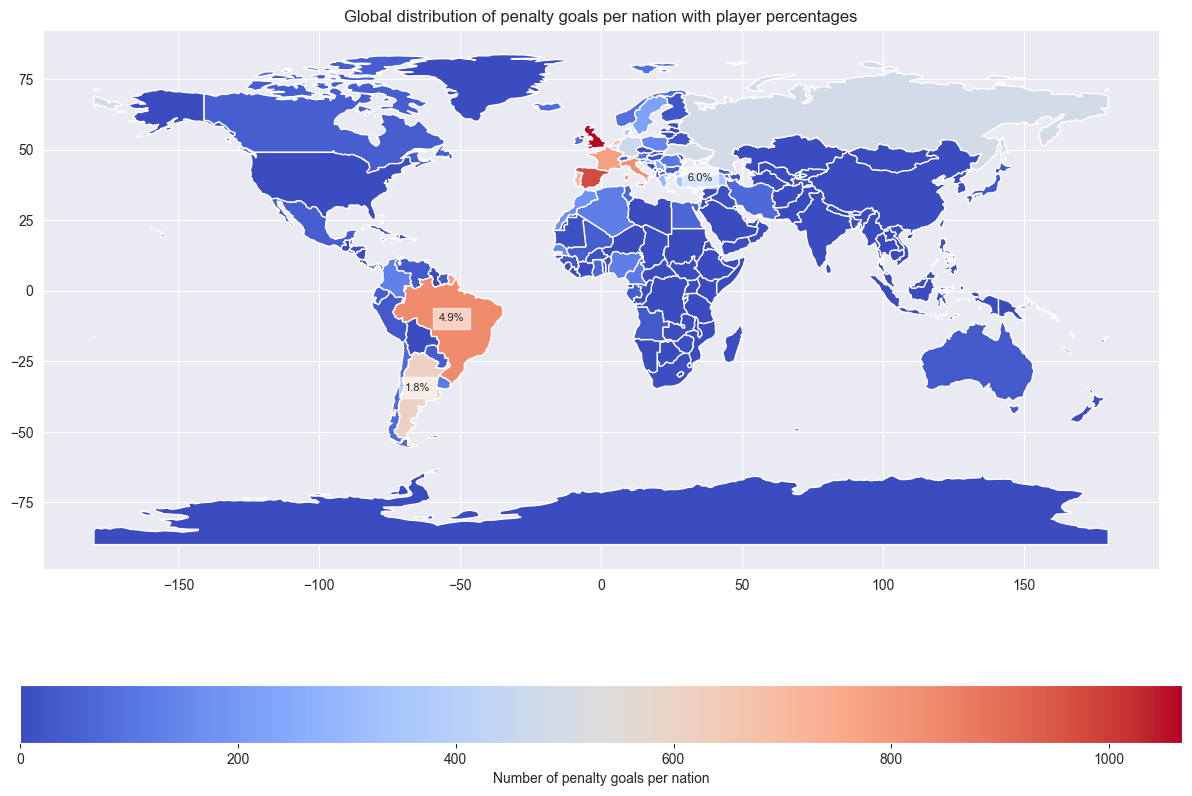

In [24]:
# Calculate the average age of the players who scored a penalty goal
goals_by_nationality = penalty_goals_players.groupby('country_of_citizenship')['num_penalty_goals'].sum().reset_index()

player_counts = players_df['country_of_citizenship'].value_counts()
total_players = player_counts.sum()
player_percentages = (player_counts / total_players * 100).reset_index()
player_percentages.columns = ['country_of_citizenship', 'percentage']

# Merge the percentage and goal data with the world map
world_goals = world_map.merge(goals_by_nationality, on='country_of_citizenship', how='left')
world_goals = world_goals.merge(player_percentages, on='country_of_citizenship', how='left')

world_goals['num_penalty_goals'] = world_goals['num_penalty_goals'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_goals.plot(column='num_penalty_goals', ax=ax, legend=True, legend_kwds={'label': "Number of penalty goals per nation", 'orientation': "horizontal"}, cmap='coolwarm')

# Annotate the percentage of players on the map
for idx, row in world_goals.iterrows():
    if pd.notna(row['geometry']) and pd.notna(row['percentage']) and row['percentage'] > 1:
        if row['continent'] != 'Europe': 
            x, y = row['geometry'].centroid.coords[0]
            ax.text(x, y, f"{row['percentage']:.1f}%", fontsize=8, ha='center',
                    bbox=dict(facecolor='white', alpha=0.6)) 

plt.title('Global distribution of penalty goals per nation with player percentages')
plt.show()

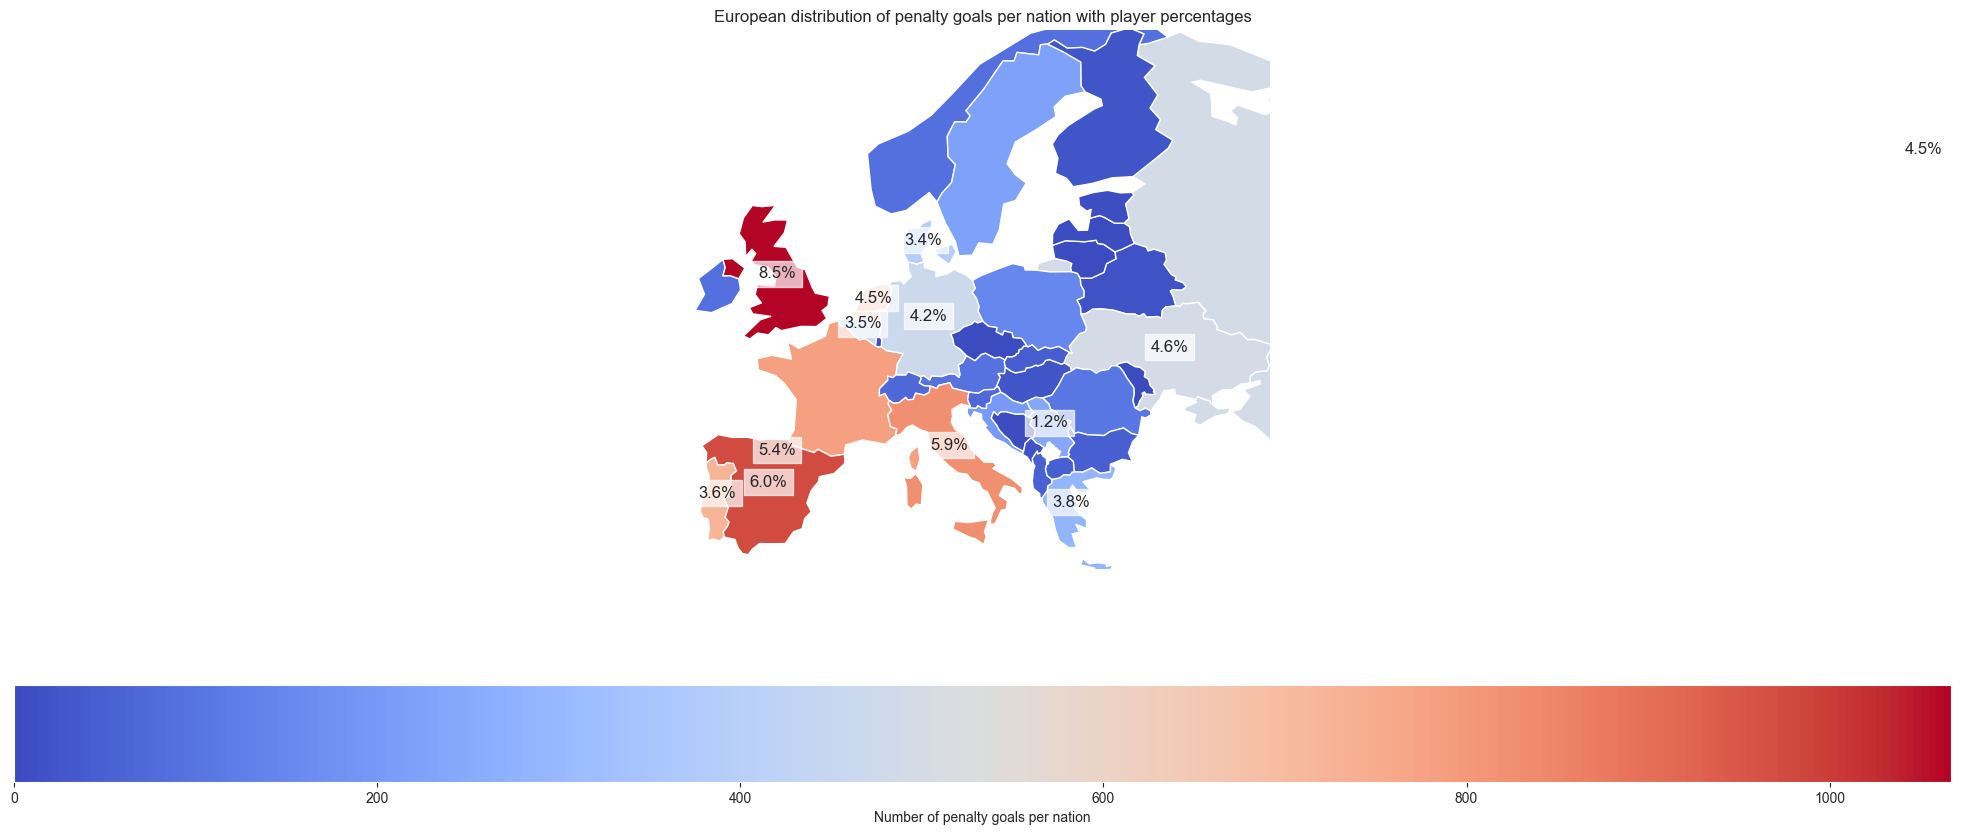

In [25]:
# Plotting
europe_goals = world_goals[world_goals['continent'] == 'Europe'].copy()
fig, ax = plt.subplots(1, 1, figsize=(25, 10)) 

europe_goals.plot(column='num_penalty_goals', ax=ax, legend=True, legend_kwds={'label': "Number of penalty goals per nation", 'orientation': "horizontal"}, cmap='coolwarm')

europe_goals['percentage'] = pd.to_numeric(europe_goals['percentage'], errors='coerce')

# Annotate the percentage of players on the map
for idx, row in europe_goals.iterrows():
    if row['percentage'] > 1:  
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, f"{row['percentage']:.1f}%", fontsize=12, ha='center', bbox=dict(facecolor='white', alpha=0.7)) 

plt.title('European distribution of penalty goals per nation with player percentages')
ax.set_xlim(-10, 40)   # Longitude 
ax.set_ylim(35, 70)   # Latitudine 
ax.set_axis_off()
plt.show()

### 5.3. Di quale età sono statisticamente i rigoristi?

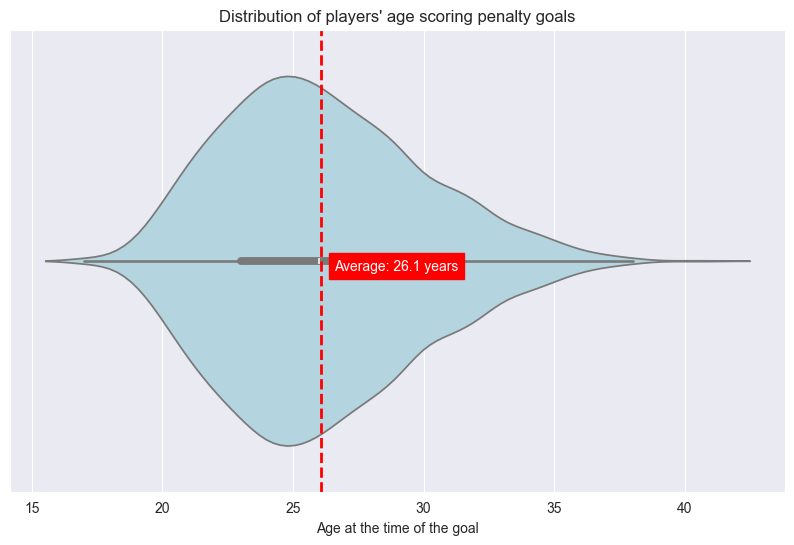

In [26]:
# Calculate average age 
mean_age_at_goal = penalty_goals_players['age_at_goal'].mean()

plt.figure(figsize=(10, 6))
sns.violinplot(x=penalty_goals_players['age_at_goal'], color='lightblue')
plt.axvline(mean_age_at_goal, color='red', linestyle='dashed', linewidth=2)
plt.text(mean_age_at_goal + 0.5, 0.02, f'Average: {mean_age_at_goal:.1f} years', color='white', backgroundcolor='red')
plt.title('Distribution of players\' age scoring penalty goals')
plt.xlabel('Age at the time of the goal')
plt.show()

### 5.3. Quale è statisticamente il piede dominante di un rigorista?

_Nota: vicino all'etichetta che indica il piede dominante, è mostrata anche la percentuale totale di giocatori con quel piede all'interno del dataset. Ad esempio, nel dataset il 70,1% dei giocatori è destro._

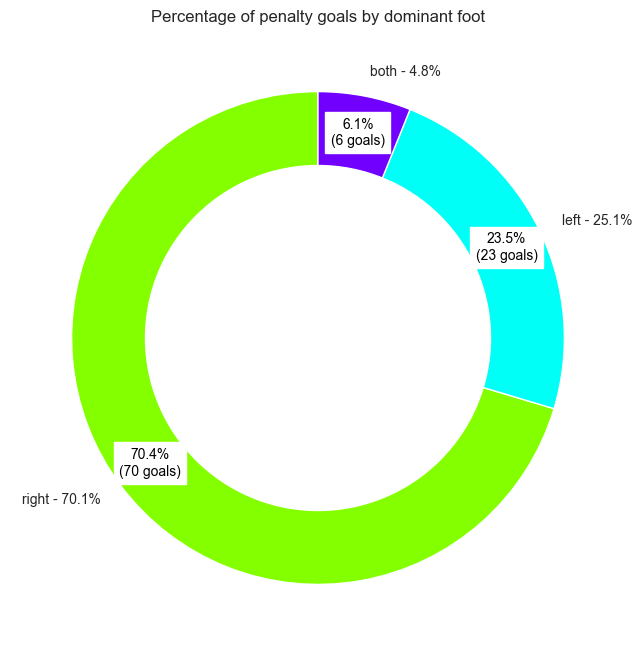

In [27]:
foot_distribution = penalty_goals_players['foot'].value_counts()

# Calculate the total percentages for each foot category excluding "unknown"
filtered_total_foot_counts = players_df[players_df['foot'] != 'unknown']['foot'].value_counts(normalize=True) * 100
filtered_total_penalty_foot_counts = penalty_goals_players[penalty_goals_players['foot'] != 'unknown']['foot'].value_counts(normalize=True) * 100

# Define the list of colors
colors = sns.color_palette("hsv", len(filtered_total_penalty_foot_counts))

# Function to add labels with background
def add_label_with_background(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d} goals)".format(pct, absolute)

# Prepare data for the foot pie chart with filtered percentages
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(filtered_total_penalty_foot_counts, labels=[f'{label} - {percent:.1f}%' for label, percent in filtered_total_foot_counts.items()], autopct=lambda pct: add_label_with_background(pct, filtered_total_penalty_foot_counts),colors=colors, startangle=90, pctdistance=0.85)

# Draw the circle at the center to make the pie chart a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add text with background
for text, autotext in zip(texts, autotexts):
    autotext.set_color('black')
    autotext.set_backgroundcolor('white')

plt.title('Percentage of penalty goals by dominant foot')
plt.show()

Dalle analisi statistiche fatte possiamo dedurre che i rigoristi ideali tendono a essere:
- Attaccanti o centrocampisti
- Di età attorno ai 26 anni
- Principalmente di piede destro, in quanto i giocatori con questo piede dominante sono molti di più. Come si può anche vedere dalle percentuali mostrate nel grafico, la dominanza del piede non cambia molto. 

## 6. Quali caratteristiche hanno statisticamente i giocatori sostituiti a causa di un infortunio? 

### 6.1. A quale minuto statisticamente i giocatori vengono sostituiti a causa di un infortunio?

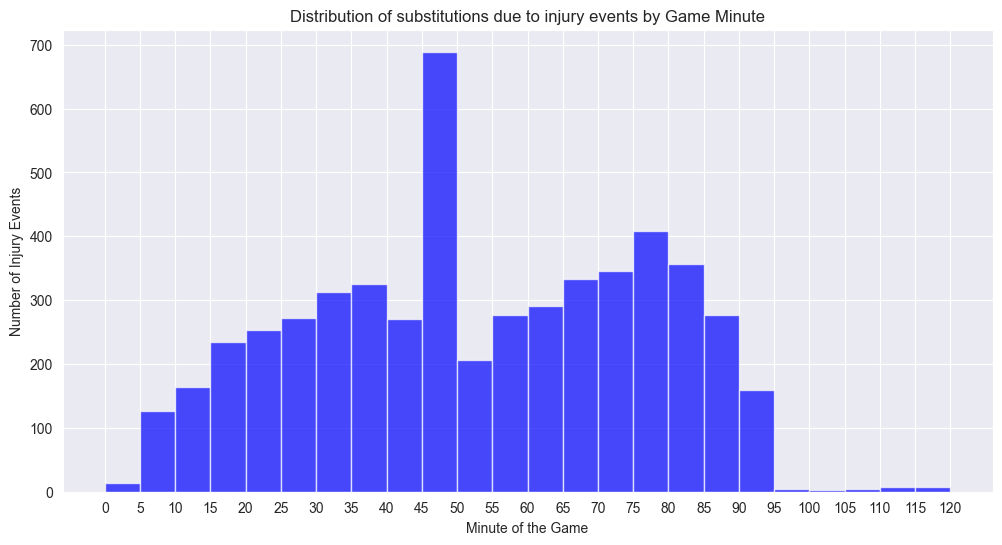

In [28]:
# Filter for events that mention "injury" in their description
injury_events_df = game_events_df[game_events_df['description'].str.contains("injury", case=False, na=False)]
injury_events_df = injury_events_df.drop(columns=['type', 'player_assist_id'])

# Merge the injury events data with player data to include player positions
injury_player_position = pd.merge(injury_events_df, players_df[['player_id', 'sub_position']], on='player_id', how='left')

# Plot the distribution of injury events over the minutes of the game
plt.figure(figsize=(12, 6))
plt.hist(injury_events_df['minute'], bins=range(0, 121, 5), color='blue', alpha=0.7)
plt.title('Distribution of substitutions due to injury events by Game Minute')
plt.xlabel('Minute of the Game')
plt.ylabel('Number of Injury Events')
plt.xticks(range(0, 121, 5))
plt.grid(True)
plt.show()

### 6.2. Quale è statisticamente la posizione in cui vengono sostituiti più giocatori per infortunio?

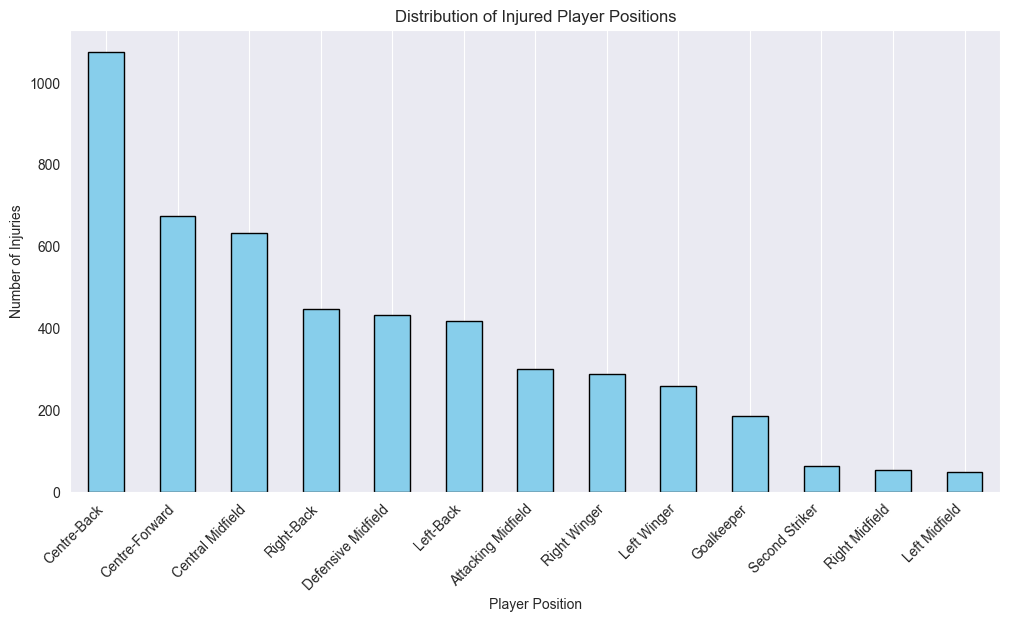

In [29]:
# Count the frequency of injuries by player position
injury_positions_count = injury_player_position['sub_position'].value_counts()

# Filter out the unknown sub_positions
injury_player_position = injury_player_position[injury_player_position['sub_position'] != 'unknown']

# Plot the distribution of injured player positions
plt.figure(figsize=(12, 6))
injury_player_position['sub_position'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Injured Player Positions')
plt.xlabel('Player Position')
plt.ylabel('Number of Injuries')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

### 6.3. Qual è statisticamente l'età media dei giocatori sostituiti a causa di un infortunio?

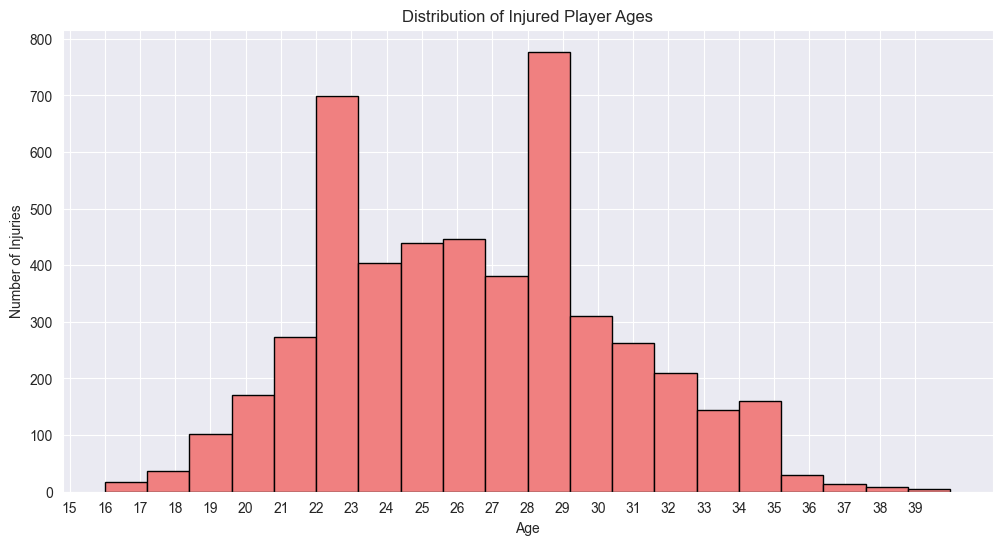

In [30]:
players_df['date_of_birth'] = pd.to_datetime(players_df['date_of_birth'])
injury_player_age = pd.merge(injury_events_df, players_df[['player_id', 'date_of_birth']], on='player_id', how='left')

# Convert date strings to datetime objects for calculation
injury_player_age['date'] = pd.to_datetime(injury_player_age['date'])
players_df['date_of_birth'] = pd.to_datetime(players_df['date_of_birth'])

# Calculate age at the time of injury
injury_player_age['age_at_injury'] = (injury_player_age['date'] - injury_player_age['date_of_birth']).dt.days // 365

# Plot the distribution of injured player ages
plt.figure(figsize=(12, 6))
injury_player_age['age_at_injury'].hist(bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Injured Player Ages')
plt.xticks(range(15, 40, 1))
plt.xlabel('Age')
plt.ylabel('Number of Injuries')
plt.grid(True)
plt.show()

### 6.4. Quali sono le nazionalità che hanno la maggior frequenza di giocatori sostituiti a causa di un infortunio in percentuale al proprio numero di giocatori totali?

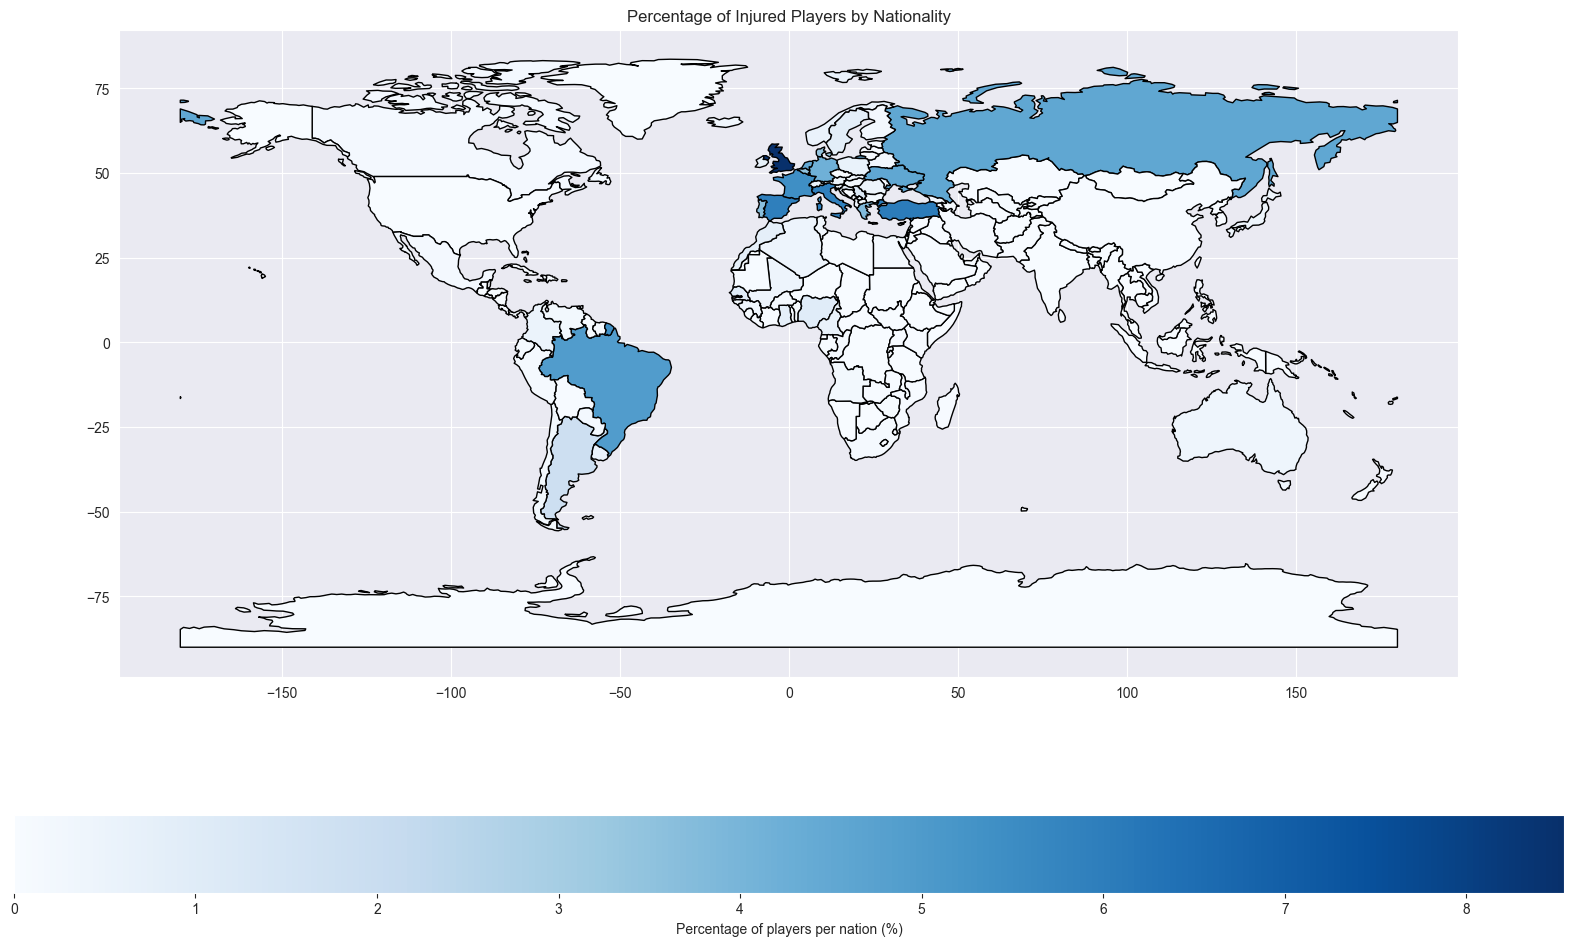

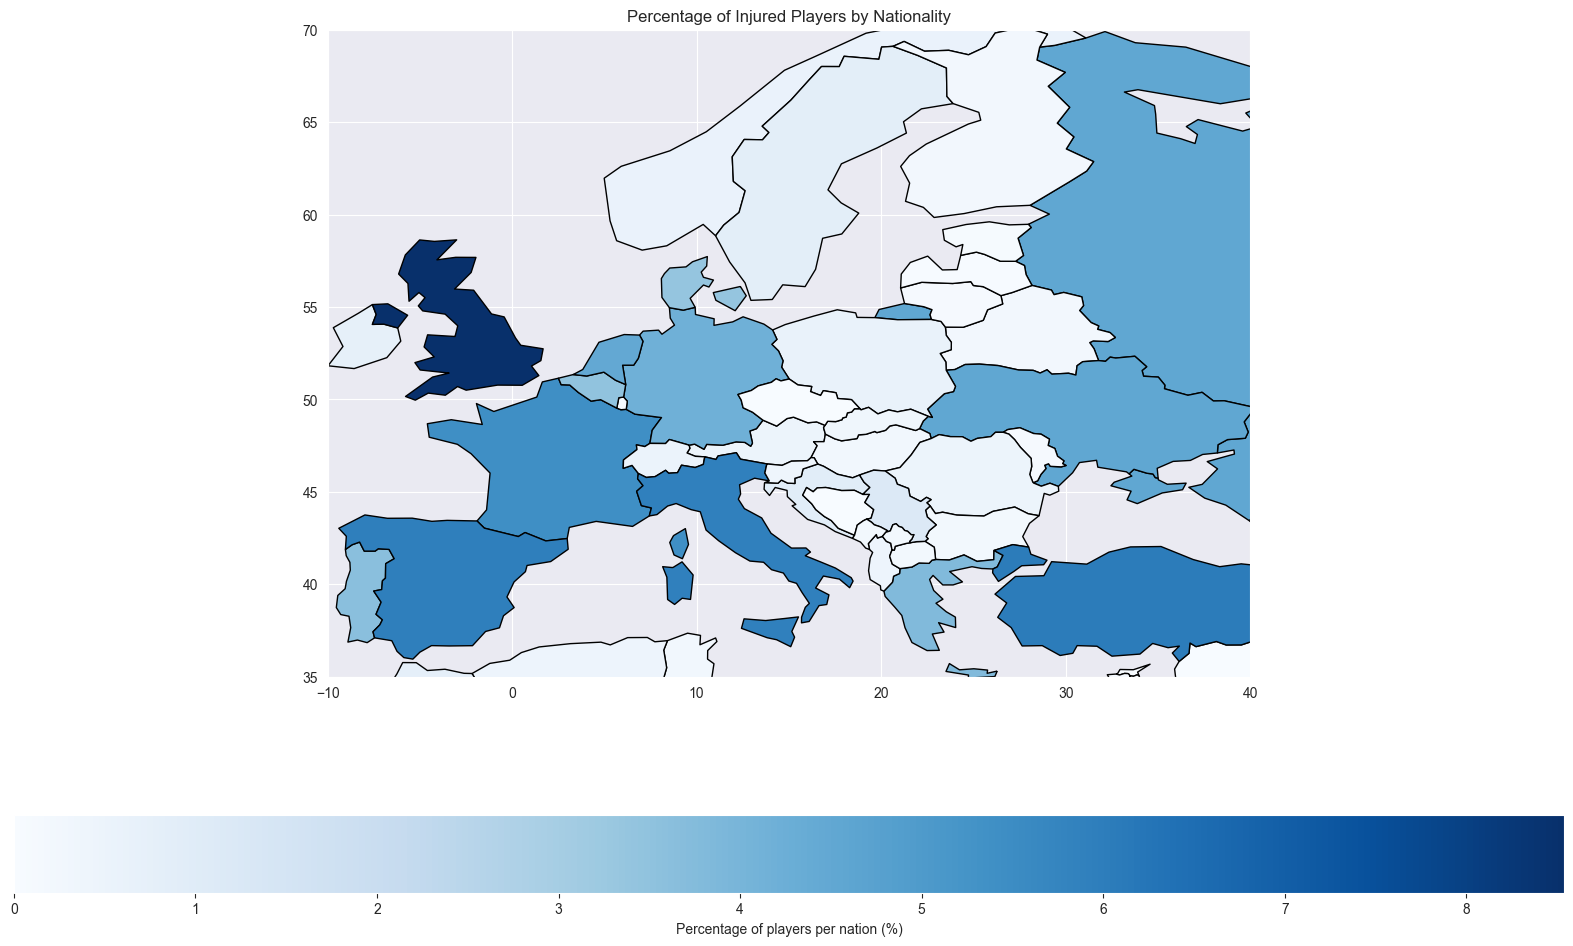

In [31]:
# Merge to include player nationalities
injury_player_nationalities = pd.merge(injury_events_df, players_df[['player_id', 'country_of_citizenship']], on='player_id', how='left')

# Count the frequency of injuries by player nationality
injury_nationalities_count = injury_player_nationalities['country_of_citizenship'].value_counts().head(10)

# Calculate the total number of players per nationality
total_players_per_nation = players_df['country_of_citizenship'].value_counts()

# Calculate the total number of players in the dataset
total_players = players_df['country_of_citizenship'].count()

# Calculate the percentage
nation_percentage = total_players_per_nation / total_players * 100
nation_percentage_df = nation_percentage.reset_index()
nation_percentage_df.columns = ['country_of_citizenship', 'percentage']

# Merge with the world map
merged = world_map.merge(nation_percentage_df, on='country_of_citizenship', how='left')

# Fill NaN values with 0 for countries without player data
merged['percentage'] = merged['percentage'].fillna(0)

# Plotting of World Map
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
merged.plot(column='percentage', ax=ax, legend=True, legend_kwds={'label': "Percentage of players per nation (%)", 'orientation': "horizontal"},cmap='Blues', edgecolor='black')

plt.title('Percentage of Injured Players by Nationality')
plt.show()

# Plotting of Europe Map
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
merged.plot(column='percentage', ax=ax, legend=True,legend_kwds={'label': "Percentage of players per nation (%)", 'orientation': "horizontal"}, cmap='Blues', edgecolor='black')
ax.set_xlim(-10, 40)   # Longitude 
ax.set_ylim(35, 70)   # Latitudine 
plt.title('Percentage of Injured Players by Nationality')
plt.show()

Come si poteva immaginare vi è un picco di sostituzioni, a causa di infortunio, durante l'intervallo fra il primo e il secondo tempo (vedi commento alla domanda 3). Ricordiamo infatti che stiamo analizzando (perché unica informazione riguardante gli infortuni all'interno del nostro dataset) a quale minuto avvengono le SOSTITUZIONI causate da un infortunio e non gli infortuni in sè. Possiamo anche vedere come le sostituzioni a causa di infortuni si concentrino poco prima della fine del primo o del secondo tempo. Questo dimostra come quei minuti siano cruciali e di alta intensità.  

Inoltre queste analisi offrono una panoramica completa su quali giocatori, in termini di ruolo, età e nazionalità, sono più propensi agli infortuni:
- La distribuzione degli infortuni per ruolo mostra che i difensori centrali sono i più colpiti, seguiti dagli attaccanti centrali e gli altri giocatori che completano il reparto difensivo.
- L'istogramma sull'età indica che la maggior parte degli infortuni mostra due picchi intorno i 22 e i 28 anni. Potrebbe essere interessante chiedersi perché questi due picchi si verificano e se ci sono motivi specifici per cui i giocatori di queste età sono più soggetti agli infortuni. Probabilmente ciò è legato dal cambiamento del fisico in quelle età per un atleta. 
- Il grafico geografico mostra come i giocatori del Regno Unito, Spagna e Brasile sono molto soggetti agli infortuni a partita in corso. Molto importante è notare come questi stati hanno una grossa percentuale di giocatori all'interno del nostro dataset, di conseguenza è normale che i giocatori che hanno subito un infortunio sono maggiori. 

## 7. Di quale età media deve essere la nostra squadra? 

### 7.1. Quale è l'età media dei clubs?

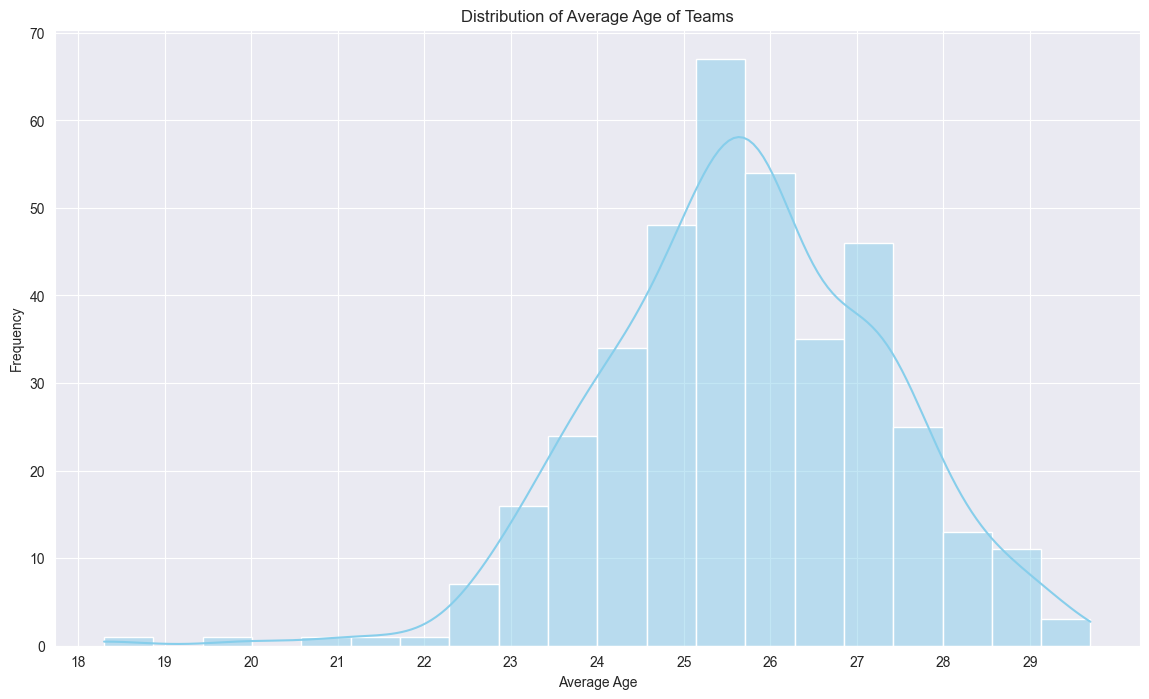

In [32]:
# Exclude -1 values from the 'average_age' column
filtered_clubs_df = clubs_df[clubs_df['average_age'] != -1]

# Plotting the average age of teams with more labels on the x-axis
plt.figure(figsize=(14, 8))
sns.histplot(filtered_clubs_df['average_age'], bins=20, kde=True, color='skyblue')

# Adding titles and labels
plt.title('Distribution of Average Age of Teams')
plt.xlabel('Average Age')
plt.ylabel('Frequency')
# Setting more ticks on the x-axis
plt.xticks(ticks=range(int(filtered_clubs_df['average_age'].min()), int(filtered_clubs_df['average_age'].max()) + 1))
plt.show()

### 7.2. Quale è l'età media delle 20 squadre più vincenti d'europa nell'ultima stagione?

_Nota: stiamo cercando le 20 squadre con il maggior numero di vittorie nell'ultima stagione (2023/2024), pertanto il numero di partite totali della stagione sarà ridotto, siccome il nostro dataset si ferma il mese di Novembre. Questa analisi sulle 20 squadre più vincenti ritornerà nella statistica analizzata al punto 11_

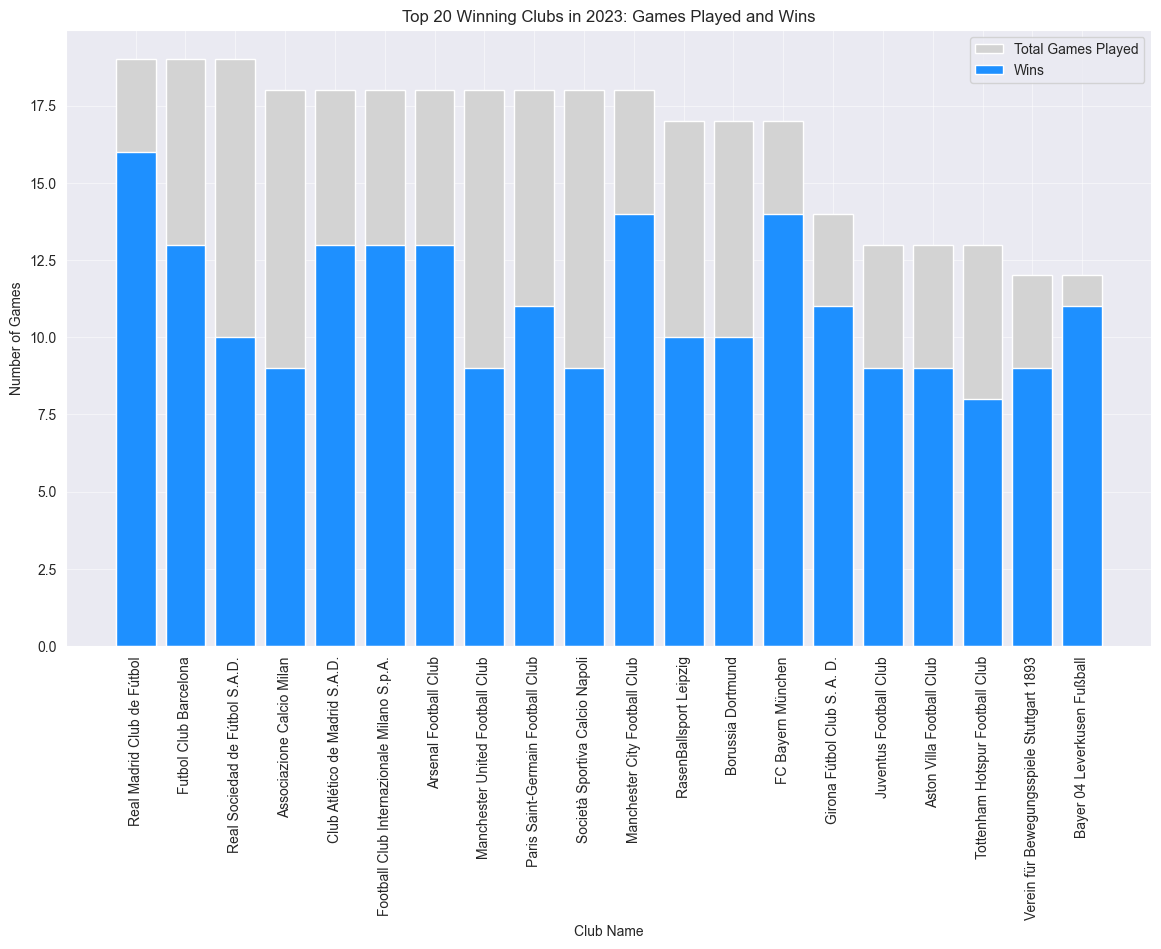

In [33]:
games_2023 = games_df[(games_df['season'] == 2023) & (games_df['competition_id'].isin(competitions))]

# Calculate the number of home and away wins for each club
home_wins = games_2023[games_2023['home_club_goals'] > games_2023['away_club_goals']].groupby('home_club_id').size().reset_index(name='home_wins')
away_wins = games_2023[games_2023['away_club_goals'] > games_2023['home_club_goals']].groupby('away_club_id').size().reset_index(name='away_wins')

# Calculate the number of home and away games for each club
home_games = games_2023.groupby('home_club_id').size().reset_index(name='home_games')
away_games = games_2023.groupby('away_club_id').size().reset_index(name='away_games')

# Merge home and away wins and games
total_wins = pd.merge(home_wins, away_wins, left_on='home_club_id', right_on='away_club_id', how='outer').fillna(0)
total_games = pd.merge(home_games, away_games, left_on='home_club_id', right_on='away_club_id', how='outer').fillna(0)

# Rename and calculate the total columns
total_wins['total_wins'] = total_wins['home_wins'] + total_wins['away_wins']
total_games['total_games'] = total_games['home_games'] + total_games['away_games']

# Extract the unified club ID and total wins
total_wins['club_id'] = total_wins['home_club_id'].combine_first(total_wins['away_club_id'])
total_games['club_id'] = total_games['home_club_id'].combine_first(total_games['away_club_id'])

# Merge with the clubs dataset to get the club names
total_wins = total_wins[['club_id', 'total_wins']]
total_games = total_games[['club_id', 'total_games']]
club_wins_games = pd.merge(clubs_df[['club_id', 'name', 'average_age']], total_wins, on='club_id')
club_wins_games = pd.merge(club_wins_games, total_games, on='club_id')

# Extract the top 20 clubs based on the number of wins
top_20_club_names_2023 = club_wins_games.nlargest(20, 'total_wins')

# Order the data by the total number of games played
top_20_club_names_2023_sorted = top_20_club_names_2023.sort_values(by='total_games', ascending=False)

plt.figure(figsize=(14, 8))
# Bar chart for the total number of games played
plt.bar(top_20_club_names_2023_sorted['name'], top_20_club_names_2023_sorted['total_games'], color='lightgray', label='Total Games Played')
# Bar chart for the total number of wins
plt.bar(top_20_club_names_2023_sorted['name'], top_20_club_names_2023_sorted['total_wins'], color='dodgerblue', label='Wins')
plt.xlabel('Club Name')
plt.ylabel('Number of Games')
plt.title('Top 20 Winning Clubs in 2023: Games Played and Wins')
plt.xticks(rotation=90)  
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

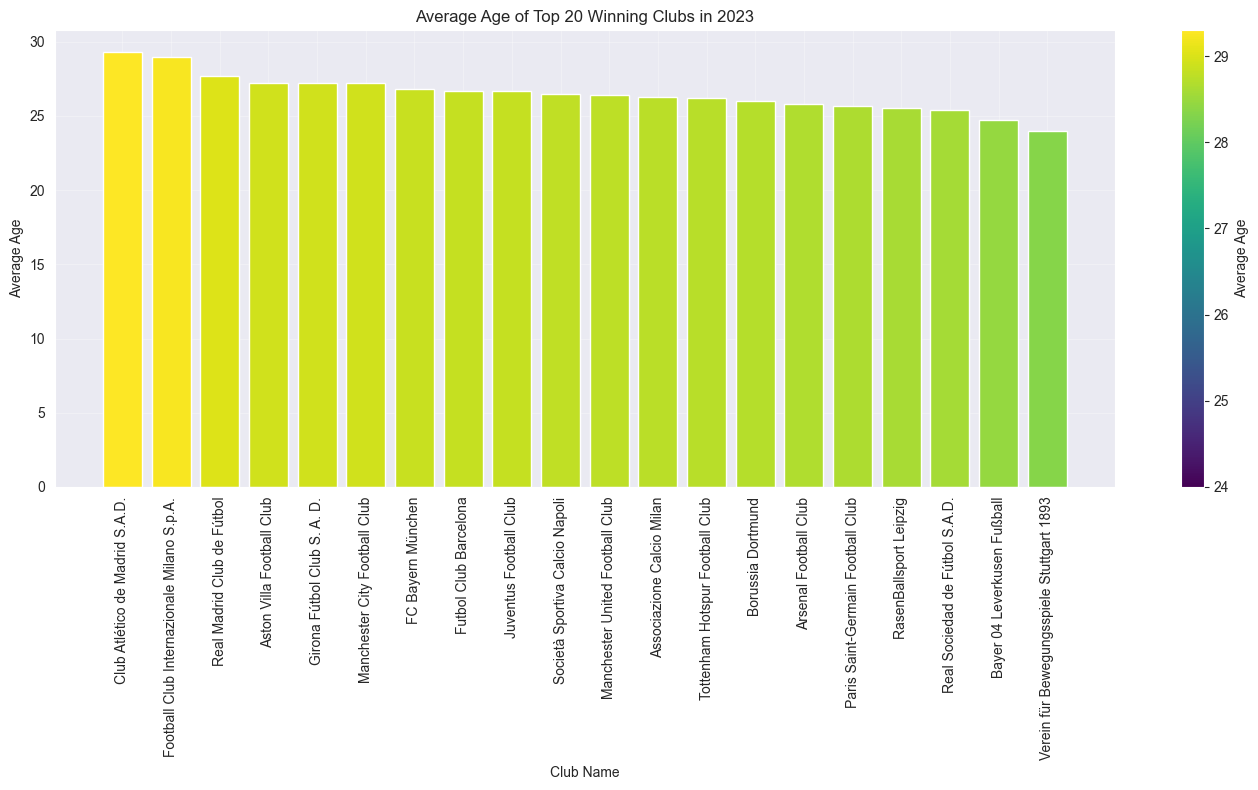

In [34]:
top_20_club_names_2023_sorted = top_20_club_names_2023.sort_values(by='average_age', ascending=False)

# Create a visually appealing bar chart
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis(top_20_club_names_2023_sorted['average_age'] / max(top_20_club_names_2023_sorted['average_age']))
bars = ax.bar(top_20_club_names_2023_sorted['name'], top_20_club_names_2023_sorted['average_age'], color=colors)

# Add a color bar
norm = plt.Normalize(vmin=min(top_20_club_names_2023_sorted['average_age']), vmax=max(top_20_club_names_2023_sorted['average_age']))
sm = ScalarMappable(cmap='viridis', norm=norm)
cbar = fig.colorbar(sm, ax=ax, label='Average Age')

# Adding labels and title
ax.set_xlabel('Club Name')
ax.set_ylabel('Average Age')
ax.set_title('Average Age of Top 20 Winning Clubs in 2023')
ax.grid(True, alpha=0.3)  # Grid with light alpha for better visibility of bars
plt.xticks(rotation=90)
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels

plt.show()

Come si può notare l'età media dei club si aggira intorno i 25/26 anni. Invece, per quanto riguarda le 20 squadre europee più vincenti dell'ultima stagione, la media di età dei componenti della squadra è di circa 28/29 anni. Questo indica che si può essere competitivi avendo una rosa più esperta. 

## 8. Quale è la dimensione giusta per lo stadio?

### 8.1. Quale è la dimensione globale degli stadi?

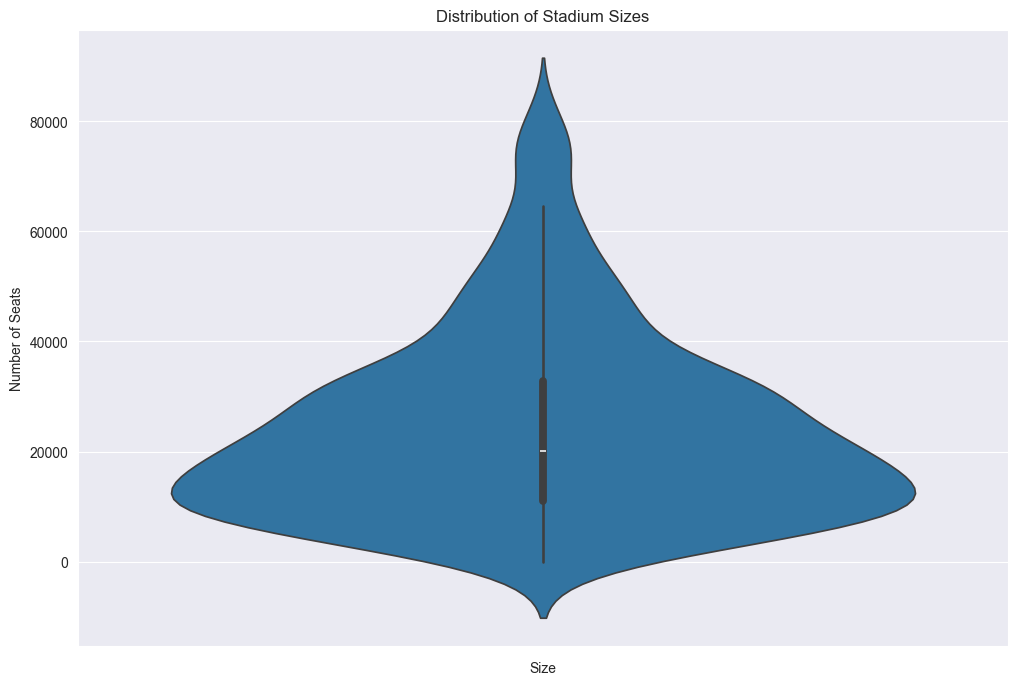

In [35]:
# Violin plot for stadium sizes
plt.figure(figsize=(12, 8))
sns.violinplot(data=clubs_df, y='stadium_seats')
plt.title('Distribution of Stadium Sizes')
plt.xlabel('Size')
plt.ylabel('Number of Seats')
plt.show()

### 8.2. Qual è la distribuzione dell'affluenza negli stadi?

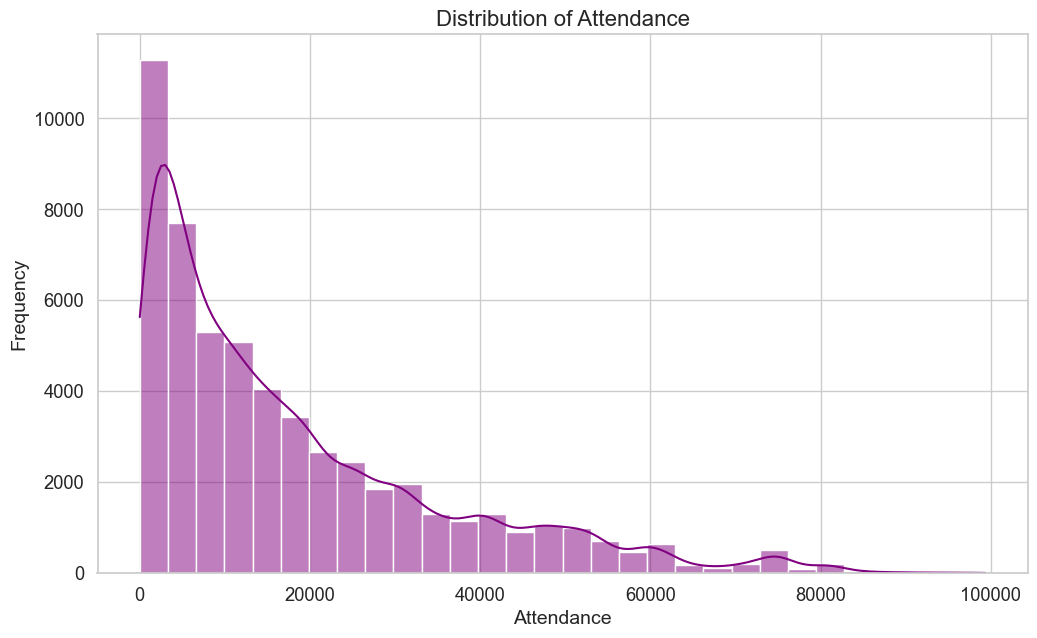

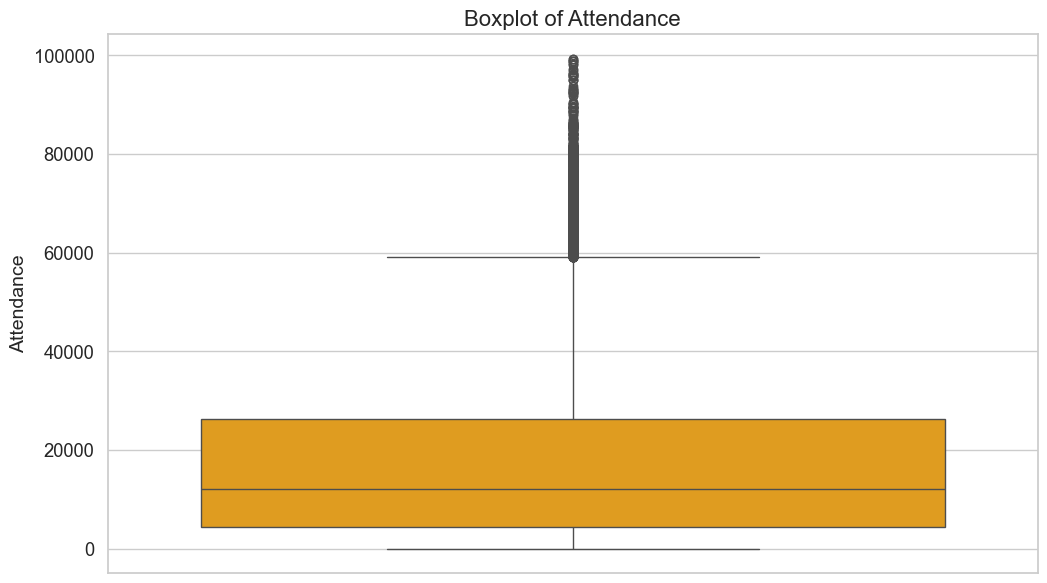

In [36]:
attendance = games_df[games_df['attendance'] != -1]['attendance'].dropna()

# Set a base style for the plots
sns.set(style="whitegrid", palette="bright", font_scale=1.2)

# Histogram plot
plt.figure(figsize=(12, 7))
sns.histplot(attendance, kde=True, bins=30, color='purple')
plt.title('Distribution of Attendance', fontsize=16)
plt.xlabel('Attendance', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

# Boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(y=attendance, color='orange')
plt.title('Boxplot of Attendance', fontsize=16)
plt.ylabel('Attendance', fontsize=14)
plt.show()

### 8.2. Che correlazione c'è fra pienezza dello stadio e risultato?

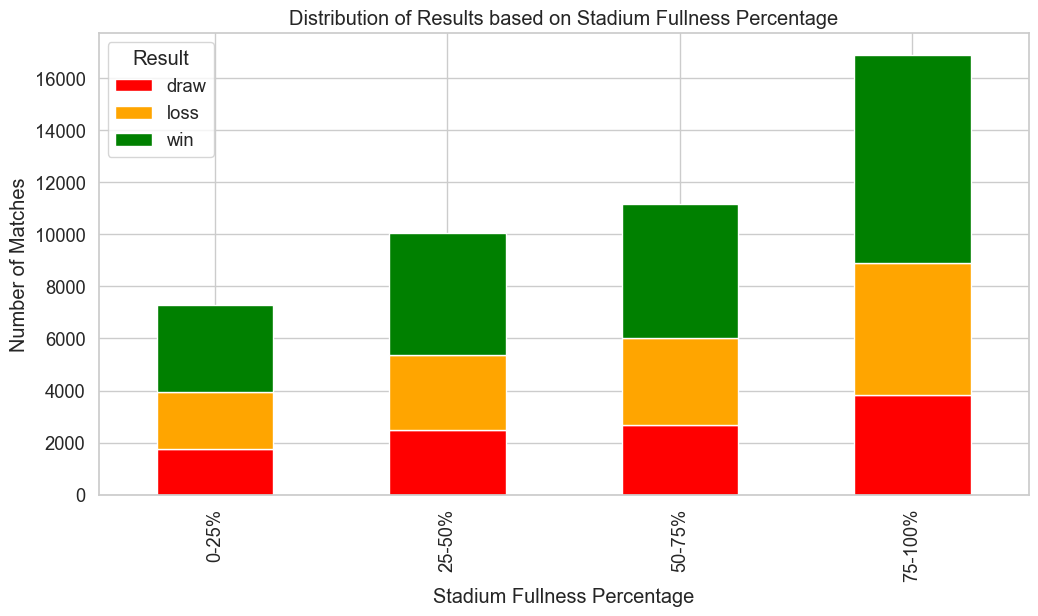

In [37]:
# Filter the necessary columns
clubs = clubs_df[['club_id', 'stadium_seats']]
games = games_df[['home_club_id', 'attendance', 'home_club_goals', 'away_club_goals']].copy()

# Exclude -1 values in the attendance field
games = games[games['attendance'] != -1]

# Determine the result of the home team
games['home_team_result'] = games.apply(lambda x: 'win' if x['home_club_goals'] > x['away_club_goals'] else ('draw' if x['home_club_goals'] == x['away_club_goals'] else 'loss'), axis=1)

# Merge game data with stadium data
data = pd.merge(games, clubs, left_on='home_club_id', right_on='club_id')

# Calculate the stadium fullness percentage
data['stadium_fullness'] = data['attendance'] / data['stadium_seats']

# Convert results to numeric values to calculate correlation
result_mapping = {'win': 3, 'draw': 1, 'loss': 0}
data['home_team_result_numeric'] = data['home_team_result'].map(result_mapping)

# Calculate correlation
correlation = data[['stadium_fullness', 'home_team_result_numeric']].corr().iloc[0, 1]

# Bar plot to visualize the distribution of wins relative to stadium fullness percentage
data['fullness_category'] = pd.cut(data['stadium_fullness'], bins=[0, 0.25, 0.5, 0.75, 1], labels=['0-25%', '25-50%', '50-75%', '75-100%'])
fullness_vs_result = data.groupby(['fullness_category', 'home_team_result'], observed=False).size().unstack().fillna(0)

fullness_vs_result.plot(kind='bar', stacked=True, color=['red', 'orange', 'green'], figsize=(12, 6))
plt.title('Distribution of Results based on Stadium Fullness Percentage')
plt.xlabel('Stadium Fullness Percentage')
plt.ylabel('Number of Matches')
plt.legend(title='Result')
plt.show()

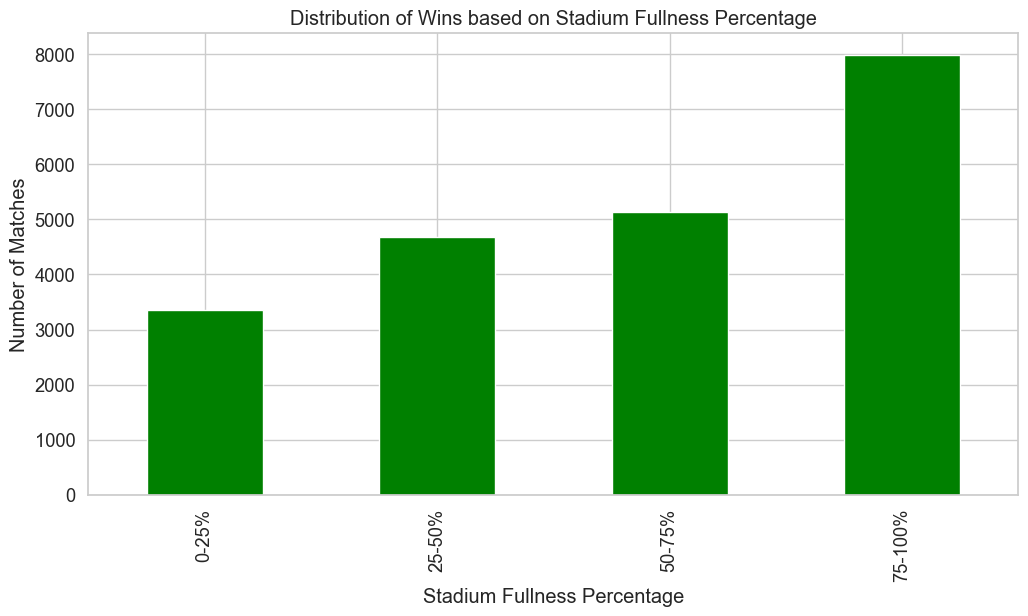

In [38]:
# Filter the data to include only the rows where the home team has won
wins_data = data[data['home_team_result'] == 'win']
fullness_vs_result = wins_data.groupby(['fullness_category', 'home_team_result'], observed=False).size().unstack().fillna(0)

fullness_vs_result.plot(kind='bar', stacked=True, color=['green'], figsize=(12, 6), legend=False)
plt.title('Distribution of Wins based on Stadium Fullness Percentage')
plt.xlabel('Stadium Fullness Percentage')
plt.ylabel('Number of Matches')
plt.show()

In [39]:
correlation

-0.008683457791412557

La determinazione della dimensione ideale dello stadio non è una scelta facile. Una dimensione ottimale potrebbe tenere conto della maggior parte delle partite, riducendo al minimo i posti vuoti ma consentendo comunque una certa flessibilità per partite con affluenza maggiore. Un buon punto di partenza potrebbe essere il 75° percentile, che è circa 26.184. Questa dimensione permetterebbe di gestire la maggior parte delle partite senza avere troppi posti vuoti. Se si vuole consentire spazio per partite con maggiore affluenza, si potrebbe considerare un valore più alto, ad esempio il 90° o 95° percentile.

Dall'analisi statistica si può notare come la media della grandezza degli stadi europei si aggiri intorno i 20.000 posti. Non sempre si riesce a riempire lo stadio completamente, ci siamo chiesti se questo provochi un cambiamento di atteggiamento da parte dei calciatori in campo. In altre parole: è meglio avere uno stadio grande ma parzialmente vuoto o uno stadio piccolo ma pieno? Per rispondere ci siamo chiesti se ci fosse una correlazione fra le vittorie, sconfitte e pareggi della squadra di casa in base alla percentuale di pienezza dello stadio, pur sapendo che il numero degli spettatori è calcolato considerando sia i tifosi ospiti che quelli di casa. Come dimostrano il valore della _"correlation"_ e i grafici, parrebbe che non ci sia, per i dati che abbiamo a nostra disposizione, un legame fra le due cose.   

## 9. Quali sono le nazioni con i giocatori più esperti e con le migliori valutazioni di mercato?

### 9.1. Qual è la media dell'esperienza dei giocatori per nazione?

In [40]:
# Filter players with last_season 2023
current_players = players_df[players_df['last_season'] == 2023]

# Merge filtered player data with valuations
current_player_valuations = current_players.merge(player_valuations_df, on='player_id', how='left')

# Convert the date column to datetime and then extract the year if not already done
current_player_valuations['date'] = pd.to_datetime(current_player_valuations['date'])
current_player_valuations['year'] = current_player_valuations['date'].dt.year

# Find the year of the first valuation for each player
first_valuation_year = current_player_valuations.groupby('player_id')['year'].min().reset_index()
first_valuation_year.columns = ['player_id', 'first_valuation_year']

# Merge the year of the first valuation with the players dataframe
players_with_experience = current_players.merge(first_valuation_year, on='player_id', how='left')

# Calculate the 'experience' column
players_with_experience['experience'] = 2023 - players_with_experience['first_valuation_year']

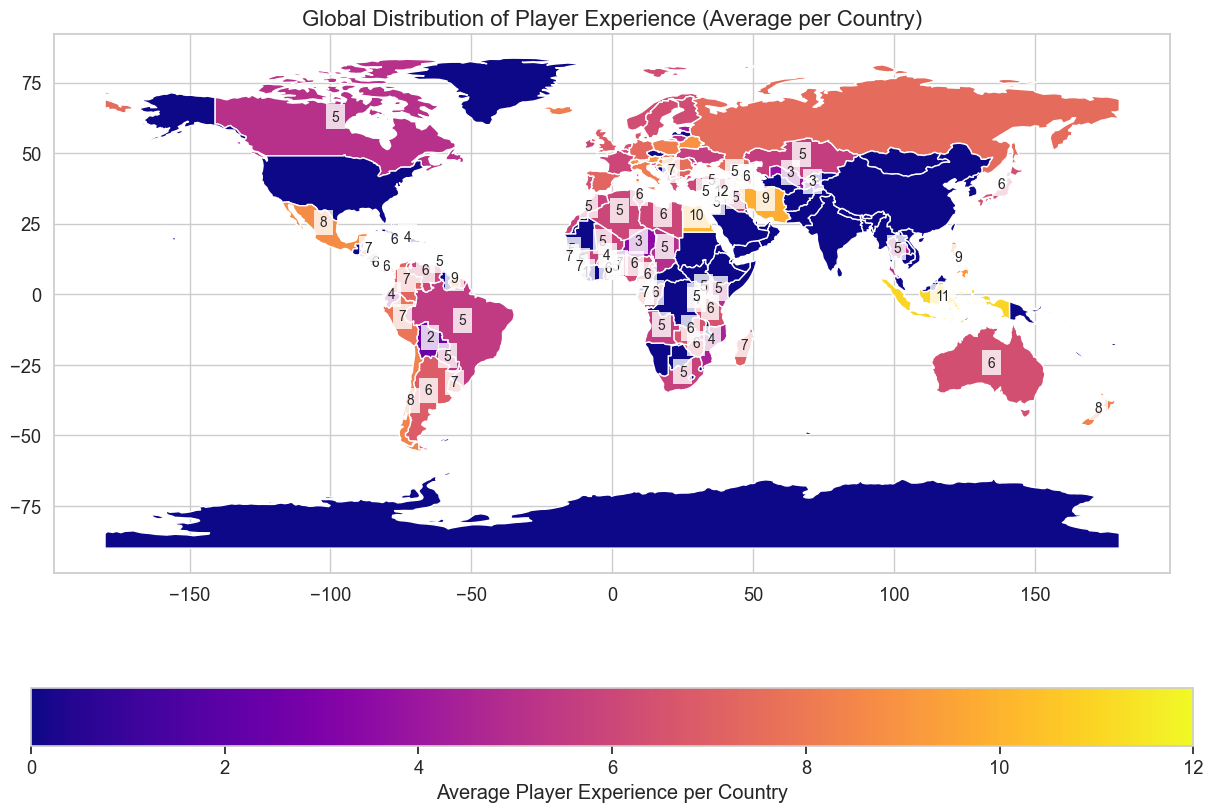

In [41]:
# Calculate the average experience per country
experience_by_nation = players_with_experience.groupby('country_of_citizenship')['experience'].mean().reset_index()

# Merge the geographic data with the average experience
world_with_experience = world_map.merge(experience_by_nation, how="left", left_on="country_of_citizenship", right_on="country_of_citizenship")

# Set NaN values to 0 (for countries without player data)
world_with_experience['experience'] = world_with_experience['experience'].fillna(0)


fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_experience.plot(column='experience', ax=ax, legend=True,legend_kwds={'label': "Average Player Experience per Country", 'orientation': "horizontal"},cmap='plasma')

# Annotate the map with experience values for non-European countries
for idx, row in world_with_experience.iterrows():
    if row['experience'] > 0 and row['continent'] != 'Europe':
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, f"{int(row['experience'])}", fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('Global Distribution of Player Experience (Average per Country)', fontsize=16)
plt.show()

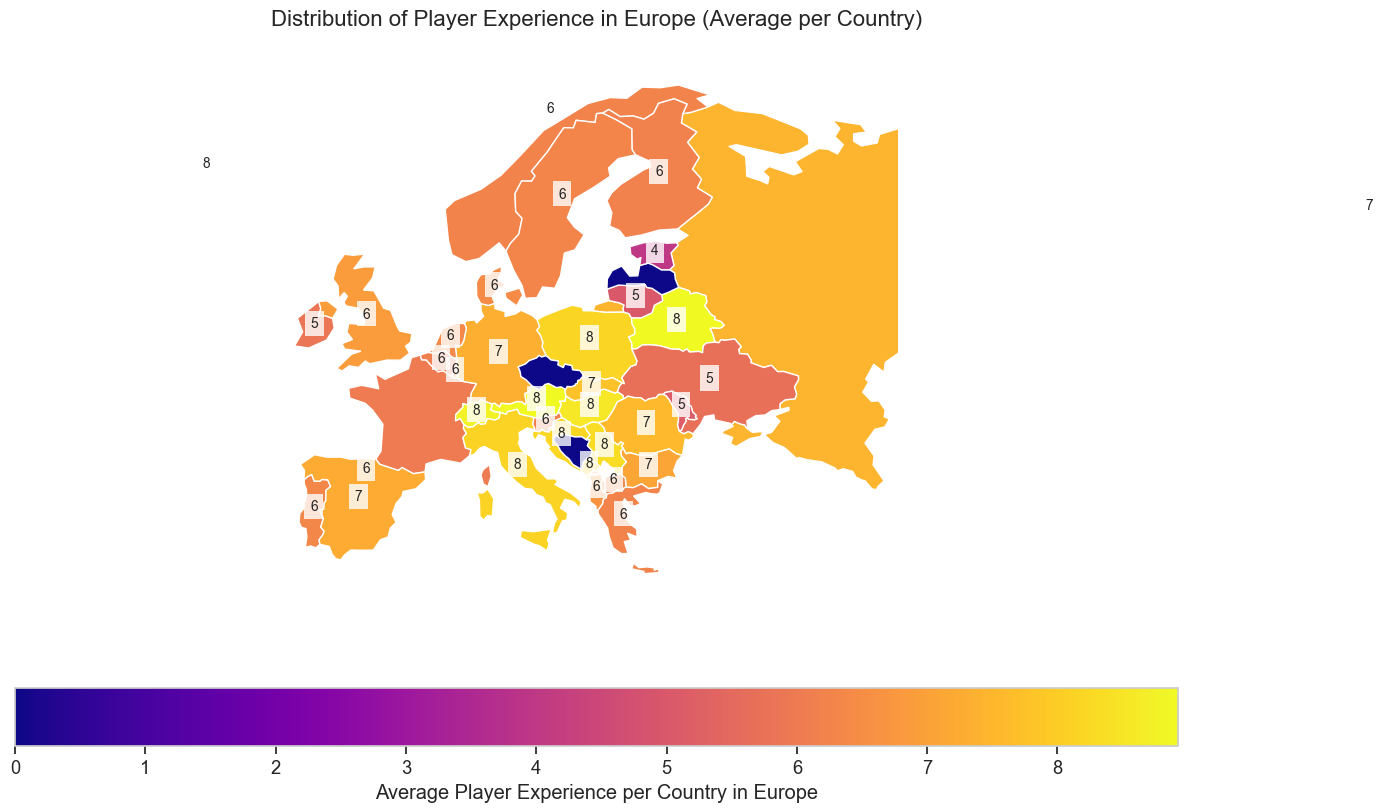

In [42]:
# Filter to include only Europe
europe = world_with_experience[world_with_experience['continent'] == 'Europe']

# Configure the Europe map plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
europe.plot(column='experience', ax=ax, legend=True,legend_kwds={'label': "Average Player Experience per Country in Europe", 'orientation': "horizontal"}, cmap='plasma')

# Annotate the map with experience values for European countries
for idx, row in europe.iterrows():
    if row['experience'] > 0:
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, f"{int(row['experience'])}", fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('Distribution of Player Experience in Europe (Average per Country)', fontsize=16)
# Set the x and y limits to focus on Europe
ax.set_xlim(-10, 50)
ax.set_ylim(35, 75)
ax.set_axis_off()
plt.show()

### 9.2. Qual è la media del valore di mercato dei giocatori con almeno 8 anni di esperienza per nazione?

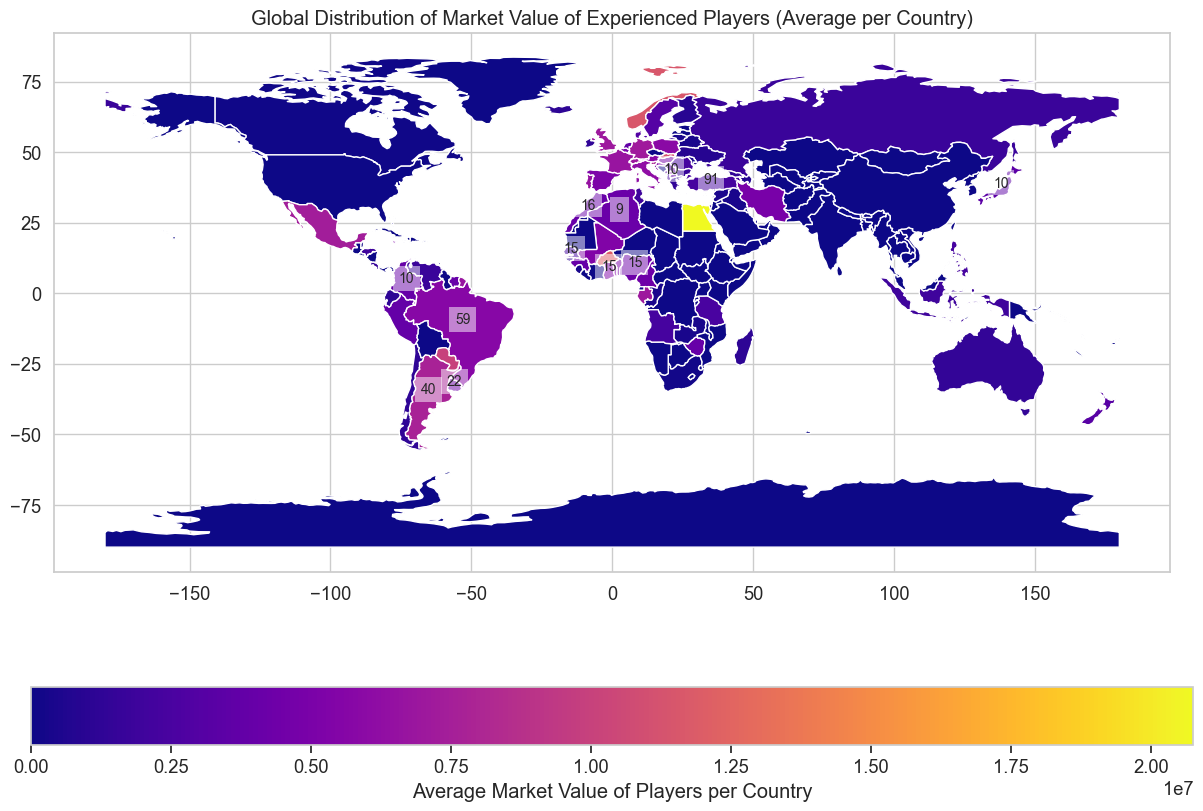

In [43]:
# Filter for experience greater than 8 years
experienced_players = players_with_experience[players_with_experience['experience'] > 8]

# Calculate average market value by nation
market_value_by_nation = experienced_players.groupby('country_of_citizenship')['market_value_in_eur'].mean().reset_index()

# Calculate the number of experienced players by nation
player_count_by_nation = experienced_players.groupby('country_of_citizenship').size().reset_index(name='player_count')

# Merge the geographic data with the average market value
world_with_market_value = world_map.merge(market_value_by_nation, how="left", left_on="country_of_citizenship", right_on="country_of_citizenship")

# Merge the player count data
world_with_market_value = world_with_market_value.merge(player_count_by_nation, how="left", on="country_of_citizenship")

# Set NaN values to 0 (for countries without player data)
world_with_market_value['market_value_in_eur'] = world_with_market_value['market_value_in_eur'].fillna(0)
world_with_market_value['player_count'] = world_with_market_value['player_count'].fillna(0)

# Configure the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_market_value.plot(column='market_value_in_eur', ax=ax, legend=True, legend_kwds={'label': "Average Market Value of Players per Country", 'orientation': "horizontal"}, cmap='plasma')

# Annotate with the number of experienced players
for idx, row in world_with_market_value.iterrows():
    if row['player_count'] > 8 and row['continent'] != 'Europe':
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, f"{int(row['player_count'])}", fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Global Distribution of Market Value of Experienced Players (Average per Country)')
plt.show()

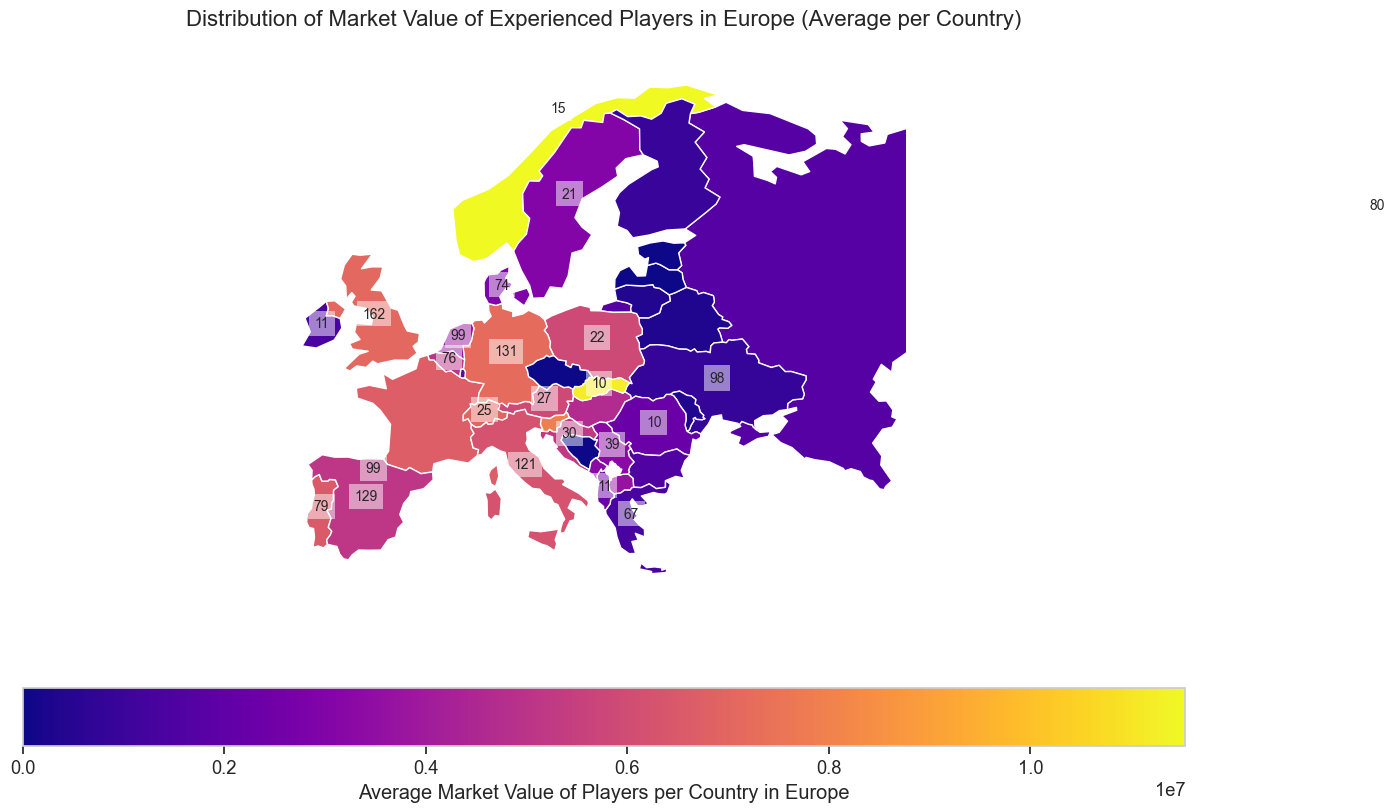

In [45]:
# Filter to include only Europe
europe = world_with_market_value[world_with_market_value['continent'] == 'Europe']

# Configure the Europe map plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

europe.plot(column='market_value_in_eur', ax=ax, legend=True, legend_kwds={'label': "Average Market Value of Players per Country in Europe", 'orientation': "horizontal"}, cmap='plasma')

# Annotate with the number of experienced players
for idx, row in world_with_market_value.iterrows():
    if row['player_count'] > 8 and row['continent'] == 'Europe':
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, f"{int(row['player_count'])}", fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Distribution of Market Value of Experienced Players in Europe (Average per Country)', fontsize=16)
ax.set_xlim(-10, 50)  
ax.set_ylim(35, 75)  
ax.set_axis_off()  
plt.show()

Statisticamente la media globale degli anni di carriera dei calciatori si aggira intorno i 7/8 anni in Europa e 5/6 anni nel resto del mondo. Questo perché il nostro dataset considera solamente le competizioni europee, pertanto ad un giocatore non europeo non vengono considerati gli anni di carriera nelle competizioni extraeuropee. In particolare l'Italia, assieme ad altri paesi come il Regno Unito, la Spagna e la Germania, è tra le nazioni con il numero di giocatori con almeno 8 anni di esperienza più alto. 

## 10. Quali caratteristiche deve avere un capitano?

### 10.1. Qual è la distribuzione dell'età dei capitani?

In [46]:
# Select only the captains from the lineups dataframe
captains_lineups_df = game_lineups_df[game_lineups_df['team_captain'] == 1]

# Specific the relevant columns to include from the players dataframe
relevant_columns = ['player_id', 'date_of_birth', 'country_of_citizenship']

# Merge the filtered captain data with the player data
captains_details_df = pd.merge(captains_lineups_df[['player_id', 'position','game_id']], players_df[relevant_columns], on="player_id", 
    how="left")

# Convert the 'date_of_birth' column to datetime to calculate the age
captains_details_df['date_of_birth'] = pd.to_datetime(captains_details_df['date_of_birth'])

# Merge the captain data with the game dates from 'games_df'
captains_details_df = pd.merge(captains_details_df, games_df[['game_id', 'date']].rename(columns={'date': 'game_date'}),on="game_id", 
    how="left")

# Calculate the age of the captains at the time of the game
captains_details_df['age_at_game'] = captains_details_df['game_date'].apply(lambda x: pd.to_datetime(x).year) - captains_details_df['date_of_birth'].apply(lambda x: pd.to_datetime(x).year)

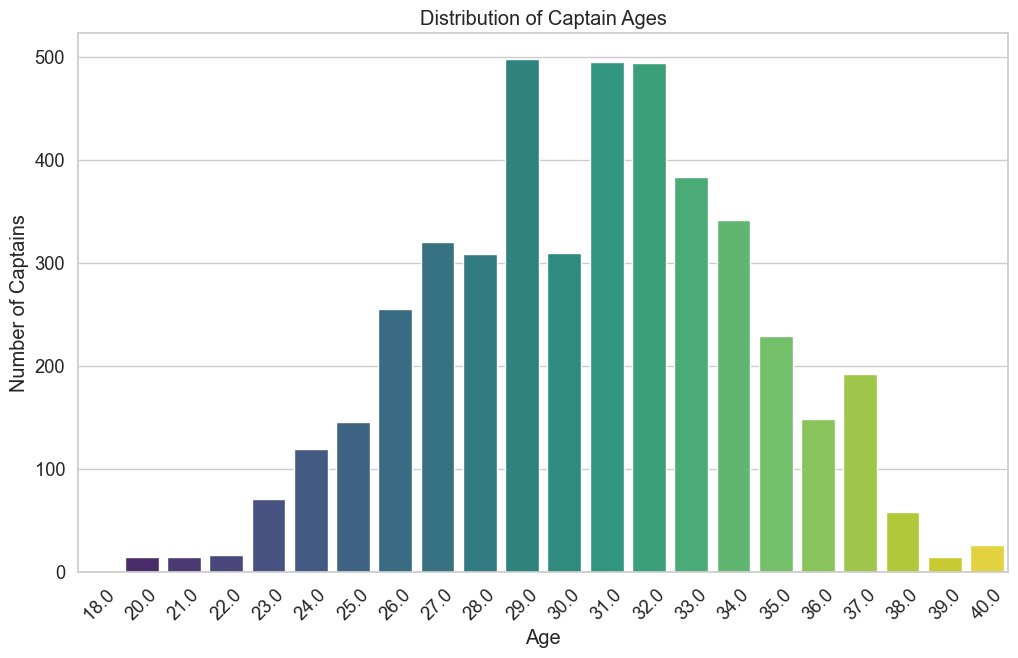

In [47]:
# Calculate the distribution of captain ages
age_distribution = captains_details_df['age_at_game'].value_counts().sort_index()

plt.figure(figsize=(12, 7))
sns.countplot(data=captains_details_df, x='age_at_game', hue='age_at_game', palette='viridis', dodge=False)
plt.title('Distribution of Captain Ages')
plt.xlabel('Age')
plt.ylabel('Number of Captains')
plt.xticks(rotation=45)
plt.legend([], frameon=False)  
plt.show()

### 10.2. Qual è la distribuzione delle posizioni dei capitani?

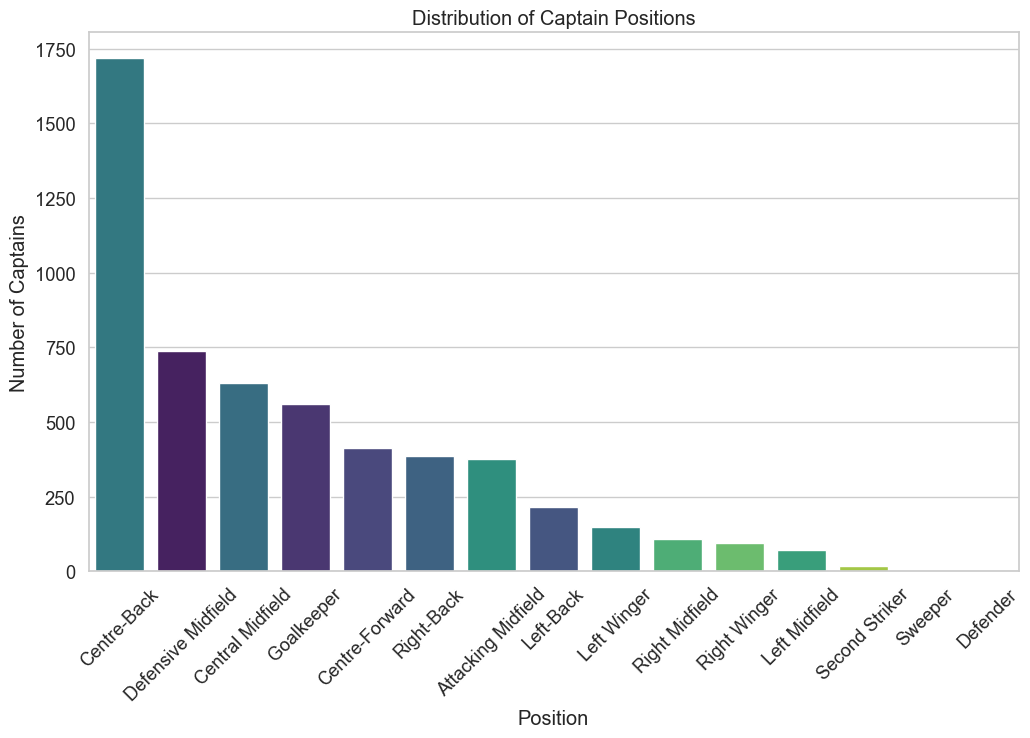

In [48]:
# Calculate the distribution of captain positions
position_distribution = captains_details_df['position'].value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(data=captains_details_df, x='position', hue='position', order= position_distribution,palette='viridis', dodge=False)
plt.title('Distribution of Captain Positions')
plt.xlabel('Position')
plt.ylabel('Number of Captains')
plt.xticks(rotation=45)  
plt.legend([], frameon=False)  
plt.show()

### 10.3. Qual è la distribuzione delle nazionalità dei capitani?

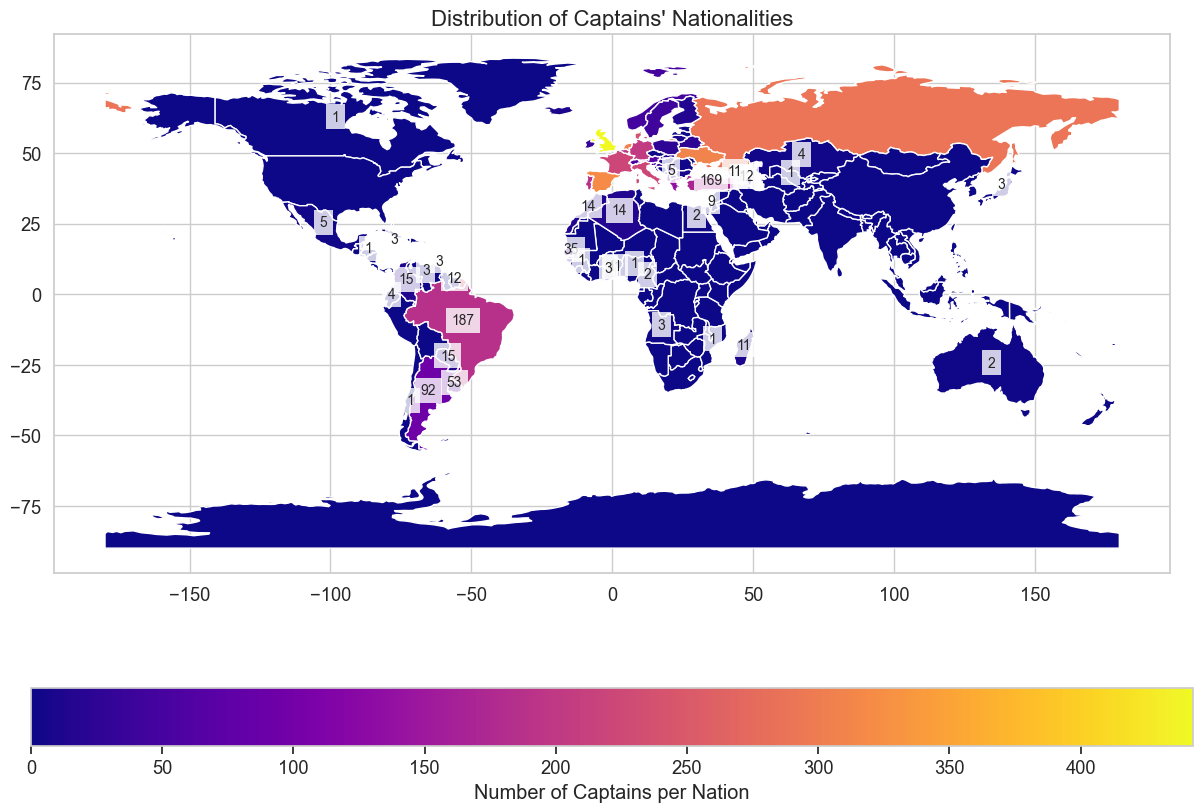

In [49]:
# Calculate the number of captains per nation
captains_by_nation = captains_details_df['country_of_citizenship'].value_counts().reset_index()
captains_by_nation.columns = ['country', 'num_captains']

# Merge the captain count with the world GeoDataFrame
world = world_map.merge(captains_by_nation, how="left", left_on='country_of_citizenship', right_on='country')

# Set NaN values to 0 (for countries without registered captains)
world['num_captains'] = world['num_captains'].fillna(0)

# Plot the global map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

world.plot(column='num_captains', ax=ax, legend=True, legend_kwds={'label': "Number of Captains per Nation", 'orientation': "horizontal"}, cmap='plasma')  

for idx, row in world.iterrows():
    if row['num_captains'] > 0 and row['continent'] != 'Europe': 
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, int(row['num_captains']), fontsize=10, ha='center',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))  

plt.title('Distribution of Captains\' Nationalities', fontsize=16)
plt.show()

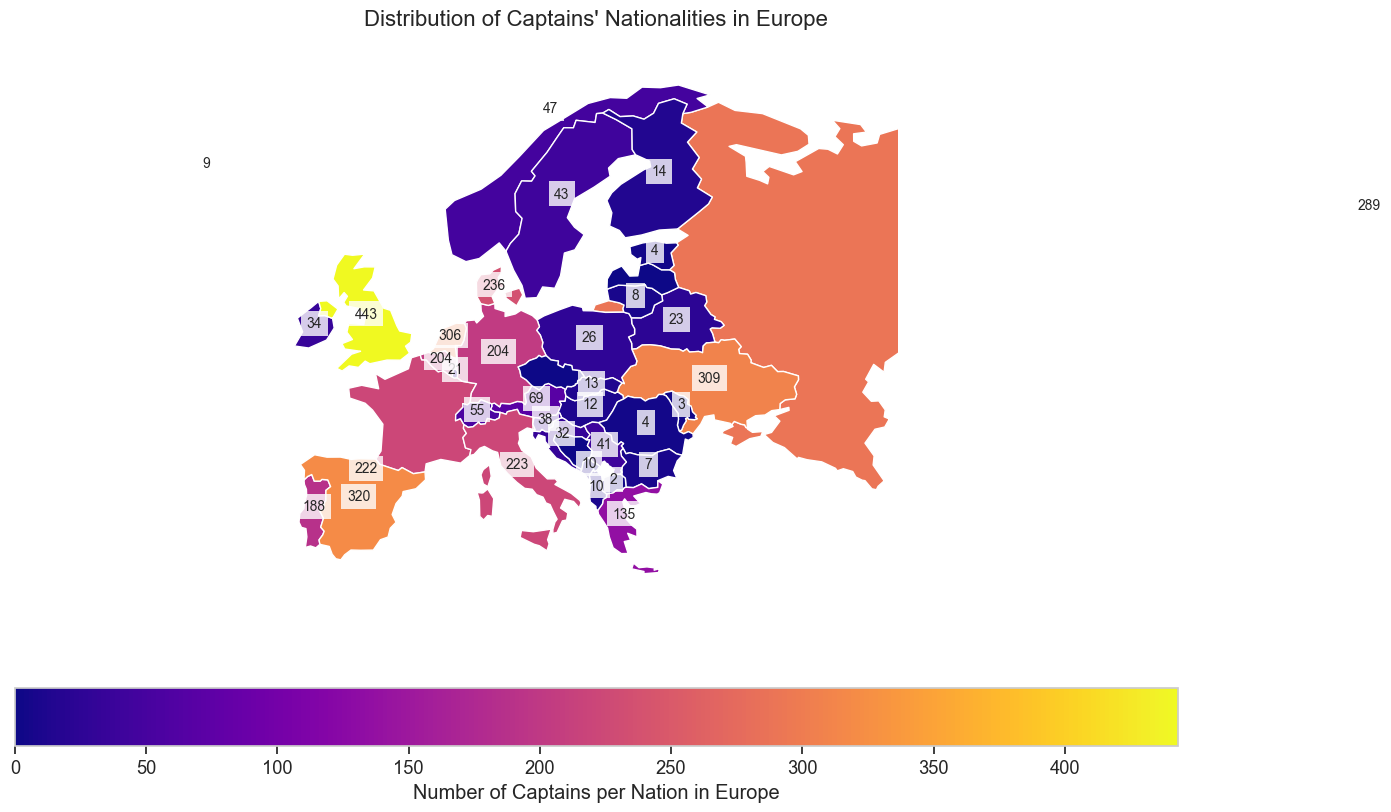

In [50]:
# Filter to include only Europe
europe = world[world['continent'] == 'Europe']

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

europe.plot(column='num_captains', ax=ax, legend=True, legend_kwds={'label': "Number of Captains per Nation in Europe", 'orientation': "horizontal"},
            cmap='plasma')  

for idx, row in europe.iterrows():
    if row['num_captains'] > 0: 
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, int(row['num_captains']), fontsize=10, ha='center',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))  

plt.title('Distribution of Captains\' Nationalities in Europe', fontsize=16)
ax.set_xlim(-10, 50)
ax.set_ylim(35, 75)
ax.set_axis_off()
plt.show()


Dalle statistiche si comprende che l'età media dei capitani si aggira intorno i 29-32 anni. Questo potrebbe essere dovuto al fatto che i capitani sono spesso giocatori esperti e di grande esperienza. Inoltre, la distribuzione delle posizioni dei capitani mostra che i difensori centrali e i centrocampisti centrali sono i più comuni. Questo potrebbe essere dovuto al fatto che questi giocatori sono spesso i leader in campo e sono in grado di vedere l'intero campo e guidare la squadra. Infine, la distribuzione delle nazionalità dei capitani mostra che i paesi con il maggior numero di capitani sono quelli con una lunga tradizione calcistica e una grande presenza di giocatori di alto livello.

## 11. Quanto budget di mercato bisogna riservare per ogni ruolo?

_Nota: nella realtà l'investimento di mercato, ossia a quanto un giocatore viene acquistato, è molto variabile. Non dipende solamente dalla valutazione di mercato del giocatore, ma anche da molti altri fattori come per esempio i vincoli contrattuali, le finanze economiche della squadra che vende o che acquista_

### 11.1. Come si divide il mercato fra i vari ruoli per quanto riguarda le migliori squadre europee dell'ultima stagione?

#### 11.1.1. Quanti giocatori per ruolo ci sono nelle migliori squadre europee dell'ultima stagione?

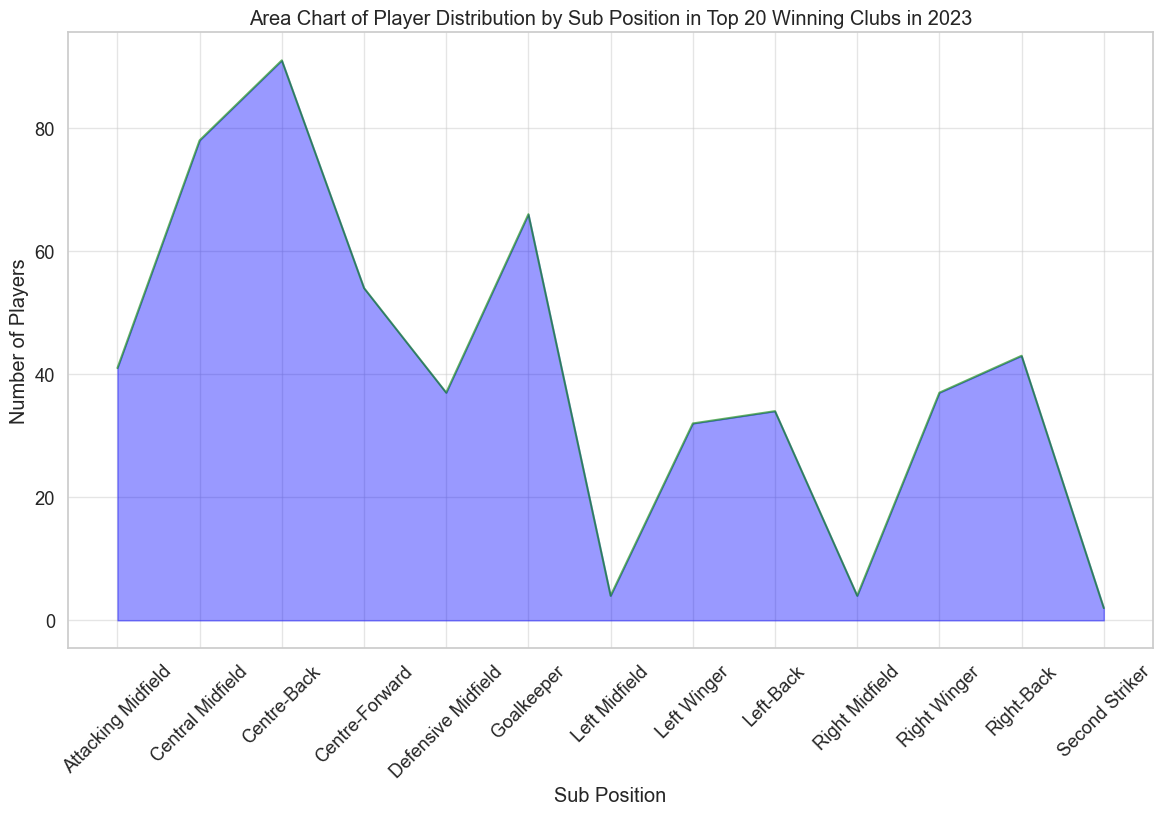

In [51]:
# ID of the top 20 clubs based on the number of wins in the 2023 season
top_20_clubs_2023 = top_20_club_names_2023['club_id'].tolist()

# Filter players based on the top 20 club IDs and the last season
top_players_2023 = players_df[(players_df['current_club_id'].isin(top_20_clubs_2023)) & (players_df['last_season'] == 2023)]

# Grouping players by sub_position and counting
player_count_by_position = top_players_2023.groupby('sub_position').size().reset_index(name='player_count')

plt.figure(figsize=(14, 8))
positions = player_count_by_position['sub_position']
counts = player_count_by_position['player_count']
plt.fill_between(positions, counts, color="blue", alpha=0.4)
plt.plot(positions, counts, color="green", alpha=0.6)
plt.xlabel('Sub Position')
plt.ylabel('Number of Players')
plt.title('Area Chart of Player Distribution by Sub Position in Top 20 Winning Clubs in 2023')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.show()

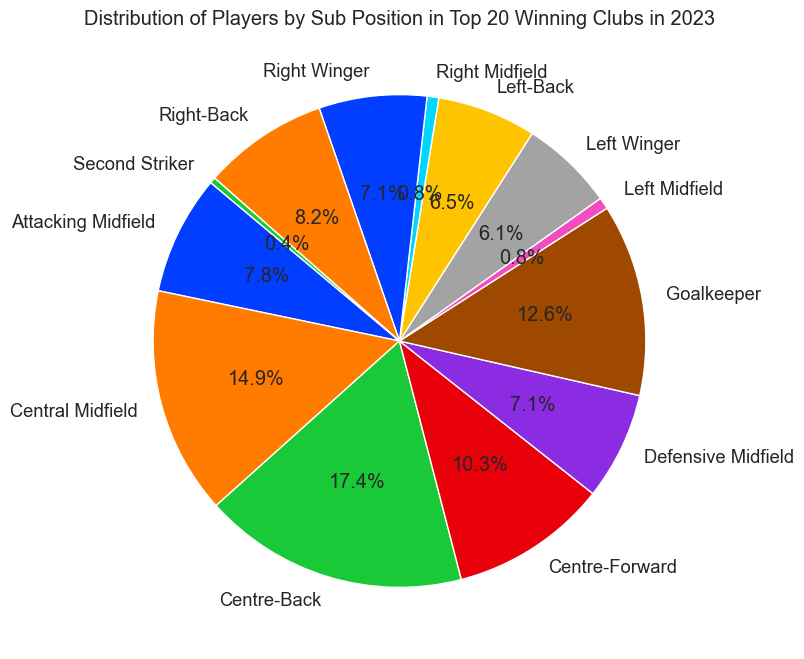

In [52]:
plt.figure(figsize=(10, 8))
plt.pie(player_count_by_position['player_count'], labels=player_count_by_position['sub_position'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Players by Sub Position in Top 20 Winning Clubs in 2023')
plt.show()

#### 11.1.2. Quale è la media di valutazione economica dei giocatori delle migliori squadre europee dell'ultima stagione per ogni ruolo?

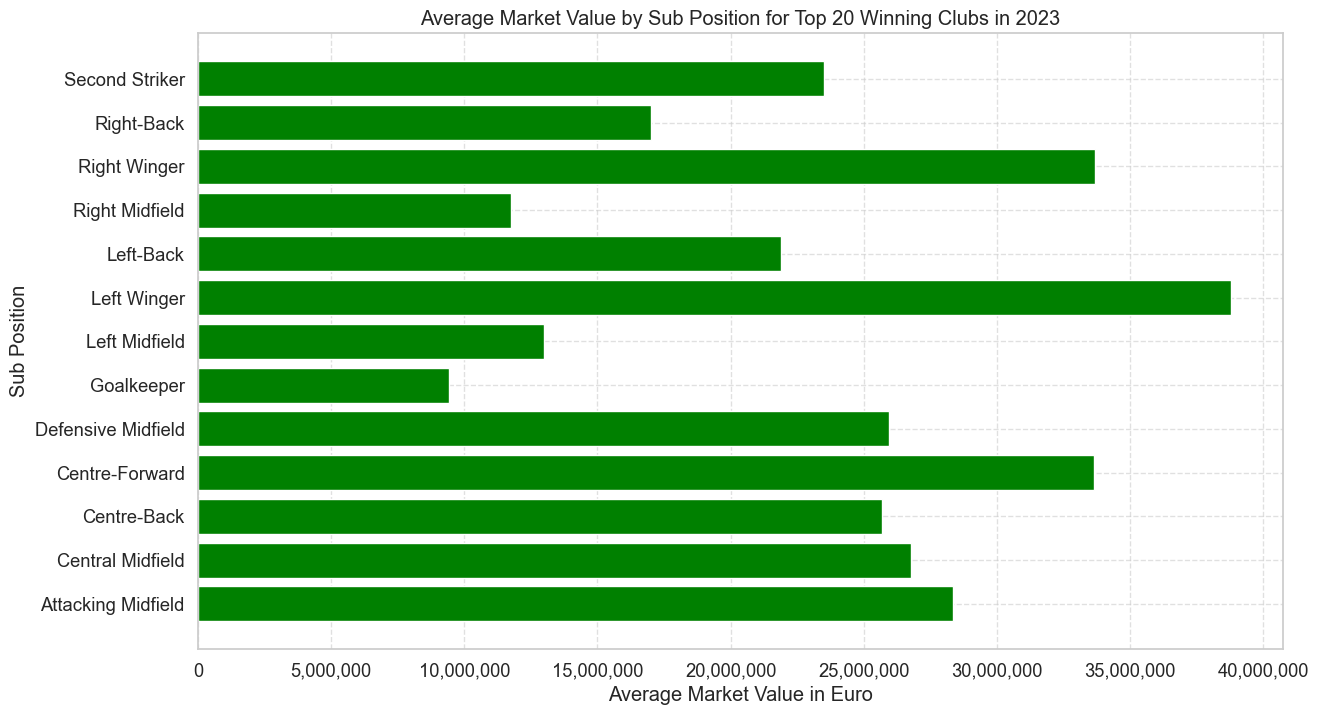

In [53]:
# Calculate the average market value by sub_position for these clubs
average_market_value_by_position_2023 = top_players_2023.groupby('sub_position')['market_value_in_eur'].mean().reset_index()

plt.figure(figsize=(14, 8))
plt.barh(average_market_value_by_position_2023['sub_position'], average_market_value_by_position_2023['market_value_in_eur'], color='green')
plt.title('Average Market Value by Sub Position for Top 20 Winning Clubs in 2023')
plt.xlabel('Average Market Value in Euro')
plt.ylabel('Sub Position')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

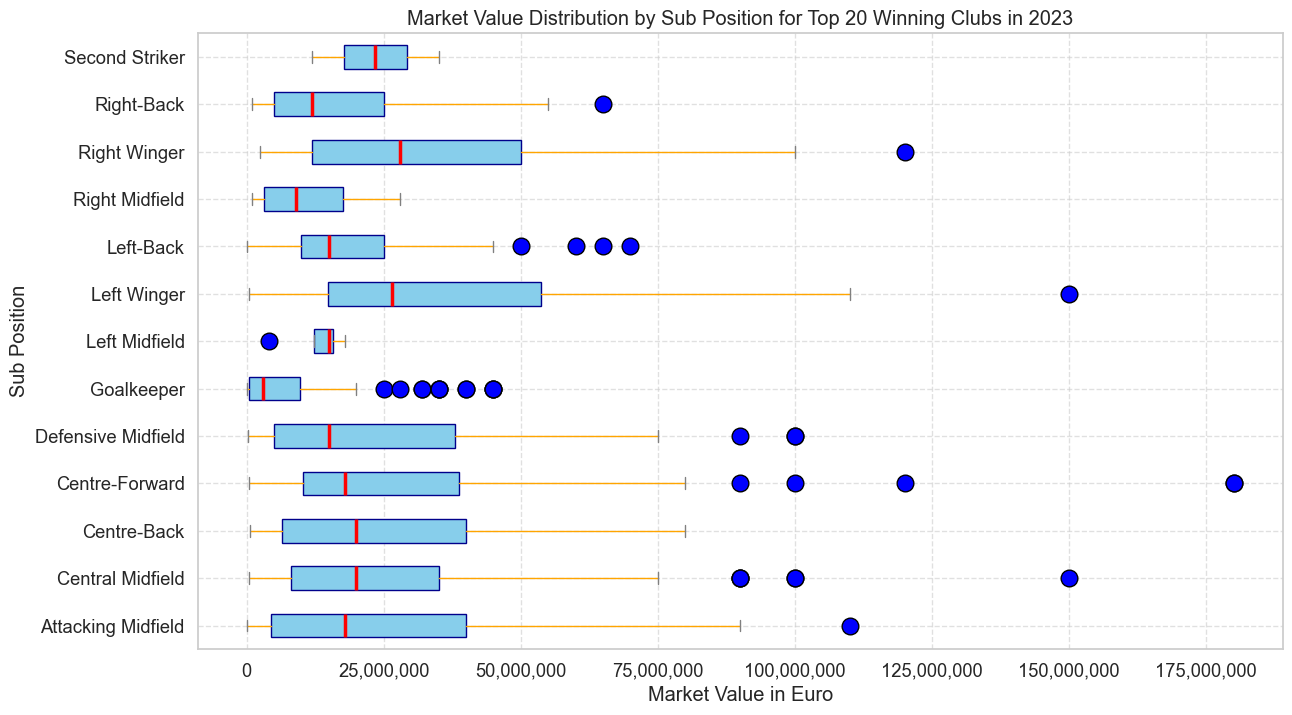

In [54]:
# Group the data by sub_position and collect market values into lists for each sub_position
grouped_market_values = top_players_2023.groupby('sub_position')['market_value_in_eur'].apply(list)

plt.figure(figsize=(14, 8))
plt.boxplot(grouped_market_values.tolist(), vert=False, tick_labels=grouped_market_values.index, patch_artist=True,boxprops=dict(facecolor='skyblue', color='darkblue'),whiskerprops=dict(color='orange'),capprops=dict(color='grey'),medianprops=dict(color='red', linestyle='-', linewidth=2.5),flierprops=dict(marker='o', markerfacecolor='blue', markersize=12, linestyle='none'))
plt.title('Market Value Distribution by Sub Position for Top 20 Winning Clubs in 2023')
plt.xlabel('Market Value in Euro')
plt.ylabel('Sub Position')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 11.1.3. Quale è la percentuale di mercato per ogni ruolo che riservano le migliori squadre europee dell'ultima stagione?

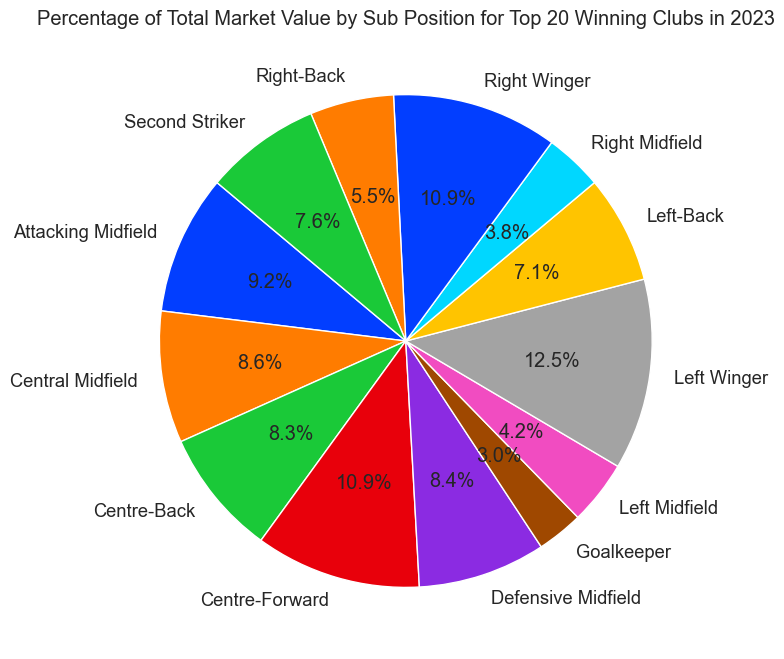

In [55]:
# Calculate the percentage of total market value by sub_position
total_market_value = average_market_value_by_position_2023['market_value_in_eur'].sum()
average_market_value_by_position_2023['percentage'] = (average_market_value_by_position_2023['market_value_in_eur'] / total_market_value) * 100

plt.figure(figsize=(10, 8))
plt.pie(average_market_value_by_position_2023['percentage'], labels=average_market_value_by_position_2023['sub_position'], autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Total Market Value by Sub Position for Top 20 Winning Clubs in 2023')
plt.show()

Dalle statistiche fatte possiamo stimare un prezzo di valutazione per ogni posizione, confrontandoci con la valutazione media delle 20 squadre più vincenti nell'ultima stagione che partecipano alle seguenti competizioni: IT1, ES1, GB1, L1, FR e CH. Come si può notare le posizioni più costose sono quelle di attaccante centrale e centrocampista centrale, mentre le posizioni più economiche sono quelle del portiere e di terzino destro/sinistro.

## 12. Quando è corretto sostituire un giocatore ammonito?

### 12.1. Qual è la probabilità che un giocatore prenda un secondo cartellino giallo dopo aver preso il primo?

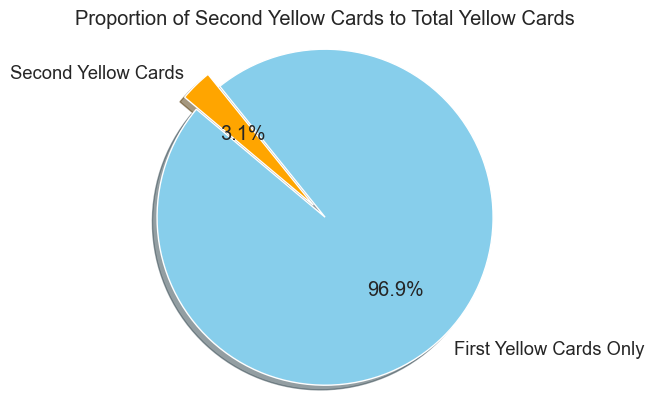

In [56]:
# Filter for yellow cards and second yellow cards, excluding minutes with -1
double_yellow_events = game_events_df[(game_events_df['type'] == 'Cards') & (game_events_df['description'].str.contains("Second yellow")) & (game_events_df['minute'] >= 0)]

first_cards_events = game_events_df[(game_events_df['type'] == 'Cards') & 
(game_events_df['description'].str.contains("Yellow card")) & (game_events_df['minute'] >= 0)]

# Calculating the probability of a player receiving a second yellow card after a first yellow card
total_yellow_cards = len(first_cards_events)
second_yellows = len(double_yellow_events)
probability_second_yellow = (second_yellows / total_yellow_cards * 100) if total_yellow_cards > 0 else 0

# Plotting the proportion of second yellow cards to total yellow cards
labels = ['First Yellow Cards Only', 'Second Yellow Cards']
sizes = [total_yellow_cards - second_yellows, second_yellows]  # Calculating the first yellow cards only, without second yellow cards
colors = ['skyblue', 'orange']
explode = (0, 0.1) # Explode the second slice
fig, ax = plt.subplots()
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
ax.axis('equal') 
plt.title('Proportion of Second Yellow Cards to Total Yellow Cards')
plt.show()

### 12.2. Qual è la distribuzione temporale del primo cartellino giallo e qual è la differenza di tempo tra il primo e il secondo cartellino giallo per i giocatori espulsi?

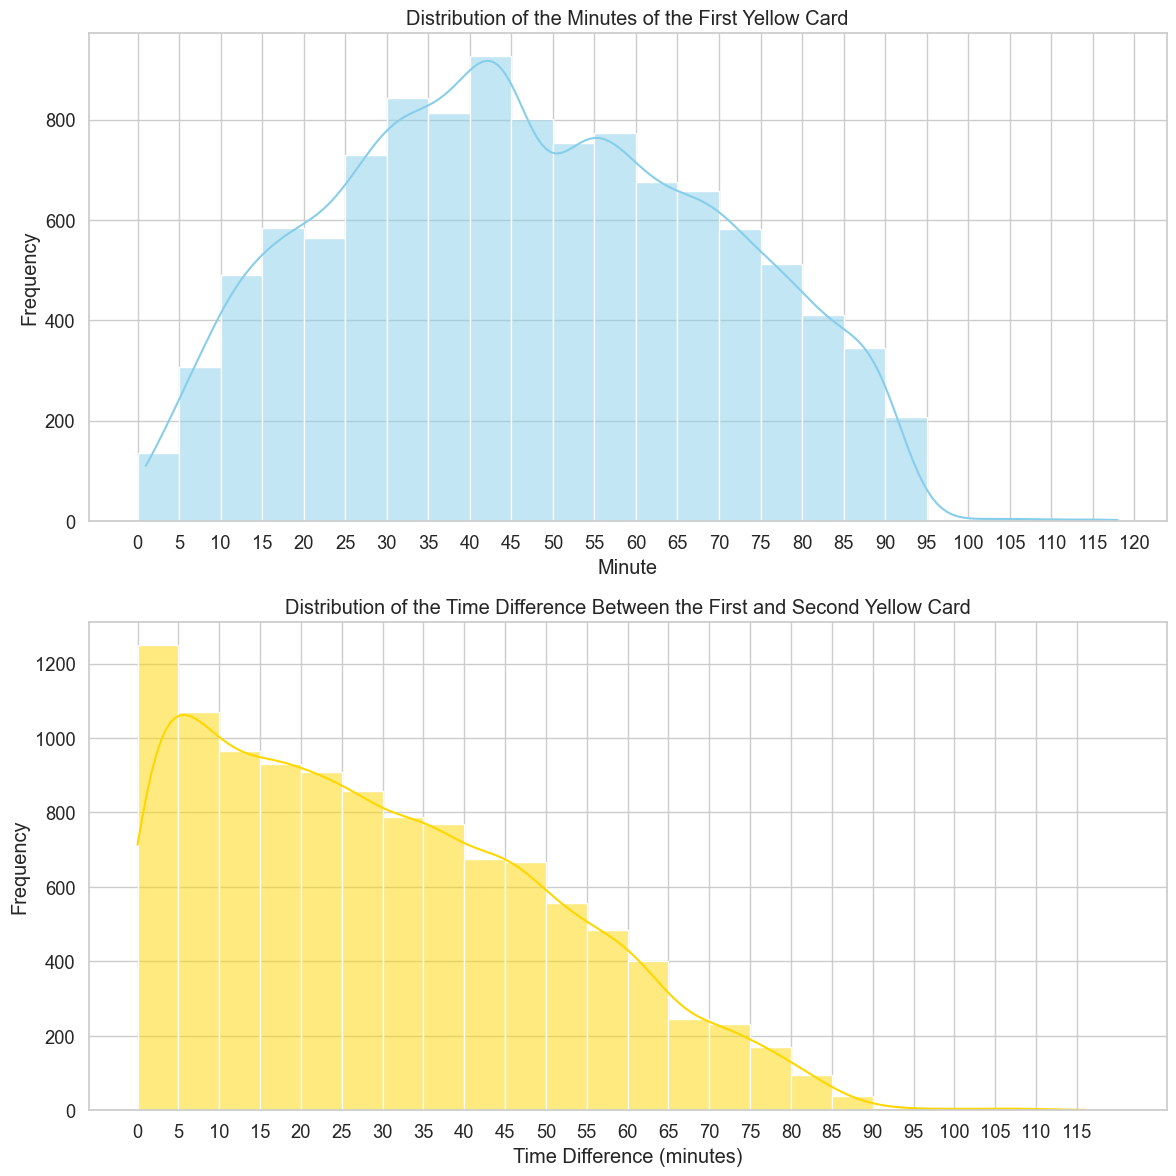

In [57]:
# Extracting data for players with at least one second yellow card
second_yellow_times = double_yellow_events[['player_id', 'minute']]

# Merging data to get the minutes of the first and second yellow cards for sent-off players
yellow_card_times = first_cards_events.merge(second_yellow_times, on='player_id', suffixes=('_first', '_second'))

# Calculating the time difference between the first and second yellow cards
yellow_card_times['time_diff'] = yellow_card_times['minute_second'] - yellow_card_times['minute_first']

# Filtering to ensure the second yellow card occurs after the first
yellow_card_times = yellow_card_times[yellow_card_times['time_diff'] >= 0]

# Visualizing the distribution of the minutes of the first yellow card and the time difference
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

# Distribution of the minutes of the first yellow card
sns.histplot(yellow_card_times['minute_first'], bins=range(0, 120, 5), ax=ax[0], kde=True, color='skyblue')
ax[0].set_title('Distribution of the Minutes of the First Yellow Card')
ax[0].set_xlabel('Minute')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(range(0, 121, 5))

# Distribution of the time difference between the first and second yellow card
max_diff = yellow_card_times['time_diff'].max()
bins_diff = range(0, max_diff + 5, 5)  # Ensuring the range covers the maximum
sns.histplot(yellow_card_times['time_diff'], bins=bins_diff, ax=ax[1], kde=True, color='gold')
ax[1].set_title('Distribution of the Time Difference Between the First and Second Yellow Card')
ax[1].set_xlabel('Time Difference (minutes)')
ax[1].set_ylabel('Frequency')
ax[1].set_xticks(range(0, max_diff + 1, 5))

plt.tight_layout()
plt.show()

### 12.3. A che minuto statisticamente è più probabile che un giocatore riceva il primo cartellino giallo? Che età e che ruolo hanno i giocatori che ricevono il primo cartellino giallo?

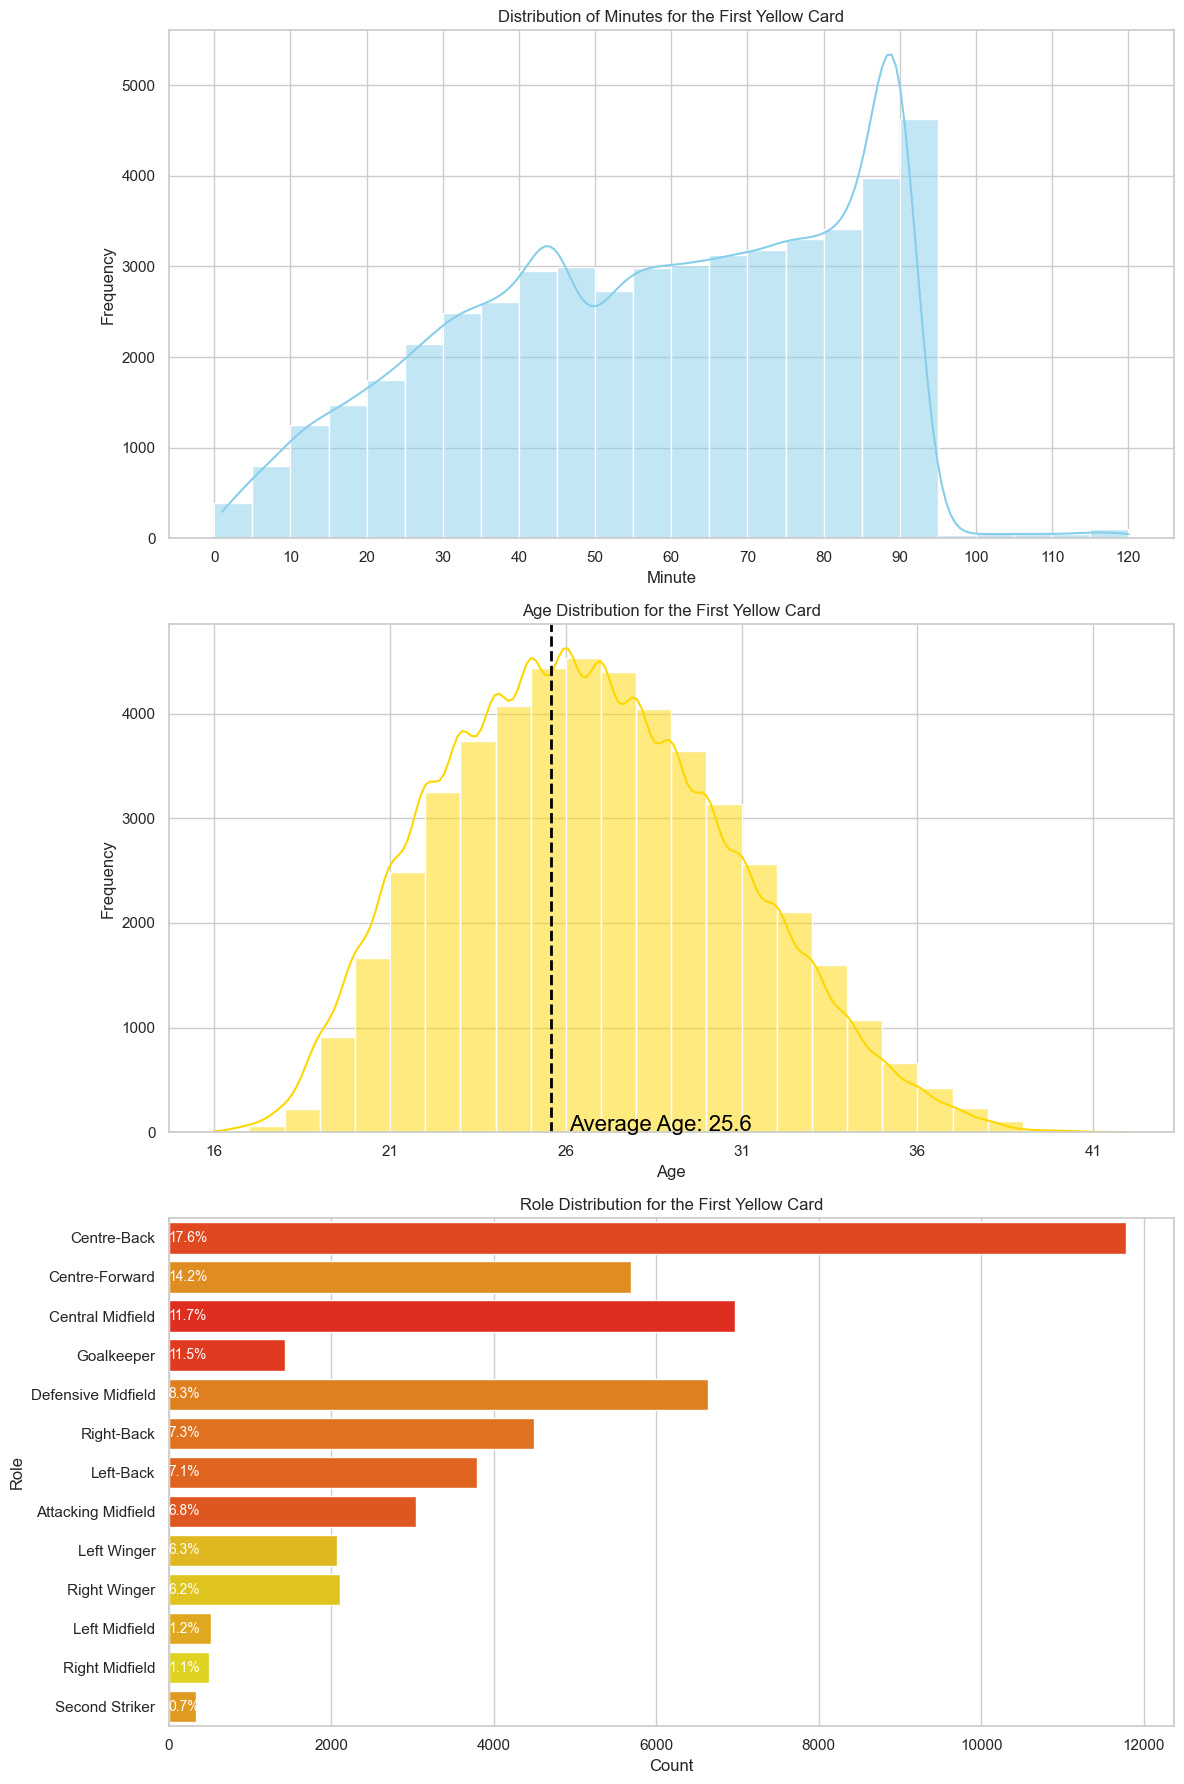

In [58]:
# Extracting player_ids who received a yellow card
first_yellow_player_ids = first_cards_events['player_id'].unique()

# Retrieving information of players who received a yellow card
players_with_first_yellow = players_df[players_df['player_id'].isin(first_yellow_player_ids)]

# Merging player data with yellow card events to get complete information
first_yellow_details = first_cards_events.merge(players_with_first_yellow, on='player_id')

# Calculating the age at the time of the event
first_yellow_details['age'] = pd.to_datetime(first_yellow_details['date']).dt.year - pd.to_datetime(first_yellow_details['date_of_birth']).dt.year

# Aggregating to count the number of yellow cards per player
first_yellow_count = first_yellow_details.groupby(['player_id', 'name', 'age', 'country_of_citizenship', 'sub_position']).size().reset_index(name='count')

# Calculating the average age of players active in 2023
current_year = 2023
players_active_in_2023 = players_df[players_df['last_season'] == 2023]
average_age_active_players = (current_year - pd.to_datetime(players_active_in_2023['date_of_birth']).dt.year).mean()

# Setting the visual theme
sns.set(style="whitegrid")

# Creating plots for pattern analysis
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plotting the distribution of yellow card minutes
sns.histplot(first_yellow_details['minute'], bins=range(0, 121, 5), ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Distribution of Minutes for the First Yellow Card')
axes[0].set_xlabel('Minute')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(0, 121, 10))  # Labels every 10 minutes

# Plotting the age distribution
sns.histplot(first_yellow_details['age'].dropna(), bins=range(int(first_yellow_details['age'].min()), int(first_yellow_details['age'].max()) + 1), ax=axes[1], kde=True, color='gold')
axes[1].set_title('Age Distribution for the First Yellow Card')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=average_age_active_players, color='black', linestyle='--', linewidth=2)
axes[1].text(average_age_active_players + 0.5, 10, f'Average Age: {average_age_active_players:.1f}', color='black', fontsize=16)
axes[1].set_xticks(range(int(first_yellow_details['age'].min()), int(first_yellow_details['age'].max()) + 1, 5))  # Labels every 5 years

# Plotting the role distribution
first_yellow_details = first_yellow_details[first_yellow_details['sub_position'] != 'unknown']
# Calculating the total number of players excluding 'unknown'
total_players = len(players_df[players_df['sub_position'] != 'unknown'])
# Counting the number of players for each 'sub_position', excluding 'unknown'
players_per_role = players_df[players_df['sub_position'] != 'unknown']['sub_position'].value_counts()
# Calculating the percentage of players for each 'sub_position'
percentage_per_role = (players_per_role / total_players * 100)

# Ordering positions based on the percentage of players for each role
position_order = percentage_per_role.index

sns.countplot(data=first_yellow_details, y='sub_position', ax=axes[2], hue='sub_position', order=position_order,
              dodge=False, palette='autumn', legend=False)
axes[2].set_title('Role Distribution for the First Yellow Card')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Role')

# Adding percentage labels to the plot
for i, label in enumerate(position_order):
    if label in percentage_per_role:
        percentage = percentage_per_role[label]
        axes[2].text(0, i, f'{percentage:.1f}%', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

_NOTA: la percentuale nel grafico rappresenta la percentuale di giocatori in ciascun ruolo rispetto al totale dei giocatori conosciuti, escludendo quelli con ruolo sconosciuto_

### 12.4. A che minuto statisticamente è più probabile che un giocatore riceva il secondo cartellino giallo? Che età e che ruolo hanno i giocatori che ricevono il secondo cartellino giallo?

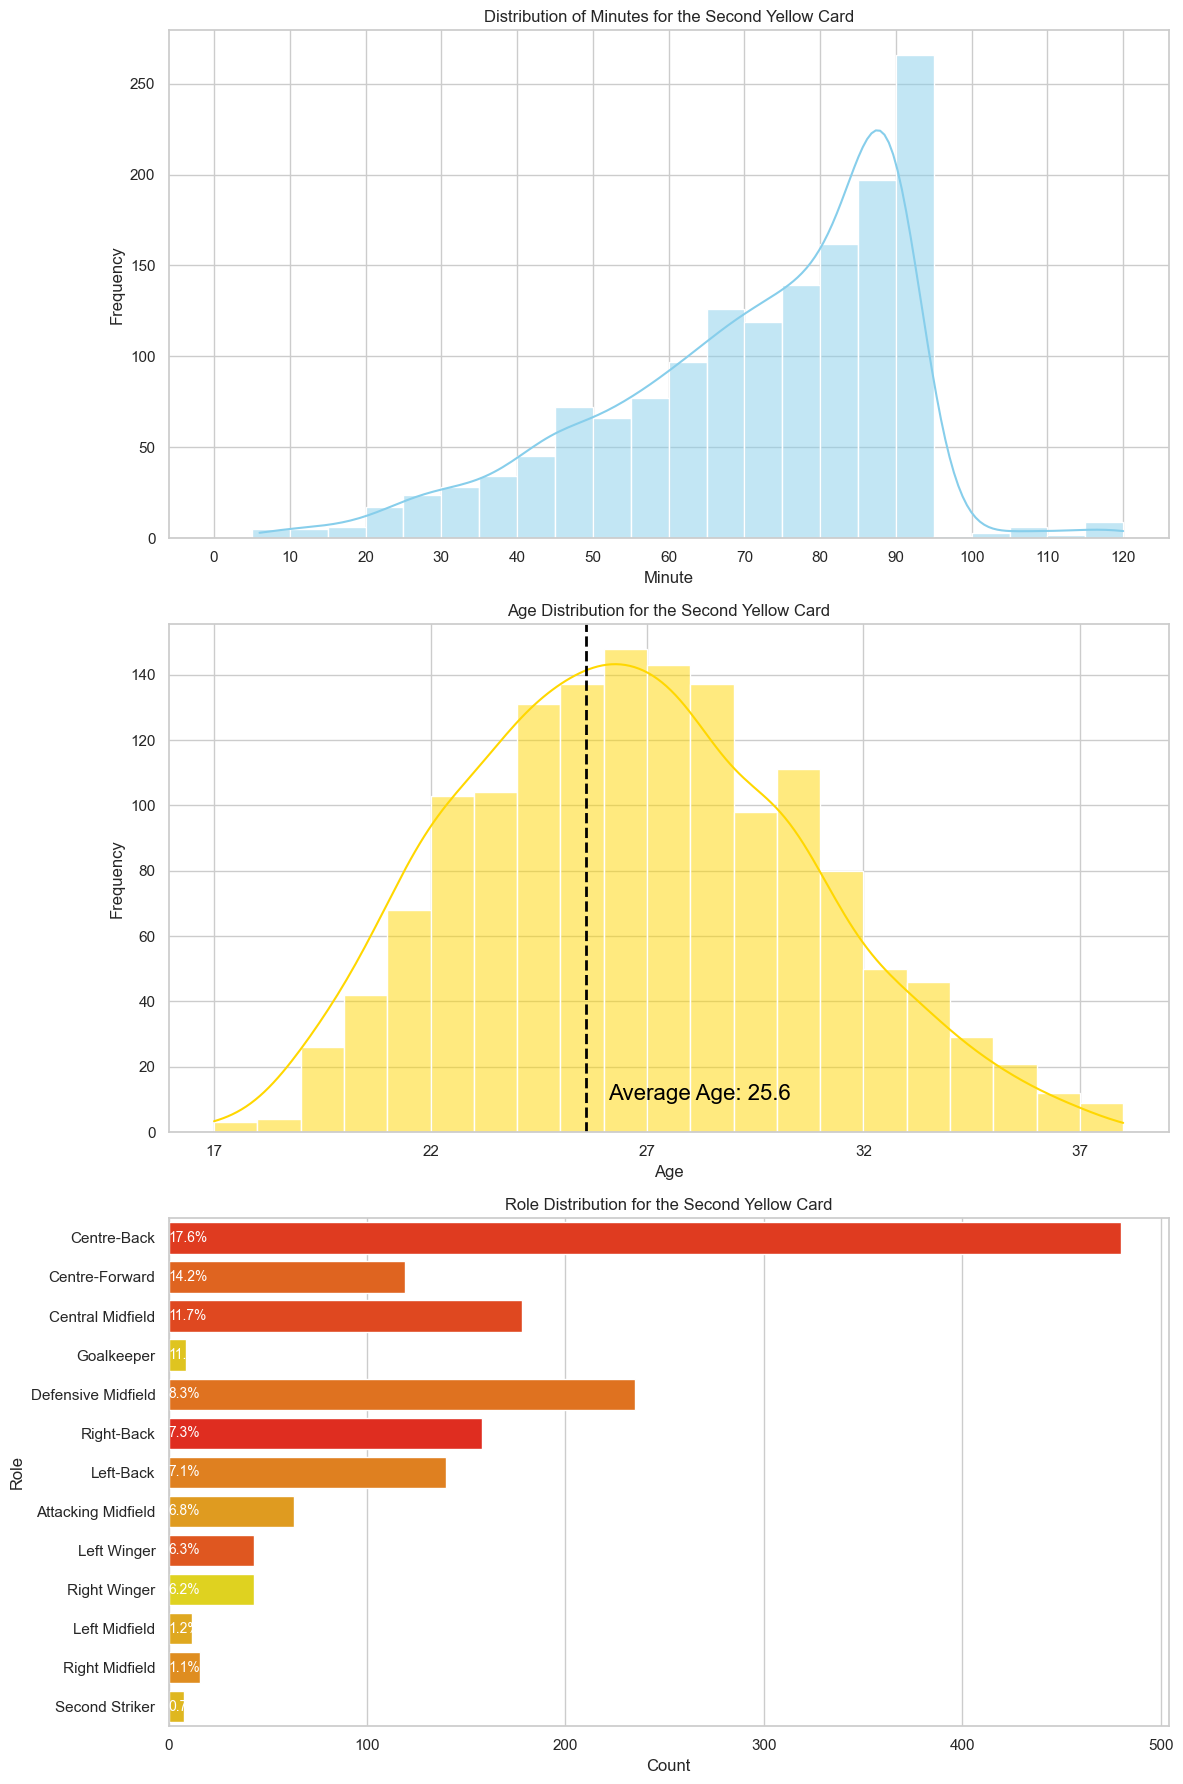

In [61]:
# Extracting player_ids from double yellow cards
double_yellow_player_ids = double_yellow_events['player_id'].unique()

# Retrieving information of players who received a second yellow card
players_with_double_yellow = players_df[players_df['player_id'].isin(double_yellow_player_ids)]

# Merging player data with second yellow card events to get complete information
double_yellow_details = double_yellow_events.merge(players_with_double_yellow, on='player_id')

# Calculating the age at the time of the event
double_yellow_details['age'] = pd.to_datetime(double_yellow_details['date']).dt.year - pd.to_datetime(double_yellow_details['date_of_birth']).dt.year

# Aggregating to count the number of expulsions per player
double_yellow_count = double_yellow_details.groupby(['player_id', 'name', 'age', 'country_of_citizenship', 'sub_position']).size().reset_index(name='count')

# Setting the visual theme
sns.set(style="whitegrid")

# Creating plots for pattern analysis
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plotting the distribution of second yellow card minutes
sns.histplot(double_yellow_details['minute'], bins=range(0, 121, 5), ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Distribution of Minutes for the Second Yellow Card')
axes[0].set_xlabel('Minute')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(0, 121, 10))  # Labels every 10 minutes

# Plotting the age distribution
sns.histplot(double_yellow_details['age'].dropna(), bins=range(int(double_yellow_details['age'].min()), int(double_yellow_details['age'].max()) + 1), ax=axes[1], kde=True, color='gold')
axes[1].set_title('Age Distribution for the Second Yellow Card')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=average_age_active_players, color='black', linestyle='--', linewidth=2)
axes[1].text(average_age_active_players + 0.5, 10, f'Average Age: {average_age_active_players:.1f}', color='black', fontsize=16)
axes[1].set_xticks(range(int(double_yellow_details['age'].min()), int(double_yellow_details['age'].max()) + 1, 5))  # Labels every 5 years

# Plotting the role distribution
double_yellow_details = double_yellow_details[double_yellow_details['sub_position'] != 'unknown']

sns.countplot(data=double_yellow_details, y='sub_position', ax=axes[2], hue='sub_position', order=position_order,
              dodge=False, palette='autumn', legend=False)
axes[2].set_title('Role Distribution for the Second Yellow Card')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Role')

# Adding percentage labels to the plot
for i, label in enumerate(position_order):
    if label in percentage_per_role:
        percentage = percentage_per_role[label]
        axes[2].text(0, i, f'{percentage:.1f}%', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

_NOTA: la percentuale nel grafico rappresenta la percentuale di giocatori in ciascun ruolo rispetto al totale dei giocatori conosciuti, escludendo quelli con ruolo sconosciuto_

### 12.5. Qual è la distribuzione mondiale ed europea delle ammonizioni per nazionalità?

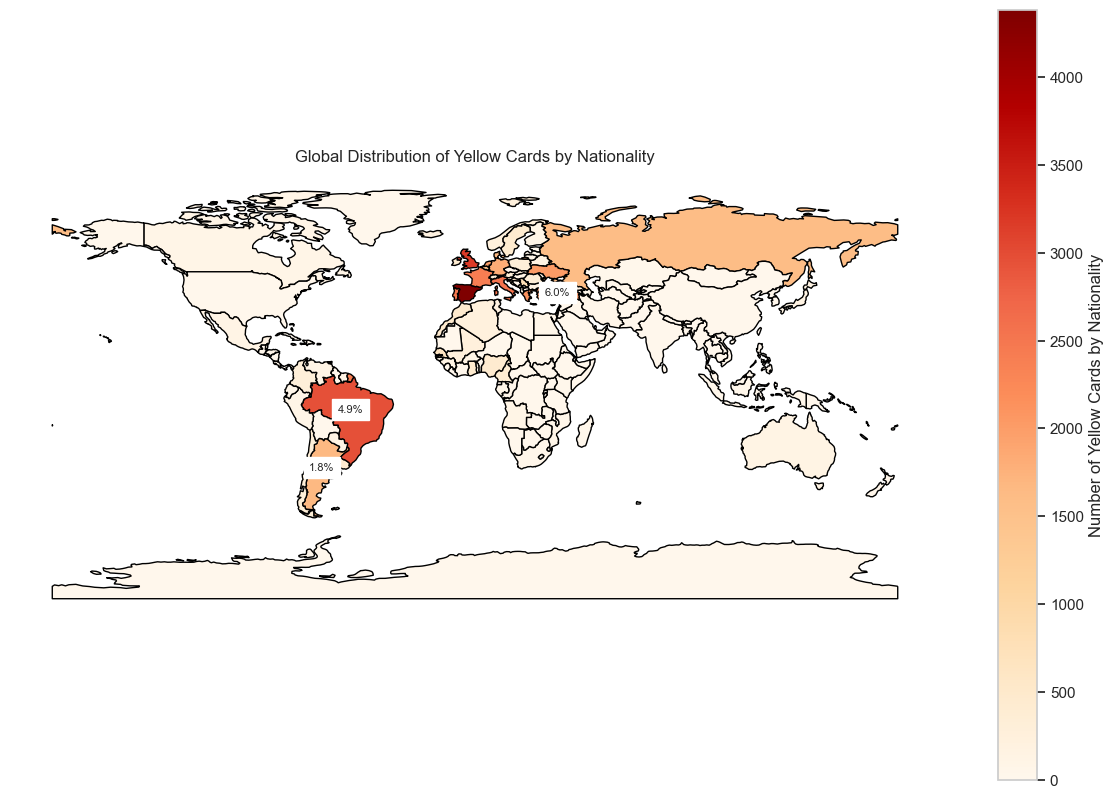

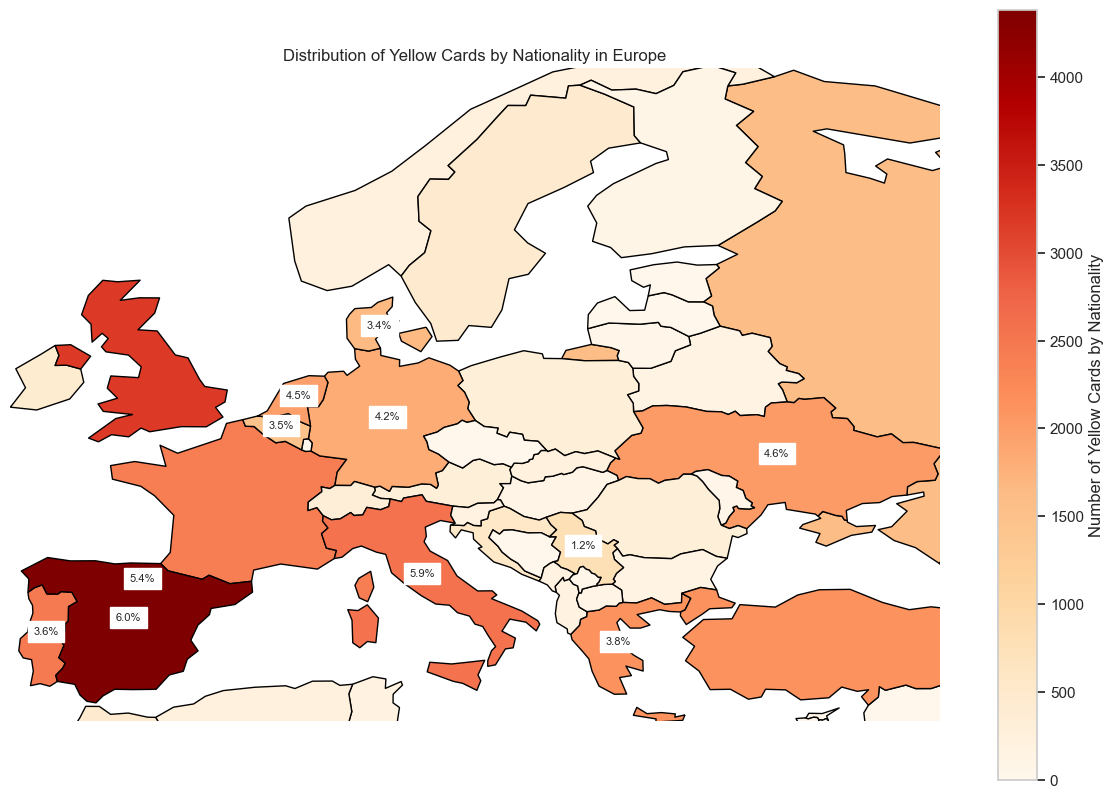

In [64]:
# Aggregating data by nationality with the count of yellow cards
nationality_first_yellow = first_yellow_count.groupby('country_of_citizenship')['count'].sum().reset_index()
nationality_first_yellow.columns = ['country_of_citizenship', 'yellow card']

# Merging the count of yellow cards by nationality with the world map
world_with_yellow_cards = world_map.merge(nationality_first_yellow, how='left', on='country_of_citizenship')
world_with_yellow_cards['yellow card'] = world_with_yellow_cards['yellow card'].fillna(0)


fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_yellow_cards.plot(column='yellow card', ax=ax, legend=True,legend_kwds={'label': "Number of Yellow Cards by Nationality"}, cmap='OrRd', edgecolor='black')
ax.set_title('Global Distribution of Yellow Cards by Nationality')

# Annotate the percentage of players on the map
for idx, row in world_filtered.iterrows():
    ax.annotate(f"{row['percentage_of_players']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=8, backgroundcolor="white")
    
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_yellow_cards.plot(column='yellow card', ax=ax, legend=True,legend_kwds={'label': "Number of Yellow Cards by Nationality"},cmap='OrRd', edgecolor='black')
ax.set_title('Distribution of Yellow Cards by Nationality in Europe')

# Annotate the percentage of players on the map
for idx, row in europe_filtered.iterrows():
    ax.annotate(f"{row['percentage_of_players']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=8, backgroundcolor="white")
    
ax.set_xlim(-10, 40)  
ax.set_ylim(35, 70)  
ax.set_axis_off()
plt.show()

### 12.5. Qual è la distribuzione mondiale ed europea delle espulsioni per nazionalità?

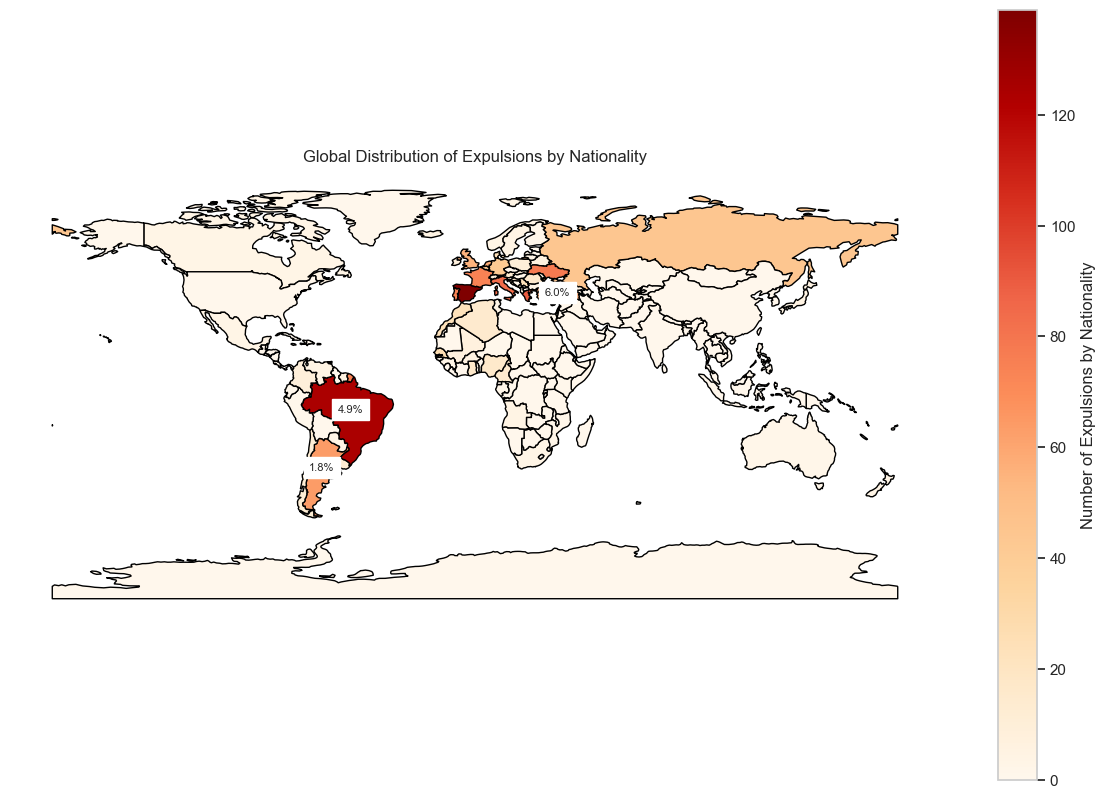

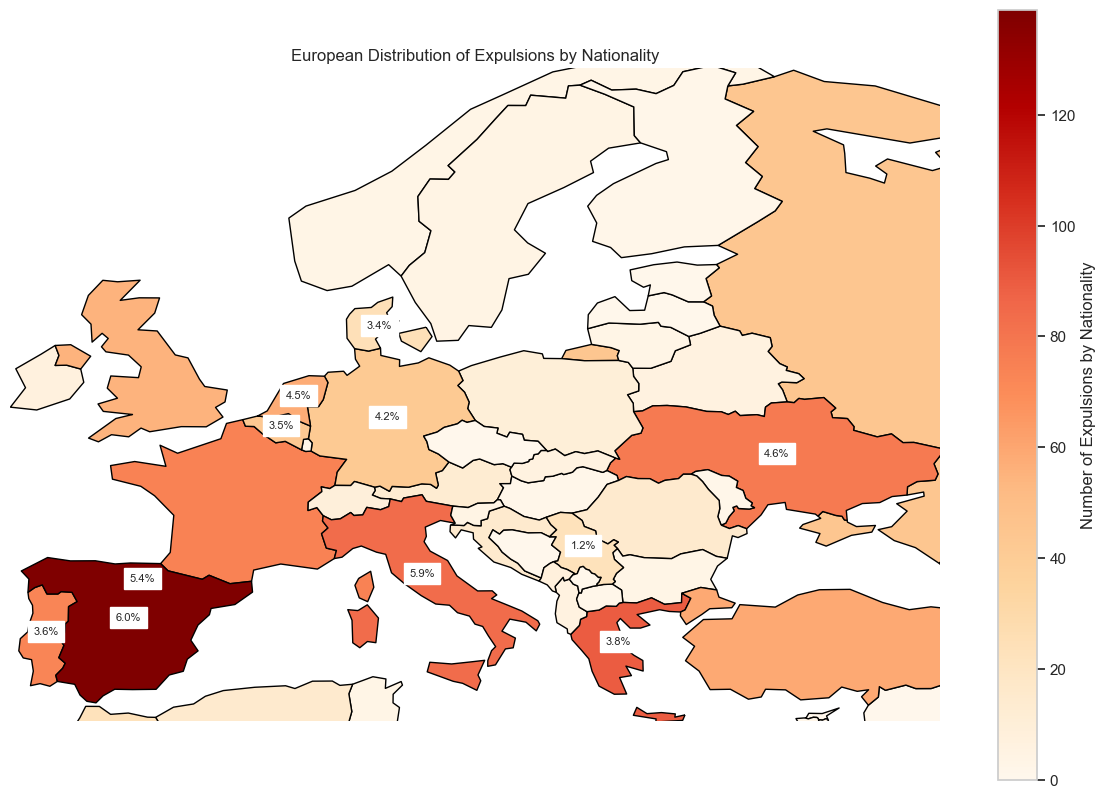

In [65]:
nationality_double_yellow = double_yellow_count.groupby('country_of_citizenship')['count'].sum().reset_index()
nationality_double_yellow.columns = ['country_of_citizenship', 'expulsions']

world_with_expulsions = world_map.merge(nationality_double_yellow, how='left', on='country_of_citizenship')
world_with_expulsions['expulsions'] = world_with_expulsions['expulsions'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_expulsions.plot(column='expulsions', ax=ax, legend=True,legend_kwds={'label': "Number of Expulsions by Nationality"},cmap='OrRd', edgecolor='black')
ax.set_title('Global Distribution of Expulsions by Nationality')

# Annotate the percentage of players on the map
for idx, row in world_filtered.iterrows():
    ax.annotate(f"{row['percentage_of_players']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),ha='center', fontsize=8, backgroundcolor="white")
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_expulsions.plot(column='expulsions', ax=ax, legend=True,legend_kwds={'label': "Number of Expulsions by Nationality"}, cmap='OrRd', edgecolor='black')
ax.set_title('European Distribution of Expulsions by Nationality')

# Annotate the percentage of players on the map
for idx, row in europe_filtered.iterrows():
    ax.annotate(f"{row['percentage_of_players']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=8, backgroundcolor="white")
    
ax.set_xlim(-10, 40)  
ax.set_ylim(35, 70)  
ax.set_axis_off()
plt.show()

- Statisticamente il minuto in cui si prende più volte il primo cartellino giallo, per i giocatori che verranno successivamente espulsi per doppia ammonizione, è il 45' minuto. Questo avviene anche perché si considera il recupero del primo tempo nel minuto 45. 
- Basandoci sulle informazioni ottenute, un approccio prudente potrebbe essere quello di considerare la sostituzione di un giocatore ammonito, soprattutto se ha ricevuto il primo giallo entro i primi 30 minuti della partita e se è noto per essere un giocatore più aggressivo o se la partita è particolarmente tesa. La maggior parte delle secondarie ammonizioni avviene entro 40 minuti dal primo cartellino giallo, con la frequenza più alta intorno ai 20 minuti. Questo suggerisce che il periodo di tempo più critico dopo un primo cartellino giallo è tra i 15 e i 40 minuti successivi.
- Statisticamente un giocatore riceve il suo primo cartellino giallo o il suo secondo cartellino giallo negli ultimi 20 minuti di partita, con un picco sul 90' minuto a causa del recupero. 
- Sia per il primo che per il secondo cartellino giallo l'età media è di circa 26/27 anni che si avvicina molto alla media totale dei giocatori (25.6). 
- Analogamente i ruoli più predisposti a prendere il primo o il secondo giallo sono quelli più difensivi, come ad esempio il centrale di difesa.  
- Si noti come la Spagna sia la nazione che ha più giocatori che hanno preso più ammonizioni e più espulsioni a causa di un doppio giallo.   

## 13. Come varia la valutazione economica dei giocatori in base alla nazionalità? 

_Nota 1: la valutazione è stata fatta considerando solamente le squadre che partecipano ai campionati IT1, GB1, ES1, L1, FR1 e CH._

_Nota 2: la percentuale (>0.1%) mostrata nei grafici geografici rappresenta il numero di giocatori totali che hanno partecipato ai campionati sopra menzionati_

### 13.1. A quale età i giocatori raggiungono la loro prima valutazione economica?

In [75]:
player_valuations_df['date'] = pd.to_datetime(player_valuations_df['date'])
players_df['date_of_birth'] = pd.to_datetime(players_df['date_of_birth'])

# Filter the dataframe to include only players in competitions IT1, GB1, ES1, L1, FR1 and CH
valuations_df = player_valuations_df[player_valuations_df['player_club_domestic_competition_id'].isin(competitions)]

# Sort valuations by player_id and date to ensure we can find peaks correctly
valuations_df = valuations_df.sort_values(by=['player_id', 'date'])

# Identify the first valuation entry for each player
first_valuation_df = valuations_df.groupby('player_id').first().reset_index()

# Merge with players data to get the birth date and country
first_valuation_df = first_valuation_df.merge(players_df[['player_id', 'date_of_birth', 'country_of_citizenship']], on='player_id', how='left')

# Calculate the age at the time of first valuation
first_valuation_df['age_at_first_valuation'] = first_valuation_df['date'].dt.year - first_valuation_df['date_of_birth'].dt.year

# Calculate the average age and market value of first valuation by country
average_first_valuation = first_valuation_df.groupby('country_of_citizenship').agg({
    'age_at_first_valuation': 'mean',
    'market_value_in_eur': 'mean'
}).reset_index()

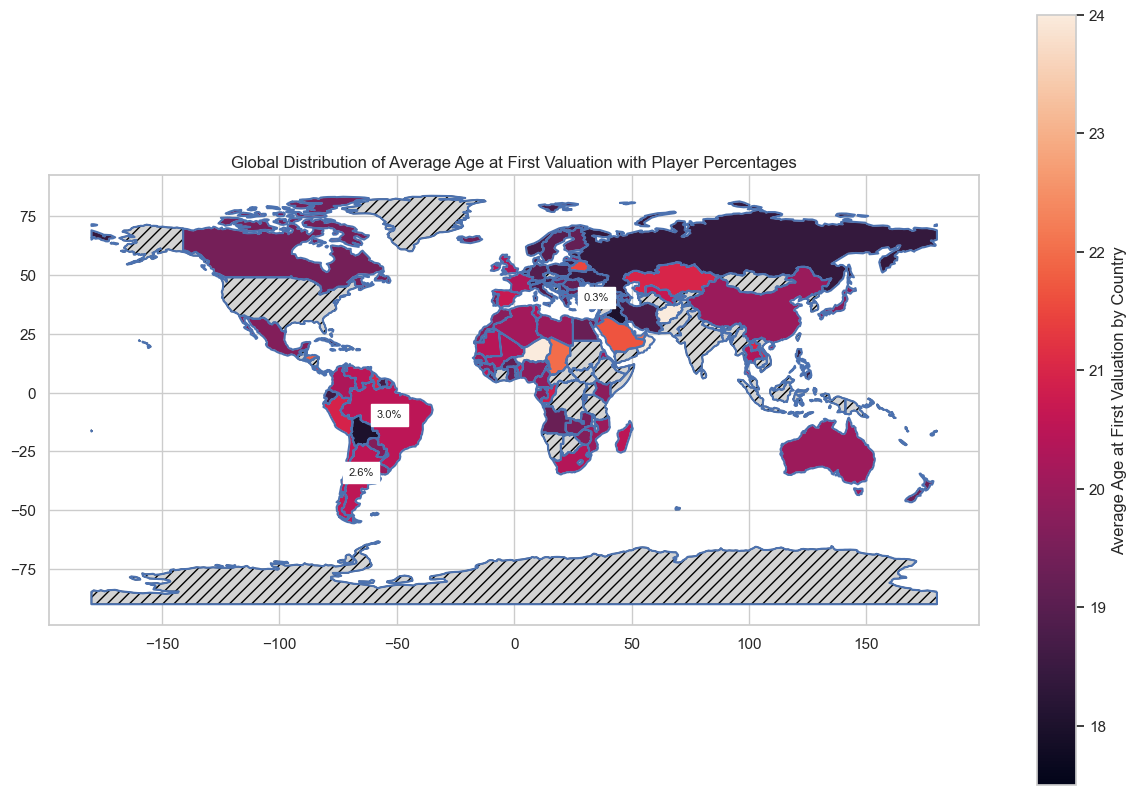

In [76]:
# Merge with the world map
world_with_first_valuation = world_map.merge(average_first_valuation, how="left", on="country_of_citizenship")

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_first_valuation.boundary.plot(ax=ax)
world_with_first_valuation.plot(column='age_at_first_valuation', ax=ax, legend=True,
                     legend_kwds={'label': "Average Age at First Valuation by Country"},
                     missing_kwds={
                         "color": "lightgrey",
                         "edgecolor": "black",
                         "hatch": "///",
                         "label": "Missing data"
                     })

# Annotate the percentage of players on the map
for idx, row in world_filtered.iterrows():
    ax.annotate(f"{row['percentage_in_top_competitions']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                ha='center', fontsize=8, backgroundcolor="white")

plt.title('Global Distribution of Average Age at First Valuation with Player Percentages')
plt.show()

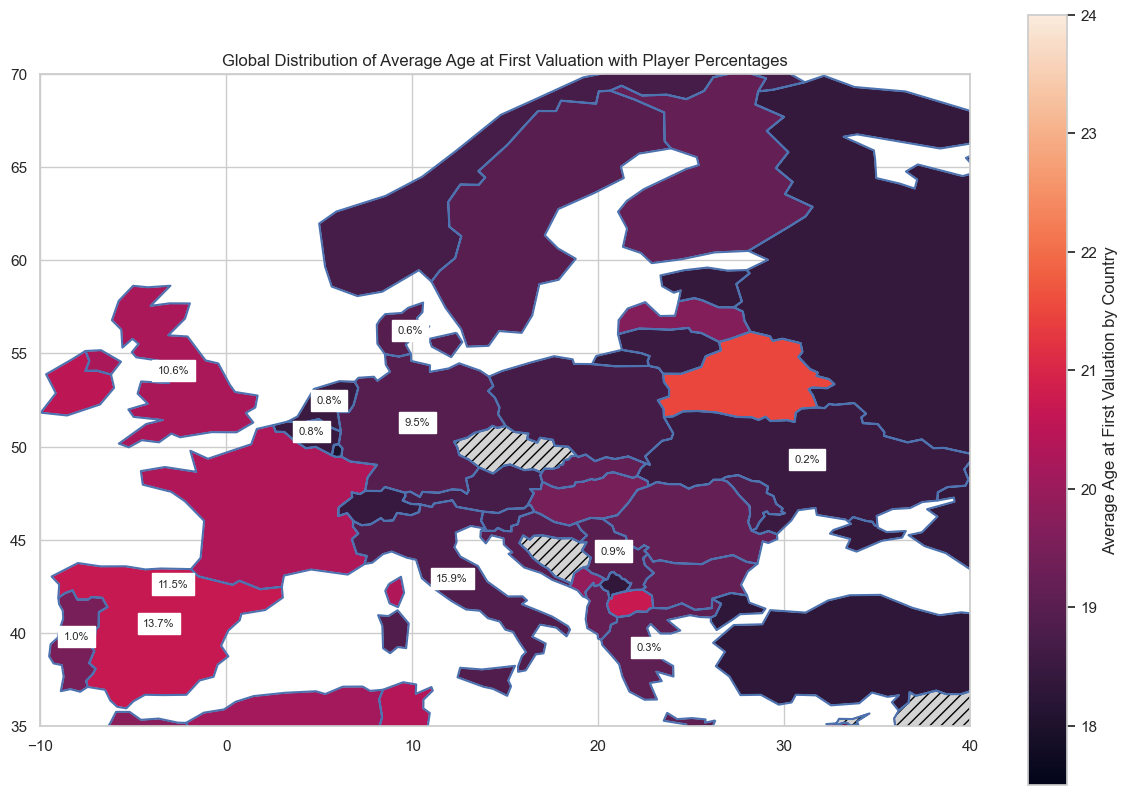

In [77]:
# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_first_valuation.boundary.plot(ax=ax)
world_with_first_valuation.plot(column='age_at_first_valuation', ax=ax, legend=True,
                     legend_kwds={'label': "Average Age at First Valuation by Country"},
                     missing_kwds={
                         "color": "lightgrey",
                         "edgecolor": "black",
                         "hatch": "///",
                         "label": "Missing data"
                     })

# Annotate the percentage of players on the map
for idx, row in europe_filtered.iterrows():
    ax.annotate(f"{row['percentage_in_top_competitions']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                ha='center', fontsize=8, backgroundcolor="white")

ax.set_xlim(-10, 40)  
ax.set_ylim(35, 70) 
plt.title('Global Distribution of Average Age at First Valuation with Player Percentages')
plt.show()

### 13.2. A quale età i giocatori raggiungono il loro primo picco di valutazione economica?

_Nota 3: con il termine "picco" si intende il momento in cui il valore di mercato di un giocatore raggiunge il suo massimo locale e successivamente inizia a diminuire. Il concetto di picco è diverso dal concetto di apice, il quale rappresenta un massimo globale._

In [78]:
# Calculate the difference in market value between consecutive years
valuations_df['value_diff'] = valuations_df.groupby('player_id')['market_value_in_eur'].diff(periods=-1)

# Identify the first peak where the difference is positive (market value greater than the next year)
first_peak_df = valuations_df[valuations_df['value_diff'] > 0].groupby('player_id').first().reset_index()

# Merge with players data to get the birth date and country
first_peak_df = first_peak_df.merge(players_df[['player_id', 'date_of_birth', 'country_of_citizenship']], on='player_id', how='left')

# Calculate the age at the time of first peak valuation
first_peak_df['age_at_first_peak'] = first_peak_df['date'].dt.year - first_peak_df['date_of_birth'].dt.year

# Calculate the average age of first peak valuation by country
average_age_first_peak = first_peak_df.groupby('country_of_citizenship')['age_at_first_peak'].mean().reset_index()

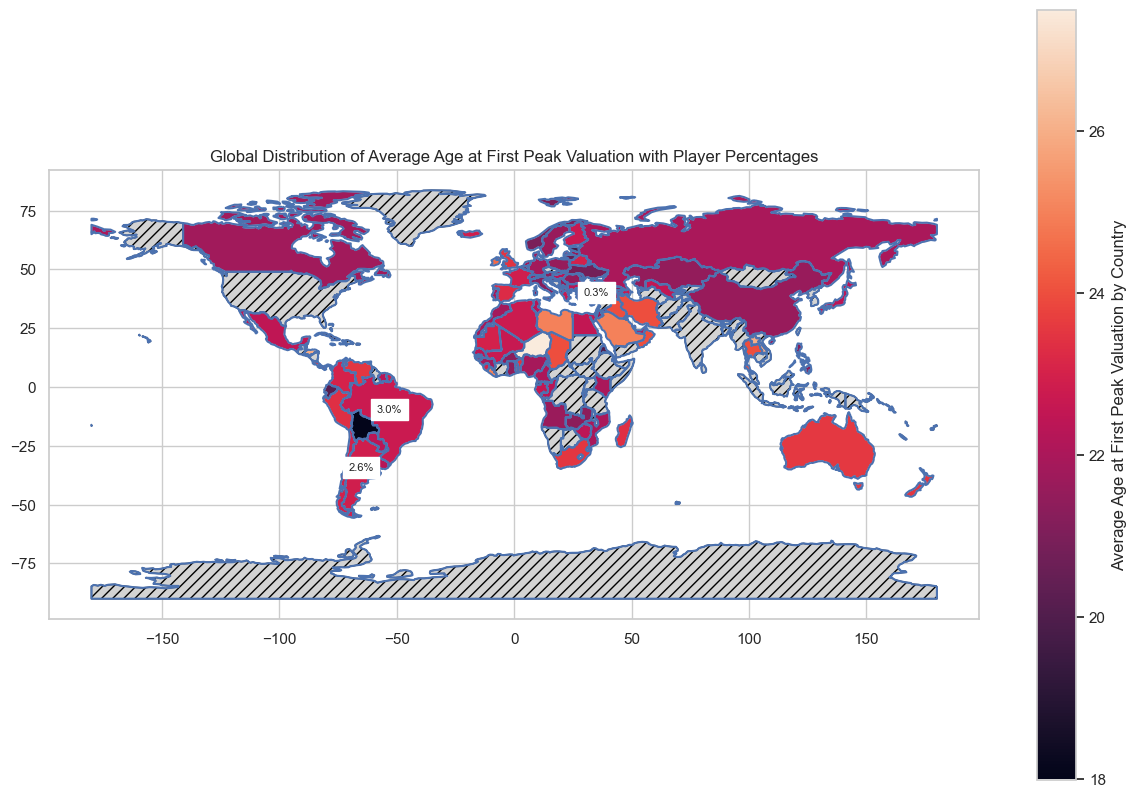

In [79]:
world_with_peak = world_map.merge(average_age_first_peak, how="left", on="country_of_citizenship")

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_peak.boundary.plot(ax=ax)
world_with_peak.plot(column='age_at_first_peak', ax=ax, legend=True,
                     legend_kwds={'label': "Average Age at First Peak Valuation by Country"},
                     missing_kwds={
                         "color": "lightgrey",
                         "edgecolor": "black",
                         "hatch": "///",
                         "label": "Missing data"
                     })

# Annotate the percentage of players on the map
for idx, row in world_filtered.iterrows():
    ax.annotate(f"{row['percentage_in_top_competitions']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                ha='center', fontsize=8, backgroundcolor="white")

plt.title('Global Distribution of Average Age at First Peak Valuation with Player Percentages')
plt.show()

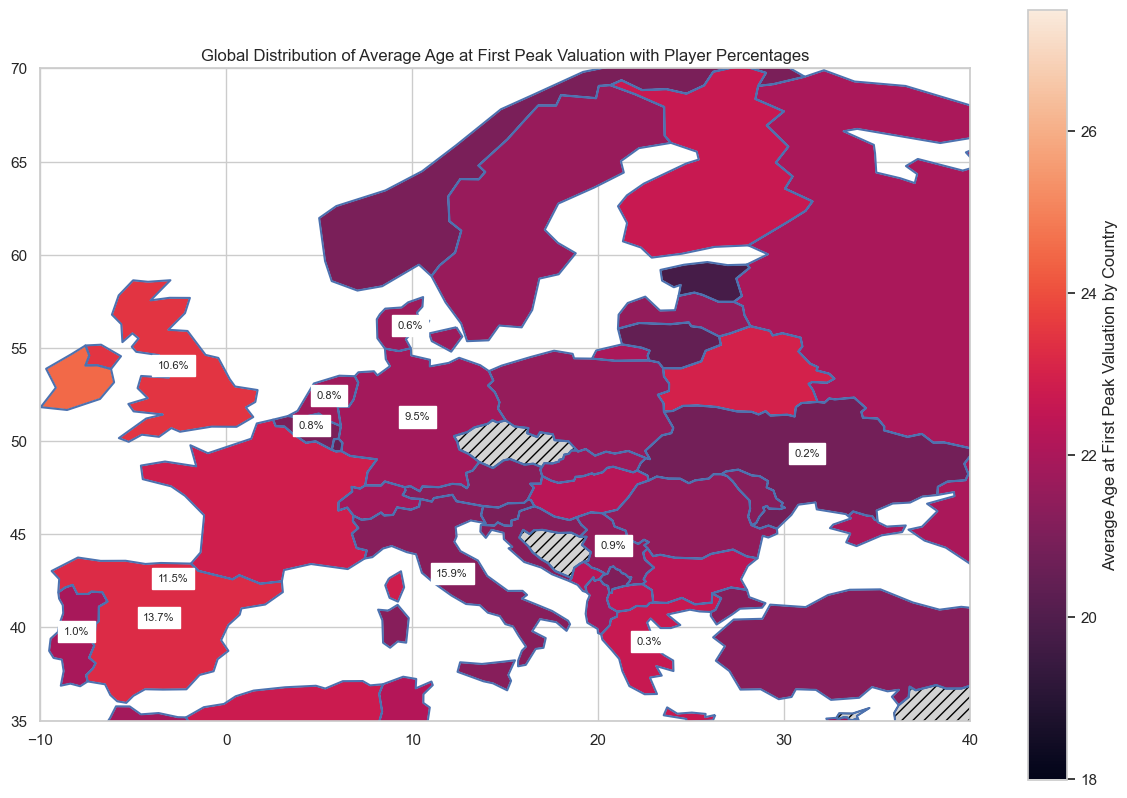

In [80]:
# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_peak.boundary.plot(ax=ax)
world_with_peak.plot(column='age_at_first_peak', ax=ax, legend=True,
                     legend_kwds={'label': "Average Age at First Peak Valuation by Country"},
                     missing_kwds={
                         "color": "lightgrey",
                         "edgecolor": "black",
                         "hatch": "///",
                         "label": "Missing data"
                     })

# Annotate the percentage of players on the map
for idx, row in europe_filtered.iterrows():
    ax.annotate(f"{row['percentage_in_top_competitions']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                ha='center', fontsize=8, backgroundcolor="white")

ax.set_xlim(-10, 40)  
ax.set_ylim(35, 70) 
plt.title('Global Distribution of Average Age at First Peak Valuation with Player Percentages')
plt.show()

### 13.2. A quale età i giocatori raggiungono il loro apice di valutazione economica?

In [81]:
# Find the highest valuation for each player
max_valuation_df = valuations_df.loc[valuations_df.groupby('player_id')['market_value_in_eur'].idxmax()]

# Merge with players data to get the birth date and country
max_valuation_df = max_valuation_df.merge(players_df[['player_id', 'date_of_birth', 'country_of_citizenship']], on='player_id', how='left')

# Calculate the age at the time of highest valuation
max_valuation_df['age_at_max_valuation'] = max_valuation_df['date'].dt.year - max_valuation_df['date_of_birth'].dt.year

# Calculate the average age of highest valuation by country
average_age_max_valuation = max_valuation_df.groupby('country_of_citizenship')['age_at_max_valuation'].mean().reset_index()

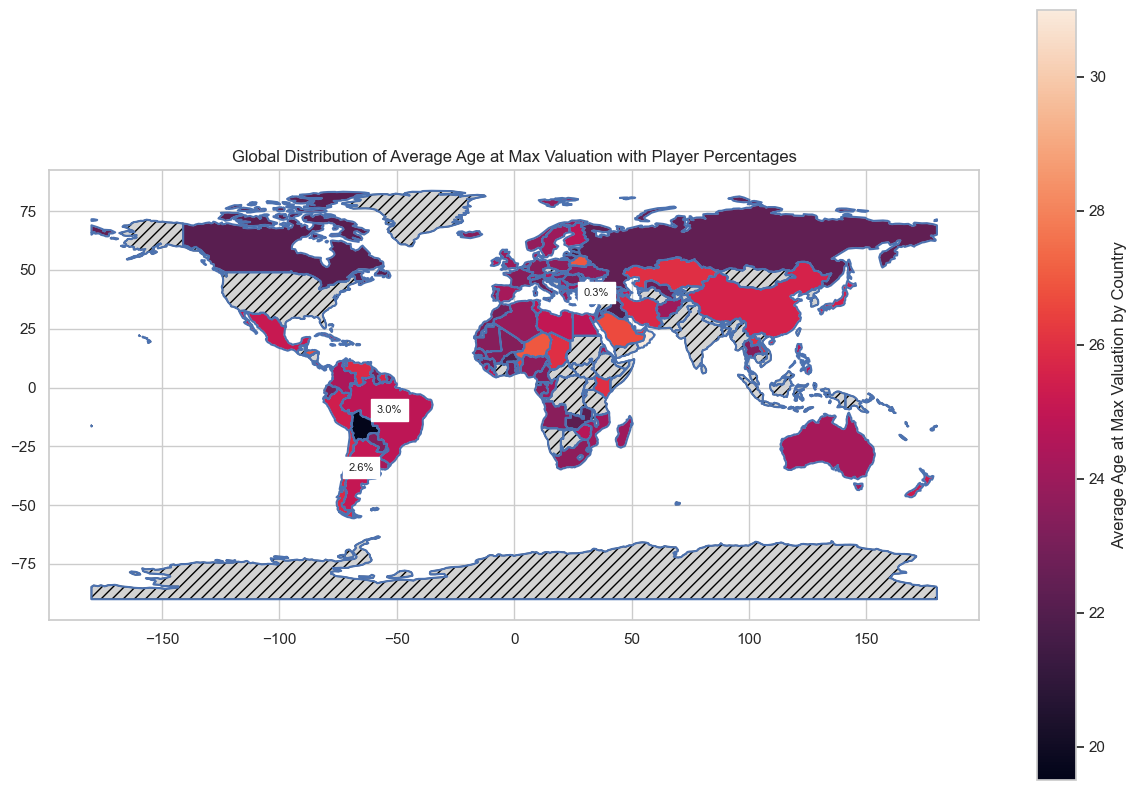

In [82]:
world_with_max_valuation = world_map.merge(average_age_max_valuation, how="left", on="country_of_citizenship")

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_max_valuation.boundary.plot(ax=ax)
world_with_max_valuation.plot(column='age_at_max_valuation', ax=ax, legend=True,
                     legend_kwds={'label': "Average Age at Max Valuation by Country"},
                     missing_kwds={
                         "color": "lightgrey",
                         "edgecolor": "black",
                         "hatch": "///",
                         "label": "Missing data"
                     })

# Annotate the percentage of players on the map
for idx, row in world_filtered.iterrows():
    ax.annotate(f"{row['percentage_in_top_competitions']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                ha='center', fontsize=8, backgroundcolor="white")

plt.title('Global Distribution of Average Age at Max Valuation with Player Percentages')
plt.show()

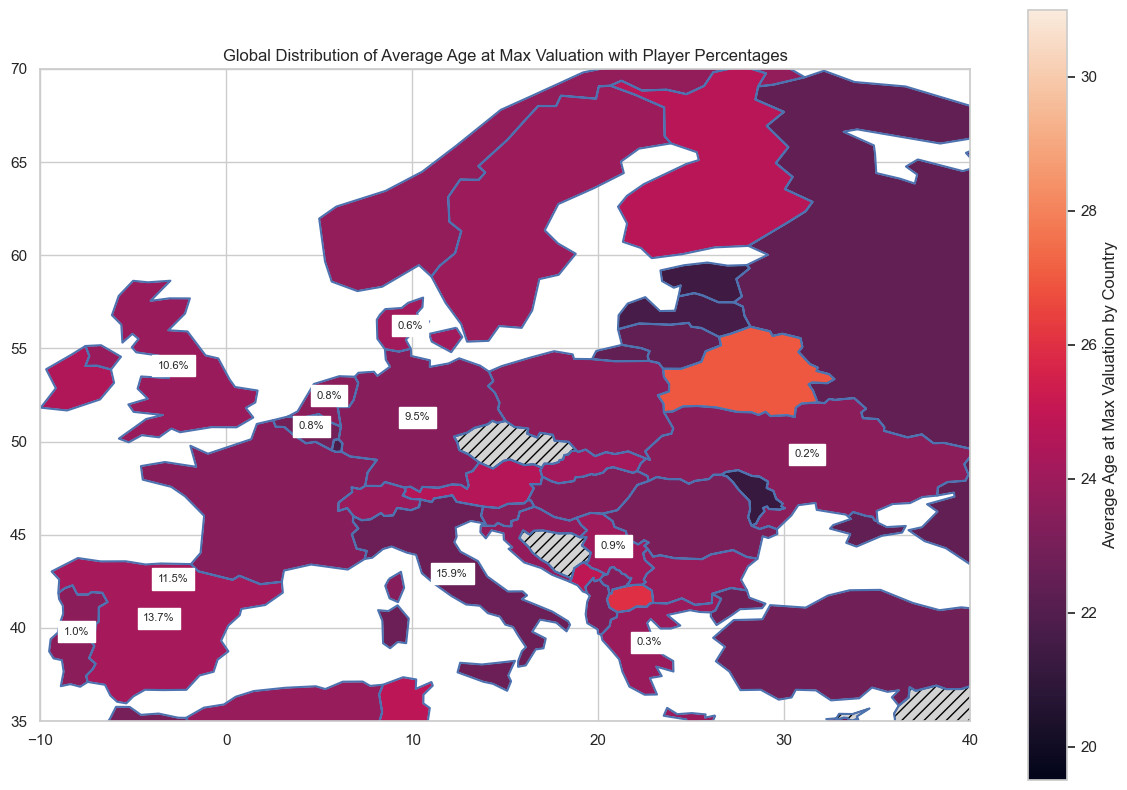

In [84]:
# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_with_max_valuation.boundary.plot(ax=ax)
world_with_max_valuation.plot(column='age_at_max_valuation', ax=ax, legend=True,
                     legend_kwds={'label': "Average Age at Max Valuation by Country"},
                     missing_kwds={
                         "color": "lightgrey",
                         "edgecolor": "black",
                         "hatch": "///",
                         "label": "Missing data"
                     })

# Annotate the percentage of players on the map
for idx, row in europe_filtered.iterrows():
    ax.annotate(f"{row['percentage_in_top_competitions']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                ha='center', fontsize=8, backgroundcolor="white")

ax.set_xlim(-10, 40)  
ax.set_ylim(35, 70)  
plt.title('Global Distribution of Average Age at Max Valuation with Player Percentages')
plt.show()

In Italia e in Germania le prime valutazioni dei giocatori avvengono molto prima (in termini di età) rispetto a stati come la Spagna o la Francia. Invece il primo picco di valutazione è intorno ai 23 anni per quanto riguarda la Spagna, la Francia e il Regno Unito, mentre per l'Italia e la Germania è intorno ai 21 anni. Queste età sono rispettate anche per quanto riguarda l'apice della valutazione economica dei calciatori in questi stati. 
Analogamente, questo grafico geografico, dipende molto dalla quantità di giocatori, per ogni nazione, presente all'interno del dataset. 

## 14. Quali caratteristiche deve avere un tiratore di punizioni

### 14.1. Quale posizione hanno statisticamente i tiratori di punizione?

In [18]:
# Filter the game events to find free-kick goals
free_kick_goals_df = game_events_df[(game_events_df['type'] == 'Goals') &(game_events_df['description'].str.contains('Free kick', case=False, na=False))]

free_kick_scorers_df = free_kick_goals_df.groupby('player_id').agg(free_kick_goals=('player_id', 'size'), event_date=('date', 'first')).reset_index()

# Merge the player data for the free-kick goals
player_free_kick_df = pd.merge(free_kick_scorers_df, players_df, on='player_id', how='left')

player_free_kick_df['age_at_goal'] = player_free_kick_df['event_date'].apply(lambda x: pd.to_datetime(x).year) - player_free_kick_df['date_of_birth'].apply(lambda x: pd.to_datetime(x).year)

player_free_kick_df = player_free_kick_df[['name', 'free_kick_goals', 'sub_position', 'country_of_citizenship', 'age_at_goal', 'foot']]

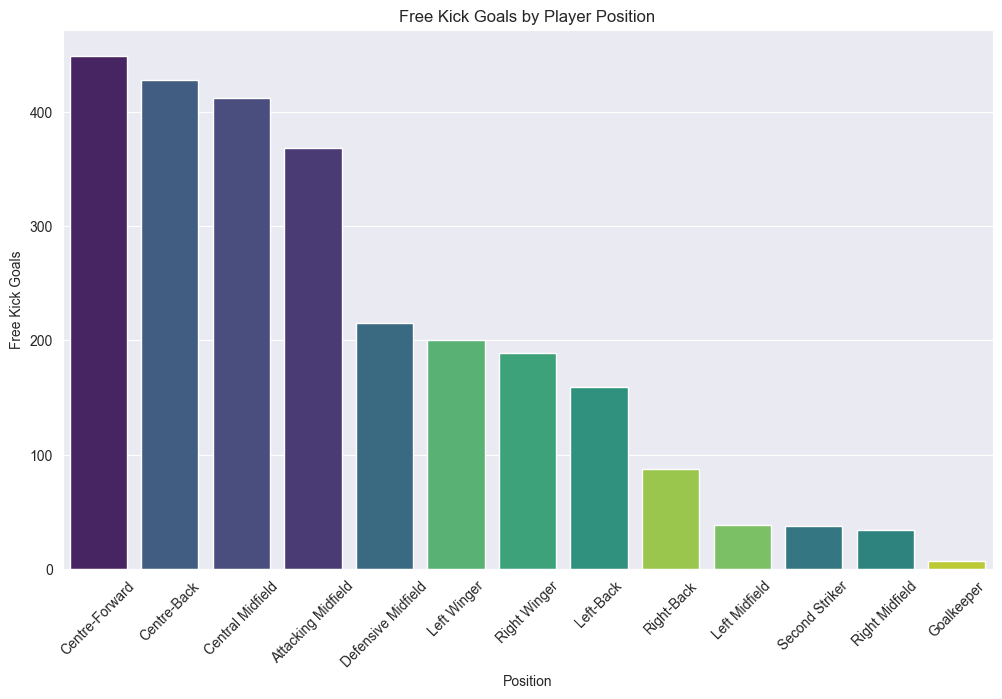

In [19]:
# Filter out the 'unknown' sub_positions
filtered_roles_df = player_free_kick_df[player_free_kick_df['sub_position'] != 'unknown']
ordered_roles = filtered_roles_df['sub_position'].value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(data=filtered_roles_df, x='sub_position', hue='sub_position', order= ordered_roles, palette='viridis', dodge=False)
plt.title('Free Kick Goals by Player Position')
plt.xlabel('Position')
plt.ylabel('Free Kick Goals')
plt.xticks(rotation=45)
plt.legend([], frameon=False)
plt.show()

### 14.2. Di quali nazioni sono stati statisticamente i tiratori di punizione?

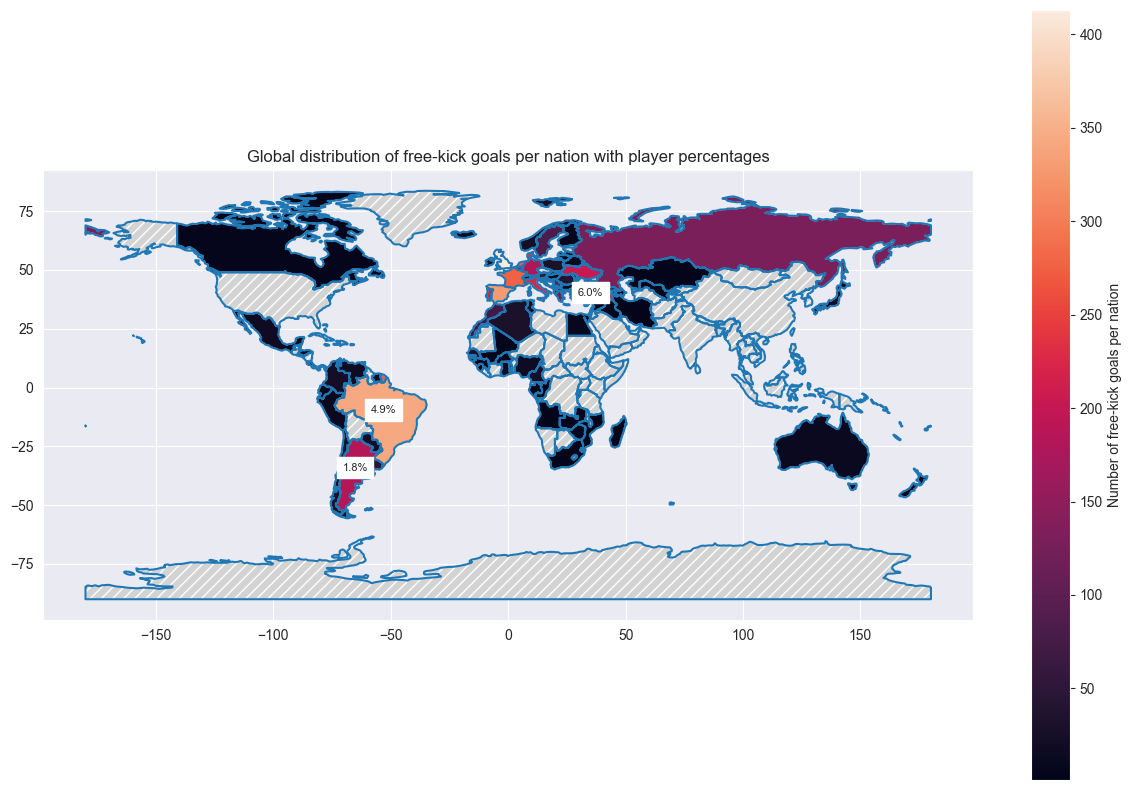

In [20]:
# Calculate the number of goals per nation
goals_by_nationality = player_free_kick_df.groupby('country_of_citizenship')['free_kick_goals'].sum().reset_index()

# Merge the percentage and goal data with the world map
world_goals = world_map.merge(goals_by_nationality, on='country_of_citizenship', how='left')

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_goals.boundary.plot(ax=ax)
world_goals.plot(column='free_kick_goals', ax=ax, legend=True, legend_kwds={'label': "Number of free-kick goals per nation"}, missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "Missing data"})

# Annotate the percentage of players on the map
for idx, row in world_filtered.iterrows():
    ax.annotate(f"{row['percentage_of_players']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=8, backgroundcolor="white")

plt.title('Global distribution of free-kick goals per nation with player percentages')
plt.show()

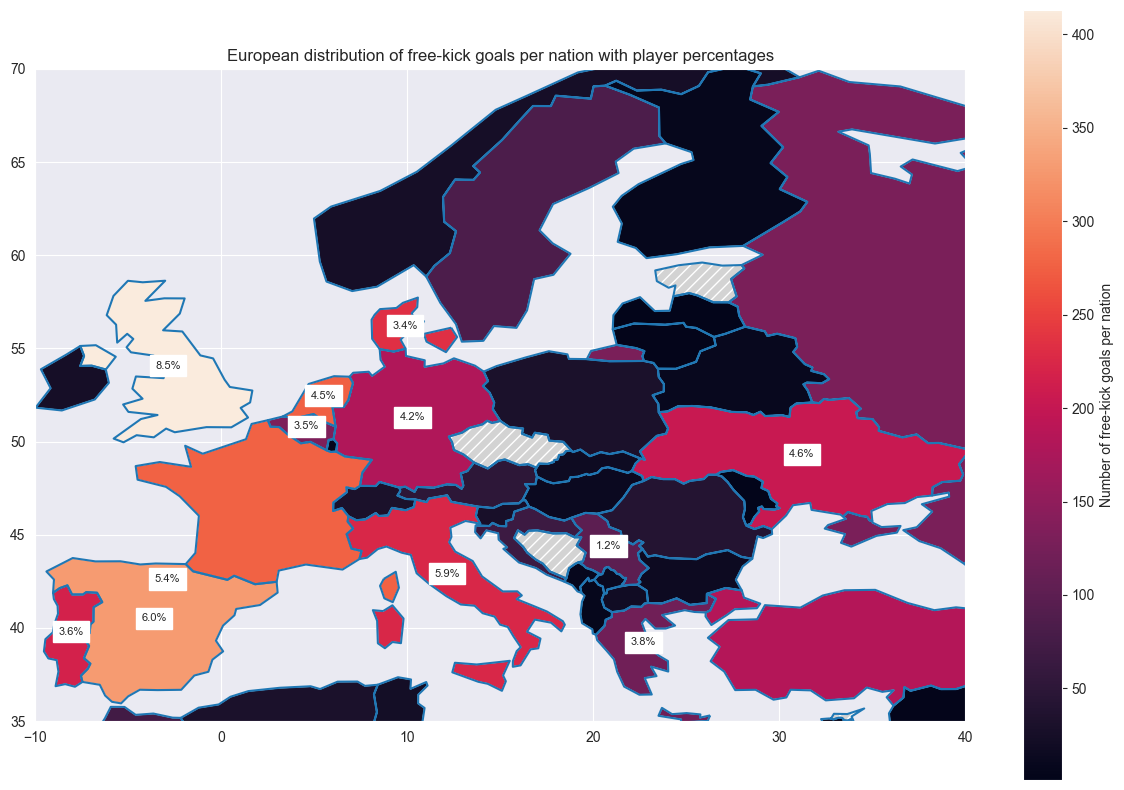

In [21]:
# Plotting
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_goals.boundary.plot(ax=ax)
world_goals.plot(column='free_kick_goals', ax=ax, legend=True, legend_kwds={'label': "Number of free-kick goals per nation"}, missing_kwds={"color": "lightgrey","edgecolor": "white", "hatch": "///", "label": "Missing data"})

# Annotate the percentage of players on the map
for idx, row in europe_filtered.iterrows():
    ax.annotate(f"{row['percentage_of_players']:.1f}%", xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), ha='center', fontsize=8, backgroundcolor="white")
plt.title('European distribution of free-kick goals per nation with player percentages')
ax.set_xlim(-10, 40)  # Longitude 
ax.set_ylim(35, 70)  # Latitudine 
plt.show()

### 14.3. Che età hanno statisticamente i tiratori di punizione?

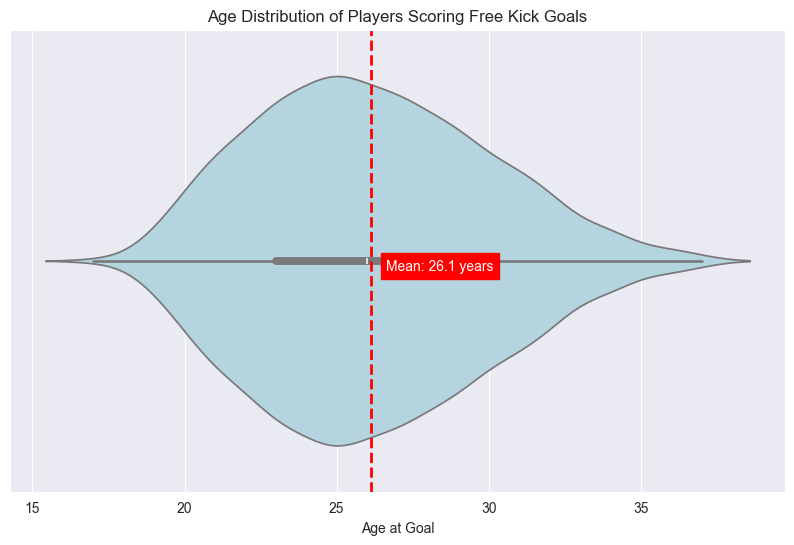

In [22]:
# Calculate the mean age of players at the time of the goal
mean_age_at_goal = player_free_kick_df['age_at_goal'].mean()

# Plotting the distribution of player ages at the time of the goal
plt.figure(figsize=(10, 6))
sns.violinplot(x=player_free_kick_df['age_at_goal'], color='lightblue')
plt.axvline(mean_age_at_goal, color='red', linestyle='dashed', linewidth=2)
plt.text(mean_age_at_goal + 0.5, 0.02, f'Mean: {mean_age_at_goal:.1f} years', color='white', backgroundcolor='red')
plt.title('Age Distribution of Players Scoring Free Kick Goals')
plt.xlabel('Age at Goal')
plt.show()

### 14.2. Statisticamente quale è il piede dominante dei tiratori di punizione?

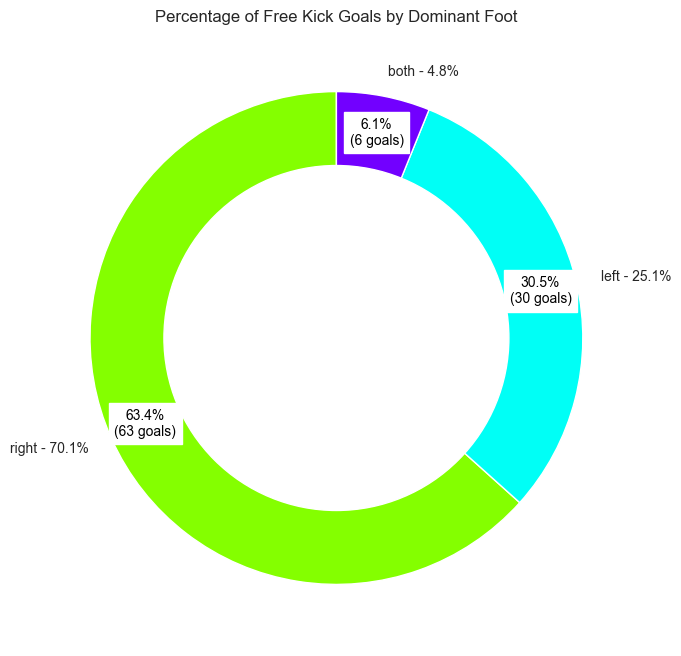

In [23]:
# Calculate the percentage of players with known dominant foot
filtered_total_foot_counts = players_df[players_df['foot'] != 'unknown']['foot'].value_counts(normalize=True) * 100
filtered_total_free_kick_foot_counts = player_free_kick_df[player_free_kick_df['foot'] != 'unknown']['foot'].value_counts(normalize=True) * 100

# Define the list of colors
colors = sns.color_palette("hsv", len(filtered_total_free_kick_foot_counts)) 

# Function to add labels with background to the pie chart
def add_label_with_background(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d} goals)".format(pct, absolute)

# Plotting the pie chart for the filtered foot counts
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(filtered_total_free_kick_foot_counts, labels=[f'{label} - {percent:.1f}%' for label, percent in filtered_total_foot_counts.items()], autopct=lambda pct: add_label_with_background(pct, filtered_total_free_kick_foot_counts),colors=colors,startangle=90, pctdistance=0.85)

# Draw a circle at the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

for text, autotext in zip(texts, autotexts):
    autotext.set_color('black')
    autotext.set_backgroundcolor('white')

plt.title('Percentage of Free Kick Goals by Dominant Foot')
plt.show()

- I principali ruoli che hanno segnato dei goals attraverso un calcio di punizione sono i centrocampisti e (inaspettatamente) i difensori.
- Le principali nazioni in cui sono nati più calciatori che hanno segnato più goals da calcio di punizione sono il Brasile, il Regno Unito e la Spagna. 
- La media di età dei calciatori che hanno fatto goal da un calcio di punizione è di 26 anni. 
- Statisticamente è leggermente meglio avere il piede sinistro predominante o essere ambidestro, per calciare le punizioni. 